In [ ]:
!pip install Bio

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio.PDB import MMCIF2Dict
from scipy.spatial import cKDTree

CIF_PATH = "/content/1CWP.cif"

OUTPUT_DIR = "/content/outputs"
OUT_DIR = os.path.join(OUTPUT_DIR, "csv_outputs")

FIGURES_DIR = "/content/figures"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("CSV output directory:", OUT_DIR)
print("Figures directory:", FIGURES_DIR)

CSV output directory: /content/outputs/csv_outputs
Figures directory: /content/figures


In [ ]:

# ============================================================
# ============================================================
# Ensures that an input value is always returned as a list for consistent downstream processing.
def as_list(x):
    if isinstance(x, list):
        return x
    return [x]


# ============================================================
# FUNCTION: safe_display
# ============================================================
# Displays a dataframe safely in both notebook and standard Python environments.
def safe_display(df, title=None, n=20):
    if title:
        print("\n" + title)
        print("=" * len(title))
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n))


# ============================================================
# FUNCTION: is_protein_residue
# ============================================================
# Checks whether a residue name corresponds to a standard amino acid.
def is_protein_residue(resname):
    return str(resname).strip().upper() in STANDARD_AA


# ============================================================
# FUNCTION: is_rna_residue
# ============================================================
# Checks whether a residue name corresponds to an RNA nucleotide.
def is_rna_residue(resname):
    return str(resname).strip().upper() in RNA_RESNAMES


# ============================================================
# FUNCTION: is_solvent_residue
# ============================================================
# Checks whether a residue belongs to the defined solvent set.
def is_solvent_residue(resname):
    return str(resname).strip().upper() in SOLVENT_RESNAMES


# ============================================================
# FUNCTION: delete_solvent
# ============================================================
# Removes solvent atoms so they do not interfere with interaction detection.
def delete_solvent(atoms_df):
    """
    Removes solvent atoms before interaction detection.
    This is intentionally applied after atom extraction and before ASU / assembly generation.
    """
    if len(atoms_df) == 0:
        return atoms_df.copy()

    before = len(atoms_df)
    cleaned = atoms_df[
        ~atoms_df["resname"].astype(str).str.upper().isin(SOLVENT_RESNAMES)
    ].copy()
    after = len(cleaned)

    print(f"Deleted solvent atoms: {before - after}")
    return cleaned


# ============================================================
# FUNCTION: add_hydrogens
# ============================================================
# Keeps explicit hydrogen atoms when present and warns when the input structure is not protonated.
def add_hydrogens(atoms_df):
    """
    Keeps hydrogens for downstream interaction detection if hydrogens are present in the input mmCIF.

    Important: this dataframe-based pipeline has no bond/protonation engine, so it cannot
    accurately invent missing H coordinates from a heavy-atom-only crystal structure.
    To truly add missing hydrogens, use a protonated input structure from Reduce,
    PDBFixer, ChimeraX, PyMOL h_add, or similar, then run this script.
    """
    if len(atoms_df) == 0:
        return atoms_df.copy()

    h_mask = atoms_df.apply(
        lambda r: is_hydrogen_atom(r.get("atom_name", ""), r.get("element", "")),
        axis=1
    )
    n_h = int(h_mask.sum())

    if n_h > 0:
        print(f"Hydrogens present and kept: {n_h}")
    else:
        print("Hydrogens requested, but no H atoms were present in the input coordinates.")
        print("Use a protonated CIF/PDB input if you need explicit H coordinates.")

    return atoms_df.copy()


# ============================================================
# FUNCTION: prepare_atoms_before_interactions
# ============================================================
# Prepares atoms for contact analysis by removing solvent and retaining available hydrogens.
def prepare_atoms_before_interactions(atoms_df):
    """
    Requested preprocessing step before finding interactions:
      1. delete solvent
      2. add/keep hydrogens
    """
    atoms_df = delete_solvent(atoms_df)
    atoms_df = add_hydrogens(atoms_df)
    return atoms_df


# ============================================================
# FUNCTION: classify_molecule_type
# ============================================================
# Classifies each residue as protein, RNA, or other.
def classify_molecule_type(resname):
    resname = str(resname).strip().upper()
    if is_protein_residue(resname):
        return "protein"
    if is_rna_residue(resname):
        return "RNA"
    return "other"


# ============================================================
# FUNCTION: is_hydrogen_atom
# ============================================================
# Identifies hydrogen atoms from their atom name or element symbol.
def is_hydrogen_atom(atom_name, element):
    atom_name = str(atom_name).strip().upper()
    element = str(element).strip().upper()
    return atom_name.startswith("H") or element == "H"


# ============================================================
# FUNCTION: atom_element_guess
# ============================================================
# Infers an atom's chemical element when the element field is missing or incomplete.
def atom_element_guess(atom_name, element=None):
    if element is not None and str(element).strip() not in ["", ".", "?"]:
        return str(element).strip().upper()

    atom_name = str(atom_name).strip().upper()

    for ch in atom_name:
        if ch.isalpha():
            return ch

    return ""


# ============================================================
# FUNCTION: is_polar_atom
# ============================================================
# Checks whether an atom is polar based on its inferred element.
def is_polar_atom(atom_name, element=None):
    return atom_element_guess(atom_name, element) in {"N", "O", "S", "P"}


# ============================================================
# FUNCTION: is_carbon_or_sulfur
# ============================================================
# Checks whether an atom is carbon or sulfur for hydrophobic-contact classification.
def is_carbon_or_sulfur(atom_name, element=None):
    return atom_element_guess(atom_name, element) in {"C", "S"}


# ============================================================
# FUNCTION: atom_group
# ============================================================
# Classifies an atom as backbone or side chain.
def atom_group(atom_name):
    atom_name = str(atom_name).strip().upper()
    if atom_name in BACKBONE_ATOMS:
        return "backbone"
    return "sidechain"


# ============================================================
# FUNCTION: is_rna_phosphate_atom
# ============================================================
# Identifies atoms that belong to the RNA phosphate group.
def is_rna_phosphate_atom(atom_name):
    atom_name = str(atom_name).strip().upper()
    return atom_name in {"P", "OP1", "OP2", "O1P", "O2P", "O3P"}


# ============================================================
# FUNCTION: clean_residue_identity
# ============================================================
# Creates a standardized residue identifier for protein, RNA, or other molecules.
def clean_residue_identity(molecule_type, auth_chain, resname, resid):
    prefix = "protein" if molecule_type == "protein" else "RNA" if molecule_type == "RNA" else "other"
    return f"{prefix}_{auth_chain}:{resname}{int(resid)}"


# ============================================================
# FUNCTION: op_pair_label
# ============================================================
# Creates a compact label for a pair of symmetry-operator copies.
def op_pair_label(copy_1, copy_2):
    return f"op{int(copy_1)}-op{int(copy_2)}"


# ============================================================
# FUNCTION: parse_oper_expression
# ============================================================
# Parses mmCIF operator expressions into explicit symmetry-operator identifiers.
def parse_oper_expression(expr):
    """
    Parses operator expressions like:
        1
        (1-5)
        (1,2,6,10,23,24)

    This is enough for Assembly 3 and Assembly 4 in 1CWP.
    """
    expr = str(expr).strip().replace(" ", "")

    if "(" not in expr:
        return [expr]

    groups = re.findall(r"\((.*?)\)", expr)

    if len(groups) == 1:
        group = groups[0]
        ops = []

        for part in group.split(","):
            if "-" in part:
                start, end = part.split("-")
                for i in range(int(start), int(end) + 1):
                    ops.append(str(i))
            else:
                ops.append(part)

        return ops

    parsed_groups = []

    for group in groups:
        group_ops = []

        for part in group.split(","):
            if "-" in part:
                start, end = part.split("-")
                for i in range(int(start), int(end) + 1):
                    group_ops.append(str(i))
            else:
                group_ops.append(part)

        parsed_groups.append(group_ops)

    combined = []

    if len(parsed_groups) == 2:
        for op1 in parsed_groups[0]:
            for op2 in parsed_groups[1]:
                combined.append(f"{op1}|{op2}")
        return combined

    return parsed_groups[0]


# ============================================================
# FUNCTION: get_operator_matrix_vector
# ============================================================
# Extracts rotation matrices and translation vectors for all mmCIF symmetry operators.
def get_operator_matrix_vector(cif_dict):
    ids = as_list(cif_dict["_pdbx_struct_oper_list.id"])
    operators = {}

    for i, op_id in enumerate(ids):
        matrix = np.array([
            [
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[1][1]"])[i]),
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[1][2]"])[i]),
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[1][3]"])[i])
            ],
            [
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[2][1]"])[i]),
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[2][2]"])[i]),
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[2][3]"])[i])
            ],
            [
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[3][1]"])[i]),
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[3][2]"])[i]),
                float(as_list(cif_dict["_pdbx_struct_oper_list.matrix[3][3]"])[i])
            ]
        ], dtype=float)

        vector = np.array([
            float(as_list(cif_dict["_pdbx_struct_oper_list.vector[1]"])[i]),
            float(as_list(cif_dict["_pdbx_struct_oper_list.vector[2]"])[i]),
            float(as_list(cif_dict["_pdbx_struct_oper_list.vector[3]"])[i])
        ], dtype=float)

        operators[str(op_id)] = {
            "matrix": matrix,
            "vector": vector
        }

    return operators


# ============================================================
# FUNCTION: read_cif_setup
# ============================================================
# Loads the mmCIF file and extracts assembly definitions and symmetry operators.
def read_cif_setup(cif_path):
    cif_dict = MMCIF2Dict.MMCIF2Dict(cif_path)

    assemblies_df = pd.DataFrame({
        "assembly_id": as_list(cif_dict["_pdbx_struct_assembly.id"]),
        "details": as_list(cif_dict["_pdbx_struct_assembly.details"]),
        "oligomeric_details": as_list(cif_dict["_pdbx_struct_assembly.oligomeric_details"]),
        "oligomeric_count": as_list(cif_dict["_pdbx_struct_assembly.oligomeric_count"])
    })

    assembly_gen_df = pd.DataFrame({
        "assembly_id": as_list(cif_dict["_pdbx_struct_assembly_gen.assembly_id"]),
        "oper_expression": as_list(cif_dict["_pdbx_struct_assembly_gen.oper_expression"]),
        "asym_id_list": as_list(cif_dict["_pdbx_struct_assembly_gen.asym_id_list"])
    })

    operators = get_operator_matrix_vector(cif_dict)

    safe_display(assemblies_df, "Available biological assemblies", 20)
    safe_display(assembly_gen_df, "Assembly generation rules", 20)

    return cif_dict, assemblies_df, assembly_gen_df, operators


# ============================================================
# FUNCTION: extract_atom_df
# ============================================================
# Extracts protein and RNA atoms required for the selected biological assembly.
def extract_atom_df(cif_dict, assembly_gen_df, assembly_id="3"):
    """
    Extracts all atoms used in the chosen assembly.
    Uses label_asym_id for assembly selection.
    Keeps auth_asym_id for biological interpretation.
    """

    target_rows = assembly_gen_df[
        assembly_gen_df["assembly_id"].astype(str) == str(assembly_id)
    ].copy()

    if len(target_rows) == 0:
        raise ValueError(f"Assembly {assembly_id} not found.")

    asym_id_list = str(target_rows.iloc[0]["asym_id_list"])
    asym_ids = [x.strip() for x in asym_id_list.split(",")]

    atom_group = as_list(cif_dict["_atom_site.group_PDB"])
    atom_id = as_list(cif_dict["_atom_site.id"])
    atom_type_symbol = as_list(cif_dict["_atom_site.type_symbol"])

    atom_label_atom_id = as_list(cif_dict["_atom_site.label_atom_id"])
    atom_label_comp_id = as_list(cif_dict["_atom_site.label_comp_id"])
    atom_label_asym_id = as_list(cif_dict["_atom_site.label_asym_id"])
    atom_label_seq_id = as_list(cif_dict["_atom_site.label_seq_id"])

    atom_auth_asym_id = as_list(cif_dict["_atom_site.auth_asym_id"])

    if "_atom_site.auth_seq_id" in cif_dict:
        atom_auth_seq_id = as_list(cif_dict["_atom_site.auth_seq_id"])
    else:
        atom_auth_seq_id = atom_label_seq_id

    atom_cartn_x = as_list(cif_dict["_atom_site.Cartn_x"])
    atom_cartn_y = as_list(cif_dict["_atom_site.Cartn_y"])
    atom_cartn_z = as_list(cif_dict["_atom_site.Cartn_z"])

    rows = []

    for i in range(len(atom_id)):
        label_asym_id = str(atom_label_asym_id[i])

        if label_asym_id not in asym_ids:
            continue

        if str(atom_label_seq_id[i]) in [".", "?"]:
            continue

        if str(atom_auth_seq_id[i]) in [".", "?"]:
            continue

        resname = str(atom_label_comp_id[i]).upper()
        atom_name = str(atom_label_atom_id[i]).upper()
        element = str(atom_type_symbol[i]).upper()

        if is_solvent_residue(resname):
            continue

        moltype = classify_molecule_type(resname)

        if moltype not in {"protein", "RNA"}:
            continue

        rows.append({
            "group_PDB": str(atom_group[i]),
            "atom_name": atom_name,
            "resname": resname,

            "label_asym_id": label_asym_id,
            "auth_asym_id": str(atom_auth_asym_id[i]),

            "label_residue_number": int(atom_label_seq_id[i]),
            "auth_residue_number": int(atom_auth_seq_id[i]),

            "molecule_type": moltype,
            "element": element,

            "x": float(atom_cartn_x[i]),
            "y": float(atom_cartn_y[i]),
            "z": float(atom_cartn_z[i])
        })

    atom_df = pd.DataFrame(rows)

    safe_display(
        atom_df.groupby(["label_asym_id", "auth_asym_id", "molecule_type"])
        .agg(
            example_resnames=("resname", lambda x: ", ".join(sorted(set(x))[:8])),
            n_atoms=("resname", "count")
        )
        .reset_index()
        .sort_values(["label_asym_id", "auth_asym_id"]),
        f"label_asym_id / auth_asym_id mapping for Assembly {assembly_id}",
        20
    )

    return atom_df


# ============================================================
# FUNCTION: get_assembly_operator_ids
# ============================================================
# Retrieves the symmetry operators used to construct a selected biological assembly.
def get_assembly_operator_ids(assembly_gen_df, assembly_id):
    target_rows = assembly_gen_df[
        assembly_gen_df["assembly_id"].astype(str) == str(assembly_id)
    ].copy()

    if len(target_rows) == 0:
        raise ValueError(f"Assembly {assembly_id} not found.")

    expr = target_rows.iloc[0]["oper_expression"]
    operator_ids = parse_oper_expression(expr)

    return operator_ids, expr


# ============================================================
# FUNCTION: generate_transformed_atoms
# ============================================================
# Applies symmetry operators to generate transformed copies of the atomic coordinates.
def generate_transformed_atoms(atom_df, operator_ids, operators, assembly_name):
    rows = []

    for copy_index, op_id in enumerate(operator_ids):

        if str(op_id) not in operators:
            print(f"WARNING: operator {op_id} not found. Skipping.")
            continue

        op = operators[str(op_id)]
        matrix = op["matrix"]
        vector = op["vector"]

        for _, row in atom_df.iterrows():
            coord = np.array([row["x"], row["y"], row["z"]], dtype=float)
            new_coord = matrix @ coord + vector

            rows.append({
                "assembly": assembly_name,
                "copy_index": int(copy_index),
                "operator_id": str(op_id),

                "label_asym_id": str(row["label_asym_id"]),
                "auth_asym_id": str(row["auth_asym_id"]),
                "molecule_type": str(row["molecule_type"]),

                "residue_number": int(row["auth_residue_number"]),
                "resname": str(row["resname"]),
                "atom_name": str(row["atom_name"]),
                "element": str(row["element"]),

                "x": float(new_coord[0]),
                "y": float(new_coord[1]),
                "z": float(new_coord[2])
            })

    return pd.DataFrame(rows)


# ============================================================
# FUNCTION: generate_asu_atoms
# ============================================================
# Formats the original asymmetric-unit atoms using the same schema as generated assemblies.
def generate_asu_atoms(atom_df):
    rows = []

    for _, row in atom_df.iterrows():
        rows.append({
            "assembly": "ASU",
            "copy_index": 0,
            "operator_id": "identity",

            "label_asym_id": str(row["label_asym_id"]),
            "auth_asym_id": str(row["auth_asym_id"]),
            "molecule_type": str(row["molecule_type"]),

            "residue_number": int(row["auth_residue_number"]),
            "resname": str(row["resname"]),
            "atom_name": str(row["atom_name"]),
            "element": str(row["element"]),

            "x": float(row["x"]),
            "y": float(row["y"]),
            "z": float(row["z"])
        })

    return pd.DataFrame(rows)


# ============================================================
# FUNCTION: classify_contact
# ============================================================
# Assigns a descriptive interaction type to each detected atom pair.
def classify_contact(row):
    res1 = str(row["resname_1"]).upper()
    res2 = str(row["resname_2"]).upper()
    atom1 = str(row["atom_1"]).upper()
    atom2 = str(row["atom_2"]).upper()
    elem1 = str(row["element_1"]).upper()
    elem2 = str(row["element_2"]).upper()
    d = float(row["distance_A"])

    protein1 = is_protein_residue(res1)
    protein2 = is_protein_residue(res2)
    rna1 = is_rna_residue(res1)
    rna2 = is_rna_residue(res2)

    g1 = atom_group(atom1)
    g2 = atom_group(atom2)

    types = []

    if protein1 and protein2:
        acidic_basic = (
            (res1 in ACIDIC and res2 in BASIC) or
            (res2 in ACIDIC and res1 in BASIC)
        )

        if acidic_basic and g1 == "sidechain" and g2 == "sidechain" and d <= 4.0:
            types.append("salt-bridge-like")

        if is_polar_atom(atom1, elem1) and is_polar_atom(atom2, elem2) and d <= 3.5:
            types.append("polar/H-bond-like")

        if (
            res1 in HYDROPHOBIC and
            res2 in HYDROPHOBIC and
            is_carbon_or_sulfur(atom1, elem1) and
            is_carbon_or_sulfur(atom2, elem2) and
            g1 == "sidechain" and
            g2 == "sidechain" and
            d <= 4.5
        ):
            types.append("hydrophobic-like")

        if res1 in AROMATIC and res2 in AROMATIC and d <= 5.0:
            types.append("aromatic-like")

        if len(types) == 0:
            types.append("protein-protein close contact")

    elif (protein1 and rna2) or (protein2 and rna1):

        if protein1 and rna2:
            prot_res = res1
            prot_atom = atom1
            prot_elem = elem1
            rna_atom = atom2
        else:
            prot_res = res2
            prot_atom = atom2
            prot_elem = elem2
            rna_atom = atom1

        if is_rna_phosphate_atom(rna_atom):
            types.append("RNA-phosphate-contact")

        if prot_res in BASIC and is_rna_phosphate_atom(rna_atom) and d <= 4.5:
            types.append("protein-RNA electrostatic-like")

        if is_polar_atom(prot_atom, prot_elem) and is_polar_atom(rna_atom) and d <= 3.5:
            types.append("protein-RNA polar/H-bond-like")

        if prot_res in AROMATIC and d <= 5.0:
            types.append("protein-RNA aromatic/base-proximal")

        if len(types) == 0:
            types.append("protein-RNA nonspecific contact")

    else:
        types.append("other contact")

    return "; ".join(sorted(set(types)))


# ============================================================
# FUNCTION: main_family
# ============================================================
# Reduces detailed interaction labels to one main interaction family.
def main_family(interaction_type):
    if "salt-bridge-like" in interaction_type:
        return "salt-bridge-like"
    if "protein-RNA electrostatic-like" in interaction_type:
        return "protein-RNA electrostatic-like"
    if "RNA-phosphate-contact" in interaction_type:
        return "RNA-phosphate-contact"
    if "protein-RNA polar/H-bond-like" in interaction_type:
        return "protein-RNA polar/H-bond-like"
    if "protein-RNA aromatic/base-proximal" in interaction_type:
        return "protein-RNA aromatic/base-proximal"
    if "polar/H-bond-like" in interaction_type:
        return "polar/H-bond-like"
    if "hydrophobic-like" in interaction_type:
        return "hydrophobic-like"
    if "aromatic-like" in interaction_type:
        return "aromatic-like"
    if "protein-RNA nonspecific" in interaction_type:
        return "protein-RNA nonspecific contact"
    if "protein-protein close" in interaction_type:
        return "protein-protein close contact"
    return "other contact"


# ============================================================
# FUNCTION: detect_contacts
# ============================================================
# Detects protein–protein and protein–RNA atom contacts within the selected structural context.
def detect_contacts(atoms_df, assembly_name, mode):
    """
    mode:
      ASU:
        detect contacts between different auth_asym_id chains in the same ASU.
      assembly:
        detect contacts between different symmetry copies only.
    """

    contact_rows = []

    if len(atoms_df) == 0:
        return pd.DataFrame()

    if mode == "ASU":
        group_values = sorted(atoms_df["auth_asym_id"].unique())
        group_col = "auth_asym_id"
    else:
        group_values = sorted(atoms_df["copy_index"].unique())
        group_col = "copy_index"

    for i, gi in enumerate(group_values):
        atoms_i = atoms_df[atoms_df[group_col] == gi].reset_index(drop=True)
        coords_i = atoms_i[["x", "y", "z"]].values

        for gj in group_values[i + 1:]:
            atoms_j = atoms_df[atoms_df[group_col] == gj].reset_index(drop=True)
            coords_j = atoms_j[["x", "y", "z"]].values

            if len(coords_i) == 0 or len(coords_j) == 0:
                continue

            tree_j = cKDTree(coords_j)
            pairs = tree_j.query_ball_point(coords_i, r=MAX_DISTANCE)

            for idx_i, neighbor_indices in enumerate(pairs):
                if len(neighbor_indices) == 0:
                    continue

                atom_i = atoms_i.iloc[idx_i]
                coord_i = coords_i[idx_i]

                for idx_j in neighbor_indices:
                    atom_j = atoms_j.iloc[idx_j]
                    coord_j = coords_j[idx_j]

                    d = float(np.linalg.norm(coord_i - coord_j))

                    if d < MIN_DISTANCE or d > MAX_DISTANCE:
                        continue

                    # Skip contacts that are not protein-protein or protein-RNA.
                    mt1 = atom_i["molecule_type"]
                    mt2 = atom_j["molecule_type"]

                    if mt1 == "protein" and mt2 == "protein":
                        category = "protein-protein"
                    elif (mt1 == "protein" and mt2 == "RNA") or (mt1 == "RNA" and mt2 == "protein"):
                        category = "protein-RNA"
                    else:
                        continue

                    contact_rows.append({
                        "assembly": assembly_name,

                        "copy_1": int(atom_i["copy_index"]),
                        "operator_1": atom_i["operator_id"],
                        "label_asym_id_1": atom_i["label_asym_id"],
                        "auth_asym_id_1": atom_i["auth_asym_id"],
                        "molecule_type_1": atom_i["molecule_type"],
                        "residue_1": int(atom_i["residue_number"]),
                        "resname_1": atom_i["resname"],
                        "atom_1": atom_i["atom_name"],
                        "element_1": atom_i["element"],

                        "copy_2": int(atom_j["copy_index"]),
                        "operator_2": atom_j["operator_id"],
                        "label_asym_id_2": atom_j["label_asym_id"],
                        "auth_asym_id_2": atom_j["auth_asym_id"],
                        "molecule_type_2": atom_j["molecule_type"],
                        "residue_2": int(atom_j["residue_number"]),
                        "resname_2": atom_j["resname"],
                        "atom_2": atom_j["atom_name"],
                        "element_2": atom_j["element"],

                        "distance_A": d,
                        "interaction_category": category
                    })

    contacts_df = pd.DataFrame(contact_rows)

    if len(contacts_df) > 0:
        contacts_df["interaction_type"] = contacts_df.apply(classify_contact, axis=1)
        contacts_df["interaction_family"] = contacts_df["interaction_type"].apply(main_family)

        contacts_df["residue_identity_1"] = contacts_df.apply(
            lambda r: clean_residue_identity(
                r["molecule_type_1"], r["auth_asym_id_1"], r["resname_1"], r["residue_1"]
            ),
            axis=1
        )

        contacts_df["residue_identity_2"] = contacts_df.apply(
            lambda r: clean_residue_identity(
                r["molecule_type_2"], r["auth_asym_id_2"], r["resname_2"], r["residue_2"]
            ),
            axis=1
        )

        contacts_df["copy_pair"] = contacts_df.apply(
            lambda r: op_pair_label(r["copy_1"], r["copy_2"]),
            axis=1
        )

    return contacts_df


# ============================================================
# FUNCTION: add_canonical_atom_pair_key
# ============================================================
# Creates direction-independent atom-pair identifiers to support reliable deduplication.
def add_canonical_atom_pair_key(contacts_df):
    """
    Creates a direction-independent key for each physical atom pair.

    The symmetry copy is included in the atom identity, so contacts from
    genuinely different operator copies are not merged. Only repeated
    records of the same physical atom pair are collapsed.
    """
    if len(contacts_df) == 0:
        return contacts_df.copy()

    df = contacts_df.copy()

    def atom_identity(copy_index, auth_chain, resid, resname, atom_name):
        return (
            int(copy_index),
            str(auth_chain),
            int(resid),
            str(resname),
            str(atom_name)
        )

    df["canonical_atom_pair_key"] = df.apply(
        lambda r: tuple(sorted([
            atom_identity(
                r["copy_1"], r["auth_asym_id_1"], r["residue_1"],
                r["resname_1"], r["atom_1"]
            ),
            atom_identity(
                r["copy_2"], r["auth_asym_id_2"], r["residue_2"],
                r["resname_2"], r["atom_2"]
            )
        ])),
        axis=1
    )

    return df


# ============================================================
# FUNCTION: remove_duplicate_atom_contacts
# ============================================================
# Removes repeated records of the same physical atom contact while preserving the shortest distance and classifications.
def remove_duplicate_atom_contacts(contacts_df):
    """
    Removes duplicate atom-contact rows without changing the original
    chain, operator, residue-summary, heatmap, or output logic.

    For each canonical physical atom pair:
      - retains one row;
      - keeps the shortest recorded distance;
      - preserves every interaction classification assigned to the pair;
      - reports how many repeated rows were collapsed.
    """
    if len(contacts_df) == 0:
        return contacts_df.copy()

    df = add_canonical_atom_pair_key(contacts_df)
    rows_before = len(df)

    # First remove completely identical repeated rows.
    df = (
        df.drop_duplicates(
            subset=[
                "assembly",
                "interaction_category",
                "canonical_atom_pair_key",
                "distance_A",
                "interaction_type"
            ],
            keep="first"
        )
        .reset_index(drop=True)
    )

    rows_after_exact = len(df)
    cleaned_rows = []

    for _, group in df.groupby(
        ["assembly", "interaction_category", "canonical_atom_pair_key"],
        sort=False,
        dropna=False
    ):
        representative = (
            group.sort_values("distance_A", ascending=True)
            .iloc[0]
            .copy()
        )

        all_types = sorted(set(
            interaction_type
            for value in group["interaction_type"].dropna().astype(str)
            for interaction_type in value.split("; ")
            if interaction_type
        ))

        representative["interaction_type"] = "; ".join(all_types)
        representative["interaction_family"] = main_family(
            representative["interaction_type"]
        )
        representative["distance_A"] = float(group["distance_A"].min())
        representative["is_Hbond_like"] = any(
            "H-bond-like" in interaction_type
            for interaction_type in all_types
        )
        representative["n_duplicate_rows_collapsed"] = int(len(group))

        cleaned_rows.append(representative)

    cleaned_df = pd.DataFrame(cleaned_rows).reset_index(drop=True)

    remaining_duplicates = int(
        cleaned_df.duplicated(
            subset=[
                "assembly",
                "interaction_category",
                "canonical_atom_pair_key"
            ],
            keep=False
        ).sum()
    )

    assembly_name = (
        str(cleaned_df["assembly"].iloc[0])
        if len(cleaned_df) > 0
        else "unknown"
    )

    print(f"\n{assembly_name} duplicate-contact check")
    print("=" * (len(assembly_name) + 24))
    print(f"Rows before cleaning: {rows_before}")
    print(f"Exact duplicate rows removed: {rows_before - rows_after_exact}")
    print(f"Unique physical atom pairs retained: {len(cleaned_df)}")
    print(f"Remaining duplicated canonical pairs: {remaining_duplicates}")

    return cleaned_df


# ============================================================
# FUNCTION: collapse_atom_to_residue_pairs
# ============================================================
# Aggregates atom-level contacts into unique residue-pair interactions.
def collapse_atom_to_residue_pairs(atom_contacts_df):
    if len(atom_contacts_df) == 0:
        return pd.DataFrame()

    pair_df = (
        atom_contacts_df
        .groupby([
            "assembly",
            "interaction_category",

            "copy_1", "operator_1", "label_asym_id_1", "auth_asym_id_1", "molecule_type_1",
            "residue_1", "resname_1", "residue_identity_1",

            "copy_2", "operator_2", "label_asym_id_2", "auth_asym_id_2", "molecule_type_2",
            "residue_2", "resname_2", "residue_identity_2"
        ])
        .agg(
            # One row per unique physical atom pair after canonical cleaning.
            n_atom_contacts=("canonical_atom_pair_key", "nunique"),
            min_distance_A=("distance_A", "min"),
            mean_distance_A=("distance_A", "mean"),
            interaction_families=("interaction_family", lambda x: ", ".join(sorted(set(x)))),
            copy_pairs=("copy_pair", lambda x: ", ".join(sorted(set(x))))
        )
        .reset_index()
        .sort_values(["n_atom_contacts", "min_distance_A"], ascending=[False, True])
    )

    return pair_df


# ============================================================
# FUNCTION: build_long_no_op
# ============================================================
# Converts residue-pair contacts into a long format while collapsing symmetry-operator duplicates.
def build_long_no_op(residue_pairs_df, category):
    df = residue_pairs_df[
        residue_pairs_df["interaction_category"] == category
    ].copy()

    if len(df) == 0:
        return pd.DataFrame()

    side1 = pd.DataFrame({
        "assembly": df["assembly"],
        "target_copy": df["copy_1"].astype(int),
        "target_operator": df["operator_1"].astype(str),
        "target_chain": df["auth_asym_id_1"].astype(str),
        "target_label_asym_id": df["label_asym_id_1"].astype(str),
        "target_molecule_type": df["molecule_type_1"].astype(str),
        "target_residue_number": df["residue_1"].astype(int),
        "target_residue_name": df["resname_1"].astype(str),
        "target_identity": df["residue_identity_1"].astype(str),

        "partner_copy": df["copy_2"].astype(int),
        "partner_operator": df["operator_2"].astype(str),
        "partner_chain": df["auth_asym_id_2"].astype(str),
        "partner_label_asym_id": df["label_asym_id_2"].astype(str),
        "partner_molecule_type": df["molecule_type_2"].astype(str),
        "partner_residue_number": df["residue_2"].astype(int),
        "partner_residue_name": df["resname_2"].astype(str),
        "partner_identity": df["residue_identity_2"].astype(str),

        "n_atom_contacts": df["n_atom_contacts"].astype(int),
        "min_distance_A": df["min_distance_A"].astype(float),
        "mean_distance_A": df["mean_distance_A"].astype(float),
        "interaction_families": df["interaction_families"].astype(str),
        "copy_pairs": df["copy_pairs"].astype(str)
    })

    side2 = pd.DataFrame({
        "assembly": df["assembly"],
        "target_copy": df["copy_2"].astype(int),
        "target_operator": df["operator_2"].astype(str),
        "target_chain": df["auth_asym_id_2"].astype(str),
        "target_label_asym_id": df["label_asym_id_2"].astype(str),
        "target_molecule_type": df["molecule_type_2"].astype(str),
        "target_residue_number": df["residue_2"].astype(int),
        "target_residue_name": df["resname_2"].astype(str),
        "target_identity": df["residue_identity_2"].astype(str),

        "partner_copy": df["copy_1"].astype(int),
        "partner_operator": df["operator_1"].astype(str),
        "partner_chain": df["auth_asym_id_1"].astype(str),
        "partner_label_asym_id": df["label_asym_id_1"].astype(str),
        "partner_molecule_type": df["molecule_type_1"].astype(str),
        "partner_residue_number": df["residue_1"].astype(int),
        "partner_residue_name": df["resname_1"].astype(str),
        "partner_identity": df["residue_identity_1"].astype(str),

        "n_atom_contacts": df["n_atom_contacts"].astype(int),
        "min_distance_A": df["min_distance_A"].astype(float),
        "mean_distance_A": df["mean_distance_A"].astype(float),
        "interaction_families": df["interaction_families"].astype(str),
        "copy_pairs": df["copy_pairs"].astype(str)
    })

    long_df = pd.concat([side1, side2], ignore_index=True)

    # For protein-RNA summaries, keep protein residues as target.
    if category == "protein-RNA":
        long_df = long_df[
            long_df["target_molecule_type"] == "protein"
        ].copy()

    return long_df


# ============================================================
# FUNCTION: compact_partner_display
# ============================================================
# Creates a compact text summary of partner residues across symmetry copies.
def compact_partner_display(group_df):
    target_copies = sorted(group_df["target_copy"].unique())
    n_target_copies = len(target_copies)

    partner_strings = []

    for partner_id, sub in group_df.groupby("partner_identity"):
        partner_target_copies = sorted(sub["target_copy"].unique())
        copy_pairs = sorted(set(", ".join(sub["copy_pairs"].astype(str)).split(", ")))

        if len(partner_target_copies) == n_target_copies:
            partner_strings.append(partner_id)
        else:
            partner_strings.append(f"{partner_id} [{', '.join(copy_pairs)}]")

    return ", ".join(sorted(partner_strings))


# ============================================================
# FUNCTION: summarize_no_op
# ============================================================
# Summarizes residue interactions without counting symmetry-equivalent operator copies multiple times.
def summarize_no_op(residue_pairs_df, category):
    long_df = build_long_no_op(residue_pairs_df, category)

    if len(long_df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    biological_pairs_df = (
        long_df
        .groupby([
            "assembly",
            "target_identity",
            "target_chain",
            "target_label_asym_id",
            "target_molecule_type",
            "target_residue_number",
            "target_residue_name",
            "partner_identity"
        ])
        .agg(
            n_copy_specific_occurrences=("copy_pairs", lambda x: len(set(", ".join(x).split(", ")))),
            copy_pairs=("copy_pairs", lambda x: ", ".join(sorted(set(", ".join(x).split(", "))))),
            total_atom_contacts=("n_atom_contacts", "sum"),
            min_distance_A=("min_distance_A", "min"),
            mean_distance_A=("mean_distance_A", "mean"),
            interaction_families=("interaction_families", lambda x: ", ".join(sorted(set(", ".join(x).split(", "))))),
        )
        .reset_index()
        .sort_values(
            ["target_identity", "n_copy_specific_occurrences", "total_atom_contacts"],
            ascending=[True, False, False]
        )
    )

    summary_rows = []

    for target_id, sub in long_df.groupby("target_identity"):
        first = sub.iloc[0]

        pair_sub = biological_pairs_df[
            biological_pairs_df["target_identity"] == target_id
        ].copy()

        target_copies = sorted(sub["target_copy"].unique())
        copy_pairs = sorted(set(", ".join(sub["copy_pairs"].astype(str)).split(", ")))

        summary_rows.append({
            "assembly": first["assembly"],
            "chain": first["target_chain"],
            "label_asym_id": first["target_label_asym_id"],
            "residue_number": int(first["target_residue_number"]),
            "residue_name": first["target_residue_name"],
            "molecule_type": first["target_molecule_type"],
            "target_identity": target_id,

            "n_unique_partner_identities_no_op": pair_sub["partner_identity"].nunique(),
            "n_biological_residue_pair_identities": len(pair_sub),
            "n_target_copies_observed": len(target_copies),
            "target_copies_observed": ", ".join([f"op{x}" for x in target_copies]),
            "n_copy_specific_pair_occurrences": len(copy_pairs),

            "total_atom_contacts": int(sub["n_atom_contacts"].sum()),
            "min_distance_A": float(sub["min_distance_A"].min()),

            "interaction_families": ", ".join(sorted(set(", ".join(sub["interaction_families"].astype(str)).split(", ")))),
            "partner_residues_clean": compact_partner_display(sub)
        })

    summary_df = pd.DataFrame(summary_rows)

    summary_df = summary_df.sort_values(
        [
            "n_unique_partner_identities_no_op",
            "n_biological_residue_pair_identities",
            "n_copy_specific_pair_occurrences",
            "total_atom_contacts"
        ],
        ascending=False
    ).reset_index(drop=True)

    return summary_df, biological_pairs_df


# ============================================================
# FUNCTION: make_chain_pair_summary
# ============================================================
# Summarizes interaction counts for each unordered pair of chains.
def make_chain_pair_summary(residue_pairs_df):
    if len(residue_pairs_df) == 0:
        return pd.DataFrame()

    rows = []

    for _, r in residue_pairs_df.iterrows():
        c1 = str(r["auth_asym_id_1"])
        c2 = str(r["auth_asym_id_2"])

        id1 = str(r["residue_identity_1"])
        id2 = str(r["residue_identity_2"])

        pair_key = tuple(sorted([id1, id2]))
        chain_pair = "-".join(sorted([c1, c2]))

        rows.append({
            "assembly": r["assembly"],
            "interaction_category": r["interaction_category"],
            "chain_1": c1,
            "chain_2": c2,
            "chain_pair_unordered": chain_pair,
            "biological_pair_key": pair_key,
            "n_atom_contacts": r["n_atom_contacts"],
            "min_distance_A": r["min_distance_A"],
            "interaction_families": r["interaction_families"]
        })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby(["assembly", "interaction_category", "chain_pair_unordered"])
        .agg(
            n_unique_biological_pairs=("biological_pair_key", "nunique"),
            total_atom_contacts=("n_atom_contacts", "sum"),
            min_distance_A=("min_distance_A", "min"),
            interaction_families=("interaction_families", lambda x: ", ".join(sorted(set(", ".join(x).split(", ")))))
        )
        .reset_index()
        .sort_values(["assembly", "interaction_category", "n_unique_biological_pairs"], ascending=[True, True, False])
    )

    return summary


# ============================================================
# FUNCTION: plot_chain_heatmap
# ============================================================
# Plots a heatmap of unique biological residue-pair contacts between chains.
def plot_chain_heatmap(chain_pair_summary_df, assembly_name, category, out_path):
    sub = chain_pair_summary_df[
        (chain_pair_summary_df["assembly"] == assembly_name) &
        (chain_pair_summary_df["interaction_category"] == category)
    ].copy()

    if len(sub) == 0:
        print(f"No data for heatmap: {assembly_name} {category}")
        return

    chains = sorted(set("-".join(sub["chain_pair_unordered"]).replace("-", "")))
    chains = sorted(set([c for pair in sub["chain_pair_unordered"] for c in pair.split("-")]))

    matrix = pd.DataFrame(0, index=chains, columns=chains, dtype=float)

    for _, r in sub.iterrows():
        c1, c2 = r["chain_pair_unordered"].split("-")
        value = r["n_unique_biological_pairs"]

        matrix.loc[c1, c2] += value
        matrix.loc[c2, c1] += value

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(matrix.values, aspect="auto")

    ax.set_xticks(range(len(chains)))
    ax.set_yticks(range(len(chains)))
    ax.set_xticklabels(chains)
    ax.set_yticklabels(chains)

    for i in range(len(chains)):
        for j in range(len(chains)):
            ax.text(j, i, int(matrix.iloc[i, j]), ha="center", va="center", fontsize=9)

    ax.set_title(f"{assembly_name}: {category}\nunique biological residue-pair contacts")
    ax.set_xlabel("Chain")
    ax.set_ylabel("Chain")

    fig.colorbar(im, ax=ax, label="Unique residue-pair contacts")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved → {out_path}")


# ============================================================
# FUNCTION: plot_scatter
# ============================================================
# Plots residue partner counts against total atom contacts and labels the strongest residues.
def plot_scatter(summary_df, title, out_path, top_n_annotate=15):
    if len(summary_df) == 0:
        print(f"No data for scatter: {title}")
        return

    df = summary_df.copy()

    x = df["n_unique_partner_identities_no_op"]
    y = df["total_atom_contacts"]

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(x, y, s=55, alpha=0.75, edgecolors="white", linewidths=0.5)

    top = df.head(top_n_annotate)

    for _, r in top.iterrows():
        label = f"{r['chain']}:{r['residue_name']}{int(r['residue_number'])}"
        ax.annotate(
            label,
            (r["n_unique_partner_identities_no_op"], r["total_atom_contacts"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points"
        )

    ax.set_xlabel("Unique partner residues, no op duplicates")
    ax.set_ylabel("Total atom contacts")
    ax.set_title(title)
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved → {out_path}")


# ============================================================
# FUNCTION: build_amino_acid_abundance
# ============================================================
# Counts the number of physical residue instances for each amino-acid type.
def build_amino_acid_abundance(atoms_df):
    """
    Counts physical instances of each protein amino-acid type.

    Residue positions are used only to count each physical residue once.
    The final output is grouped only by amino-acid name (ALA, ARG, etc.).
    """
    protein_atoms = atoms_df[
        atoms_df["molecule_type"] == "protein"
    ].copy()

    unique_residue_instances = (
        protein_atoms[
            ["copy_index", "auth_asym_id", "residue_number", "resname"]
        ]
        .drop_duplicates()
    )

    return (
        unique_residue_instances
        .groupby("resname")
        .size()
        .reset_index(name="n_residue_instances")
        .rename(columns={"resname": "amino_acid"})
    )


# ============================================================
# FUNCTION: build_normalized_amino_acid_importance
# ============================================================
# Calculates abundance-normalized interaction importance for each amino-acid type.
def build_normalized_amino_acid_importance(summary_df, abundance_df):
    """
    Removes chain and residue-position labels and summarizes importance
    only by amino-acid type.

    Primary normalization:
        total deduplicated atom contacts / number of residue instances

    The resulting value is then divided by the largest value in the same
    structural context, so the most interaction-active amino-acid type is 1.
    """
    if len(summary_df) == 0:
        return pd.DataFrame()

    amino_acid_df = (
        summary_df
        .groupby("residue_name")
        .agg(
            n_interacting_residue_positions=("target_identity", "nunique"),
            total_unique_partner_residues=(
                "n_unique_partner_identities_no_op", "sum"
            ),
            total_biological_residue_pairs=(
                "n_biological_residue_pair_identities", "sum"
            ),
            total_atom_contacts=("total_atom_contacts", "sum")
        )
        .reset_index()
        .rename(columns={"residue_name": "amino_acid"})
        .merge(abundance_df, on="amino_acid", how="left")
    )

    amino_acid_df["n_residue_instances"] = (
        amino_acid_df["n_residue_instances"].fillna(0).astype(int)
    )

    denominator = amino_acid_df["n_residue_instances"].replace(0, np.nan)

    amino_acid_df["fraction_instances_interacting"] = (
        amino_acid_df["n_interacting_residue_positions"] / denominator
    )
    amino_acid_df["unique_partners_per_instance"] = (
        amino_acid_df["total_unique_partner_residues"] / denominator
    )
    amino_acid_df["biological_pairs_per_instance"] = (
        amino_acid_df["total_biological_residue_pairs"] / denominator
    )
    amino_acid_df["atom_contacts_per_instance"] = (
        amino_acid_df["total_atom_contacts"] / denominator
    )

    max_value = amino_acid_df["atom_contacts_per_instance"].max()

    if pd.notna(max_value) and max_value > 0:
        amino_acid_df["normalized_importance"] = (
            amino_acid_df["atom_contacts_per_instance"] / max_value
        )
    else:
        amino_acid_df["normalized_importance"] = 0.0

    amino_acid_df = (
        amino_acid_df
        .fillna(0)
        .sort_values(
            [
                "normalized_importance",
                "unique_partners_per_instance",
                "biological_pairs_per_instance"
            ],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )

    amino_acid_df.insert(
        0,
        "rank",
        np.arange(1, len(amino_acid_df) + 1)
    )

    return amino_acid_df


# ============================================================
# FUNCTION: plot_normalized_amino_acid_importance
# ============================================================
# Plots normalized interaction importance by amino-acid type.
def plot_normalized_amino_acid_importance(
    amino_acid_df,
    title,
    out_path
):
    """
    Horizontal bar plot containing amino-acid names only.
    Chains and residue positions are intentionally removed.
    """
    if len(amino_acid_df) == 0:
        print(f"No normalized amino-acid data for: {title}")
        return

    plot_df = (
        amino_acid_df
        .sort_values("normalized_importance", ascending=True)
        .copy()
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(
        plot_df["amino_acid"],
        plot_df["normalized_importance"]
    )

    for bar_index, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(
            float(row["normalized_importance"]) + 0.01,
            bar_index,
            f"{row['normalized_importance']:.3f}",
            va="center",
            fontsize=8
        )

    ax.set_xlabel("Normalized amino-acid interaction importance")
    ax.set_ylabel("Amino-acid type")
    ax.set_title(title)
    ax.set_xlim(0, 1.10)
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved → {out_path}")


# ============================================================
# FUNCTION: residue_set_from_summary
# ============================================================
# Extracts the unique residue identities contained in a summary table.
def residue_set_from_summary(summary_df):
    if len(summary_df) == 0:
        return set()
    return set(summary_df["target_identity"].astype(str))


# ============================================================
# FUNCTION: overlap_summary
# ============================================================
# Compares residue participation across ASU, pentamer, and hexamer interaction contexts.
def overlap_summary(asu_pp, asu_rna, penta_pp, penta_rna, hexa_pp, hexa_rna):
    asu_all = residue_set_from_summary(asu_pp) | residue_set_from_summary(asu_rna)
    penta_all = residue_set_from_summary(penta_pp) | residue_set_from_summary(penta_rna)
    hexa_all = residue_set_from_summary(hexa_pp) | residue_set_from_summary(hexa_rna)

    asu_pp_set = residue_set_from_summary(asu_pp)
    penta_pp_set = residue_set_from_summary(penta_pp)
    hexa_pp_set = residue_set_from_summary(hexa_pp)

    asu_rna_set = residue_set_from_summary(asu_rna)
    penta_rna_set = residue_set_from_summary(penta_rna)
    hexa_rna_set = residue_set_from_summary(hexa_rna)

    all_residues = sorted(asu_all | penta_all | hexa_all)

    rows = []

    for rid in all_residues:
        rows.append({
            "residue_identity": rid,
            "in_ASU_any": rid in asu_all,
            "in_pentamer_any": rid in penta_all,
            "in_hexamer_any": rid in hexa_all,

            "in_ASU_protein_protein": rid in asu_pp_set,
            "in_pentamer_protein_protein": rid in penta_pp_set,
            "in_hexamer_protein_protein": rid in hexa_pp_set,

            "in_ASU_protein_RNA": rid in asu_rna_set,
            "in_pentamer_protein_RNA": rid in penta_rna_set,
            "in_hexamer_protein_RNA": rid in hexa_rna_set,
        })

    overlap_df = pd.DataFrame(rows)

    overlap_df["n_contexts_any"] = (
        overlap_df[["in_ASU_any", "in_pentamer_any", "in_hexamer_any"]]
        .sum(axis=1)
    )

    overlap_df = overlap_df.sort_values(
        ["n_contexts_any", "in_ASU_any", "in_pentamer_any", "in_hexamer_any"],
        ascending=False
    )

    return overlap_df


# ============================================================
# FUNCTION: prepare_interface_summary
# ============================================================
# Standardizes an interface summary so pentamer and hexamer results can be compared consistently.
def prepare_interface_summary(
    summary_df,
    interface_context
):
    """
    Standardize one interface summary.

    interface_context:
        pentamer
        hexamer
    """

    if len(summary_df) == 0:
        return pd.DataFrame()

    dataframe = summary_df.copy()

    dataframe[
        "interface_context"
    ] = interface_context

    # Biological residue key:
    # operator copies have already been collapsed by summarize_no_op().
    dataframe[
        "biological_residue_key"
    ] = dataframe.apply(
        lambda row: (
            f"{row['chain']}:"
            f"{row['residue_name']}"
            f"{int(row['residue_number'])}"
        ),
        axis=1
    )

    # Some versions of the pipeline may not contain a separate
    # H-bond-like column. Keep the analysis compatible.
    if (
        "total_Hbond_like_interactions"
        not in dataframe.columns
    ):
        dataframe[
            "total_Hbond_like_interactions"
        ] = 0

    if (
        "total_atom_contacts"
        not in dataframe.columns
    ):
        dataframe[
            "total_atom_contacts"
        ] = 0

    if (
        "n_unique_partner_identities_no_op"
        not in dataframe.columns
    ):
        dataframe[
            "n_unique_partner_identities_no_op"
        ] = 0

    if (
        "n_biological_residue_pair_identities"
        not in dataframe.columns
    ):
        dataframe[
            "n_biological_residue_pair_identities"
        ] = 0

    if (
        "n_copy_specific_pair_occurrences"
        not in dataframe.columns
    ):
        dataframe[
            "n_copy_specific_pair_occurrences"
        ] = 0

    return dataframe


# ============================================================
# FUNCTION: mutate_sequence
# ============================================================
# Introduces a validated single-residue substitution into a protein sequence.
def mutate_sequence(
    sequence,
    position,
    expected_residue,
    new_residue
):
    index = position - 1

    if sequence[index] != expected_residue:
        raise ValueError(
            f"Expected {expected_residue} at position {position}, "
            f"but found {sequence[index]}"
        )

    return (
        sequence[:index]
        + new_residue
        + sequence[index + 1:]
    )


# ============================================================
# FUNCTION: load_csv
# ============================================================
# Loads a required CSV result table from the configured output directory.
def load_csv(filename):
    """
    Load one required CSV file from OUT_DIR.
    """

    path = os.path.join(
        OUT_DIR,
        filename
    )

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing required file:\n{path}"
        )

    dataframe = pd.read_csv(
        path
    )

    print(
        f"Loaded → {path}"
    )

    return dataframe


# ============================================================
# FUNCTION: parse_identity
# ============================================================
# Parses a standardized residue identifier into molecule type, chain, residue name, and residue number.
def parse_identity(identity):
    """
    Parse residue identities such as:

        protein_A:GLU140
        protein_B:PHE186
        RNA_D:U202
    """

    identity = str(
        identity
    ).strip()

    pattern = (
        r"^(?P<molecule_type>protein|RNA|other)_"
        r"(?P<chain>[A-Za-z0-9]+):"
        r"(?P<residue_name>[A-Z]{1,3})"
        r"(?P<residue_number>-?\d+)$"
    )

    match = re.match(
        pattern,
        identity
    )

    if match is None:

        return pd.Series({
            "molecule_type": None,
            "chain": None,
            "residue_name": None,
            "residue_number": np.nan
        })

    return pd.Series({
        "molecule_type":
            match.group(
                "molecule_type"
            ),

        "chain":
            match.group(
                "chain"
            ),

        "residue_name":
            match.group(
                "residue_name"
            ),

        "residue_number":
            int(
                match.group(
                    "residue_number"
                )
            )
    })


# ============================================================
# FUNCTION: get_residue_set
# ============================================================
# Returns the unique target residues contained in a summary dataframe.
def get_residue_set(summary_df):
    """
    Return the unique target residue identities found in
    one summary table.
    """

    if (
        len(summary_df) == 0
        or
        "target_identity" not in summary_df.columns
    ):
        return set()

    return set(
        summary_df[
            "target_identity"
        ]
        .dropna()
        .astype(str)
    )


# ============================================================
# FUNCTION: classify_overlap_region
# ============================================================
# Assign a protein residue to one selected structural region.
def classify_overlap_region(
    residue_number,
    chain
):
    """
    Assign a protein residue to one selected structural region.

    Important:
    residues 21-41 are included only for chains B and C.
    """

    if pd.isna(
        residue_number
    ):
        return "unknown / unparsed"

    residue_number = int(
        residue_number
    )

    chain = str(
        chain
    )


    # --------------------------------------------------------
    # B/C-specific N-terminal beta-arm region
    # --------------------------------------------------------

    if 21 <= residue_number <= 41:

        if chain in {
            "B",
            "C"
        }:
            return (
                "B/C N-terminal beta-arm region (21-41)"
            )

        return (
            "excluded: chain A in residues 21-41"
        )


    # --------------------------------------------------------
    # N-terminal region
    # --------------------------------------------------------

    if 42 <= residue_number <= 55:

        return (
            "N-terminal region (42-55)"
        )


    # --------------------------------------------------------
    # Ca-associated alphaCDII region
    # --------------------------------------------------------

    if 81 <= residue_number <= 85:

        return (
            "Ca-associated alphaCDII region (81-85)"
        )


    # --------------------------------------------------------
    # Ca-associated alphaGH region
    # --------------------------------------------------------

    if 140 <= residue_number <= 145:

        return (
            "Ca-associated alphaGH region (140-145)"
        )


    # --------------------------------------------------------
    # C-terminal clamp / arm region
    # --------------------------------------------------------

    if 175 <= residue_number <= 190:

        return (
            "C-terminal clamp / arm region (175-190)"
        )


    return "other / unassigned"


# ============================================================
# FUNCTION: unordered_pair
# ============================================================
# Performs the unordered pair step required by the analysis workflow.
def unordered_pair(value_1, value_2):
    return tuple(
        sorted([
            str(value_1),
            str(value_2)
        ])
    )


# ============================================================
# FUNCTION: safe_numeric_sum
# ============================================================
# Performs the safe numeric sum step required by the analysis workflow.
def safe_numeric_sum(
    dataframe,
    column
):
    if column not in dataframe.columns:
        return 0.0

    return float(
        pd.to_numeric(
            dataframe[column],
            errors="coerce"
        )
        .fillna(0)
        .sum()
    )


# ============================================================
# FUNCTION: safe_numeric_min
# ============================================================
# Performs the safe numeric min step required by the analysis workflow.
def safe_numeric_min(
    dataframe,
    column
):
    if column not in dataframe.columns:
        return np.nan

    values = pd.to_numeric(
        dataframe[column],
        errors="coerce"
    ).dropna()

    if len(values) == 0:
        return np.nan

    return float(
        values.min()
    )


# ============================================================
# FUNCTION: make_residue_key
# ============================================================
# Creates the residue key used in the downstream analysis.
def make_residue_key(
    copy_index,
    chain,
    residue_number,
    residue_name
):
    return (
        int(copy_index),
        str(chain),
        int(residue_number),
        str(residue_name)
    )


# ============================================================
# FUNCTION: make_biological_residue_label
# ============================================================
# Creates the biological residue label used in the downstream analysis.
def make_biological_residue_label(
    chain,
    residue_name,
    residue_number
):
    return (
        f"{chain}:"
        f"{residue_name}"
        f"{int(residue_number)}"
    )


# ============================================================
# FUNCTION: build_ca_lookup
# ============================================================
# One C-alpha coordinate per physical residue instance.
def build_ca_lookup(
    atoms_df
):
    """
    One C-alpha coordinate per physical residue instance.
    """

    required_columns = {
        "copy_index",
        "auth_asym_id",
        "residue_number",
        "resname",
        "atom_name",
        "molecule_type",
        "x",
        "y",
        "z"
    }

    missing_columns = (
        required_columns
        -
        set(atoms_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "Atom table is missing columns: "
            + ", ".join(
                sorted(missing_columns)
            )
        )

    ca_df = (
        atoms_df[
            (
                atoms_df["molecule_type"] == "protein"
            )
            &
            (
                atoms_df["auth_asym_id"]
                .astype(str)
                .isin(PROTEIN_CHAINS)
            )
            &
            (
                atoms_df["atom_name"]
                .astype(str)
                .str.strip()
                .str.upper()
                ==
                "CA"
            )
        ][
            [
                "copy_index",
                "auth_asym_id",
                "residue_number",
                "resname",
                "x",
                "y",
                "z"
            ]
        ]
        .copy()
    )

    ca_df = (
        ca_df
        .drop_duplicates(
            subset=[
                "copy_index",
                "auth_asym_id",
                "residue_number",
                "resname"
            ],
            keep="first"
        )
        .reset_index(drop=True)
    )

    ca_lookup = {}

    for _, row in ca_df.iterrows():

        key = make_residue_key(
            row["copy_index"],
            row["auth_asym_id"],
            row["residue_number"],
            row["resname"]
        )

        ca_lookup[key] = np.array(
            [
                row["x"],
                row["y"],
                row["z"]
            ],
            dtype=float
        )

    return ca_df, ca_lookup


# ============================================================
# FUNCTION: prepare_interface_pairs
# ============================================================
# Keep protein-protein contacts and create one unique.
def prepare_interface_pairs(
    residue_pairs_df,
    context
):
    """
    Keep protein-protein contacts and create one unique
    physical residue-pair record.
    """

    required_columns = {
        "interaction_category",

        "copy_1",
        "auth_asym_id_1",
        "residue_1",
        "resname_1",

        "copy_2",
        "auth_asym_id_2",
        "residue_2",
        "resname_2"
    }

    missing_columns = (
        required_columns
        -
        set(residue_pairs_df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{context} residue-pair table is missing: "
            + ", ".join(
                sorted(missing_columns)
            )
        )

    dataframe = (
        residue_pairs_df[
            (
                residue_pairs_df[
                    "interaction_category"
                ]
                ==
                "protein-protein"
            )
            &
            (
                residue_pairs_df[
                    "auth_asym_id_1"
                ].astype(str).isin(
                    PROTEIN_CHAINS
                )
            )
            &
            (
                residue_pairs_df[
                    "auth_asym_id_2"
                ].astype(str).isin(
                    PROTEIN_CHAINS
                )
            )
        ]
        .copy()
    )

    dataframe["context"] = context

    dataframe[
        "physical_residue_key_1"
    ] = dataframe.apply(
        lambda row: make_residue_key(
            row["copy_1"],
            row["auth_asym_id_1"],
            row["residue_1"],
            row["resname_1"]
        ),
        axis=1
    )

    dataframe[
        "physical_residue_key_2"
    ] = dataframe.apply(
        lambda row: make_residue_key(
            row["copy_2"],
            row["auth_asym_id_2"],
            row["residue_2"],
            row["resname_2"]
        ),
        axis=1
    )

    dataframe[
        "physical_residue_pair"
    ] = dataframe.apply(
        lambda row: tuple(
            sorted([
                row["physical_residue_key_1"],
                row["physical_residue_key_2"]
            ])
        ),
        axis=1
    )

    dataframe[
        "copy_pair"
    ] = dataframe.apply(
        lambda row: tuple(
            sorted([
                int(row["copy_1"]),
                int(row["copy_2"])
            ])
        ),
        axis=1
    )

    dataframe[
        "chain_pair"
    ] = dataframe.apply(
        lambda row: unordered_pair(
            row["auth_asym_id_1"],
            row["auth_asym_id_2"]
        ),
        axis=1
    )

    dataframe[
        "interface_instance_id"
    ] = dataframe.apply(
        lambda row: (
            str(context),
            row["copy_pair"],
            row["chain_pair"]
        ),
        axis=1
    )

    dataframe[
        "biological_label_1"
    ] = dataframe.apply(
        lambda row: make_biological_residue_label(
            row["auth_asym_id_1"],
            row["resname_1"],
            row["residue_1"]
        ),
        axis=1
    )

    dataframe[
        "biological_label_2"
    ] = dataframe.apply(
        lambda row: make_biological_residue_label(
            row["auth_asym_id_2"],
            row["resname_2"],
            row["residue_2"]
        ),
        axis=1
    )

    dataframe = (
        dataframe
        .sort_values(
            [
                "interface_instance_id",
                "physical_residue_pair"
            ]
        )
        .drop_duplicates(
            subset=[
                "interface_instance_id",
                "physical_residue_pair"
            ],
            keep="first"
        )
        .reset_index(drop=True)
    )

    return dataframe


# ============================================================
# FUNCTION: derive_key_residue_set
# ============================================================
# Define key residues from the upper quantile of the.
def derive_key_residue_set(
    pentamer_pairs_df,
    hexamer_pairs_df,
    quantile=0.90
):
    """
    Define key residues from the upper quantile of the
    combined pentamer/hexamer interaction degree.

    The score is based on the number of distinct biological
    partner residues and total atom contacts.
    """

    combined_df = pd.concat(
        [
            pentamer_pairs_df,
            hexamer_pairs_df
        ],
        ignore_index=True
    )

    long_rows = []

    for _, row in combined_df.iterrows():

        atom_contacts = 1.0

        if "n_atom_contacts" in row.index:

            value = pd.to_numeric(
                pd.Series(
                    [
                        row["n_atom_contacts"]
                    ]
                ),
                errors="coerce"
            ).iloc[0]

            if pd.notna(value):
                atom_contacts = float(value)

        long_rows.append({
            "residue_label":
                row["biological_label_1"],

            "partner_label":
                row["biological_label_2"],

            "atom_contacts":
                atom_contacts
        })

        long_rows.append({
            "residue_label":
                row["biological_label_2"],

            "partner_label":
                row["biological_label_1"],

            "atom_contacts":
                atom_contacts
        })

    long_df = pd.DataFrame(
        long_rows
    )

    if len(long_df) == 0:
        return set(), pd.DataFrame()

    importance_df = (
        long_df
        .groupby(
            "residue_label"
        )
        .agg(
            n_unique_partners=(
                "partner_label",
                "nunique"
            ),

            total_atom_contacts=(
                "atom_contacts",
                "sum"
            )
        )
        .reset_index()
    )

    importance_df[
        "raw_interface_importance"
    ] = (
        importance_df[
            "n_unique_partners"
        ]
        +
        np.log1p(
            importance_df[
                "total_atom_contacts"
            ]
        )
    )

    cutoff = importance_df[
        "raw_interface_importance"
    ].quantile(
        quantile
    )

    importance_df[
        "is_key_residue"
    ] = (
        importance_df[
            "raw_interface_importance"
        ]
        >=
        cutoff
    )

    key_set = set(
        importance_df.loc[
            importance_df[
                "is_key_residue"
            ],
            "residue_label"
        ].astype(str)
    )

    return key_set, importance_df


# ============================================================
# FUNCTION: project_points_to_local_plane
# ============================================================
# Centre coordinates and project onto their first two.
def project_points_to_local_plane(
    points
):
    """
    Centre coordinates and project onto their first two
    principal axes.
    """

    points = np.asarray(
        points,
        dtype=float
    )

    if len(points) < 3:
        raise ValueError(
            "At least three interface C-alpha points are required."
        )

    centroid = points.mean(
        axis=0
    )

    centred = (
        points
        -
        centroid
    )

    _, singular_values, vt = svd(
        centred,
        full_matrices=False
    )

    rotation = vt.copy()

    # Deterministic axis signs.
    for axis_index in range(
        rotation.shape[0]
    ):

        dominant_index = int(
            np.argmax(
                np.abs(
                    rotation[
                        axis_index
                    ]
                )
            )
        )

        if (
            rotation[
                axis_index,
                dominant_index
            ]
            <
            0
        ):
            rotation[
                axis_index
            ] *= -1

    rotated = (
        centred
        @
        rotation.T
    )

    projected = rotated[
        :,
        :2
    ]

    total_variance = float(
        np.sum(
            singular_values ** 2
        )
    )

    if total_variance > 0:

        explained = (
            singular_values ** 2
            /
            total_variance
        )

    else:

        explained = np.zeros(
            len(
                singular_values
            )
        )

    normal = rotation[
        2
    ]

    return {
        "centroid":
            centroid,

        "projected":
            projected,

        "normal":
            normal,

        "explained":
            explained
    }


# ============================================================
# FUNCTION: convex_hull_area_2d
# ============================================================
# Performs the convex hull area 2d step required by the analysis workflow.
def convex_hull_area_2d(
    points
):
    if len(points) < 3:
        return 0.0

    try:
        hull = ConvexHull(
            points
        )

        # In 2D, hull.volume is area.
        return float(
            hull.volume
        )

    except Exception:
        return 0.0


# ============================================================
# FUNCTION: acute_angle_degrees
# ============================================================
# Performs the acute angle degrees step required by the analysis workflow.
def acute_angle_degrees(
    vector_1,
    vector_2
):
    vector_1 = np.asarray(
        vector_1,
        dtype=float
    )

    vector_2 = np.asarray(
        vector_2,
        dtype=float
    )

    norm_1 = np.linalg.norm(
        vector_1
    )

    norm_2 = np.linalg.norm(
        vector_2
    )

    if (
        norm_1 == 0
        or
        norm_2 == 0
    ):
        return np.nan

    cosine = float(
        np.dot(
            vector_1,
            vector_2
        )
        /
        (
            norm_1
            *
            norm_2
        )
    )

    cosine = np.clip(
        abs(cosine),
        0.0,
        1.0
    )

    return float(
        np.degrees(
            np.arccos(
                cosine
            )
        )
    )


# ============================================================
# FUNCTION: build_chain_centroid_lookup
# ============================================================
# Builds the chain centroid lookup table used in the downstream analysis.
def build_chain_centroid_lookup(
    ca_df
):
    centroids = {}

    grouped = ca_df.groupby(
        [
            "copy_index",
            "auth_asym_id"
        ]
    )

    for (
        copy_index,
        chain
    ), group in grouped:

        centroids[
            (
                int(copy_index),
                str(chain)
            )
        ] = group[
            [
                "x",
                "y",
                "z"
            ]
        ].to_numpy(
            dtype=float
        ).mean(
            axis=0
        )

    return centroids


# ============================================================
# FUNCTION: analyse_interface_instances
# ============================================================
# Calculate one row of features per physical interface.
def analyse_interface_instances(
    context,
    atoms_df,
    residue_pairs_df,
    key_residue_set
):
    """
    Calculate one row of features per physical interface
    instance.
    """

    ca_df, ca_lookup = build_ca_lookup(
        atoms_df
    )

    chain_centroids = (
        build_chain_centroid_lookup(
            ca_df
        )
    )

    assembly_centroid = ca_df[
        [
            "x",
            "y",
            "z"
        ]
    ].to_numpy(
        dtype=float
    ).mean(
        axis=0
    )

    prepared_pairs_df = (
        prepare_interface_pairs(
            residue_pairs_df,
            context
        )
    )

    feature_rows = []

    for (
        interface_instance_id,
        interface_df
    ) in prepared_pairs_df.groupby(
        "interface_instance_id",
        sort=False
    ):

        context_name = (
            interface_instance_id[0]
        )

        copy_pair = (
            interface_instance_id[1]
        )

        chain_pair = (
            interface_instance_id[2]
        )

        copy_1, copy_2 = copy_pair
        chain_1, chain_2 = chain_pair

        physical_residue_keys = set()

        biological_residue_labels = set()

        for _, row in interface_df.iterrows():

            physical_residue_keys.add(
                row[
                    "physical_residue_key_1"
                ]
            )

            physical_residue_keys.add(
                row[
                    "physical_residue_key_2"
                ]
            )

            biological_residue_labels.add(
                row[
                    "biological_label_1"
                ]
            )

            biological_residue_labels.add(
                row[
                    "biological_label_2"
                ]
            )

        interface_points = []

        for residue_key in sorted(
            physical_residue_keys
        ):

            if residue_key in ca_lookup:

                interface_points.append(
                    ca_lookup[
                        residue_key
                    ]
                )

        interface_points = np.asarray(
            interface_points,
            dtype=float
        )

        if len(interface_points) < 3:
            continue

        projection = (
            project_points_to_local_plane(
                interface_points
            )
        )

        projected_area = (
            convex_hull_area_2d(
                projection[
                    "projected"
                ]
            )
        )

        interface_centroid = projection[
            "centroid"
        ]

        radial_vector = (
            interface_centroid
            -
            assembly_centroid
        )

        normal_angle = (
            acute_angle_degrees(
                projection[
                    "normal"
                ],
                radial_vector
            )
        )

        chain_centroid_1 = (
            chain_centroids.get(
                (
                    int(copy_1),
                    str(chain_1)
                )
            )
        )

        chain_centroid_2 = (
            chain_centroids.get(
                (
                    int(copy_2),
                    str(chain_2)
                )
            )
        )

        if (
            chain_centroid_1 is None
            or
            chain_centroid_2 is None
        ):
            centroid_distance = np.nan

        else:
            centroid_distance = float(
                np.linalg.norm(
                    chain_centroid_1
                    -
                    chain_centroid_2
                )
            )

        n_unique_pairs = int(
            interface_df[
                "physical_residue_pair"
            ].nunique()
        )

        total_atom_contacts = (
            safe_numeric_sum(
                interface_df,
                "n_atom_contacts"
            )
        )

        if total_atom_contacts == 0:
            total_atom_contacts = float(
                n_unique_pairs
            )

        contact_density = (
            total_atom_contacts
            /
            max(
                n_unique_pairs,
                1
            )
        )

        n_key_residues = len(
            biological_residue_labels
            &
            key_residue_set
        )

        key_residue_fraction = (
            n_key_residues
            /
            max(
                len(
                    biological_residue_labels
                ),
                1
            )
        )

        explained = projection[
            "explained"
        ]

        plane_variance_fraction = (
            float(
                np.sum(
                    explained[:2]
                )
            )
            if len(explained) >= 2
            else np.nan
        )

        feature_rows.append({

            "context":
                context_name,

            "interface_instance":
                str(
                    interface_instance_id
                ),

            "copy_1":
                int(copy_1),

            "copy_2":
                int(copy_2),

            "chain_1":
                str(chain_1),

            "chain_2":
                str(chain_2),

            "chain_pair":
                f"{chain_1}-{chain_2}",

            "n_unique_residue_pairs":
                n_unique_pairs,

            "n_unique_interface_residues":
                len(
                    physical_residue_keys
                ),

            "total_atom_contacts":
                total_atom_contacts,

            "contact_density":
                contact_density,

            "projected_area_A2":
                projected_area,

            "centroid_distance_A":
                centroid_distance,

            "normal_radial_angle_deg":
                normal_angle,

            "plane_variance_fraction":
                plane_variance_fraction,

            "n_key_residues":
                n_key_residues,

            "key_residue_fraction":
                key_residue_fraction,

            "minimum_contact_distance_A":
                safe_numeric_min(
                    interface_df,
                    "min_distance_A"
                )
        })

    return (
        pd.DataFrame(
            feature_rows
        ),
        prepared_pairs_df
    )


# ============================================================
# FUNCTION: get_context_median
# ============================================================
# Retrieves the context median required by the downstream analysis.
def get_context_median(
    context,
    feature
):
    subset = (
        interface_instance_features_df[
            interface_instance_features_df[
                "context"
            ]
            ==
            context
        ]
    )

    values = pd.to_numeric(
        subset[feature],
        errors="coerce"
    ).dropna()

    if len(values) == 0:
        return np.nan

    return float(
        values.median()
    )


CCMV 1CWP — Corrected CIF interaction pipeline

Available biological assemblies


,assembly_id,details,oligomeric_details,oligomeric_count
0,1,complete icosahedral assembly,360-MERIC,360
1,2,icosahedral asymmetric unit,hexameric,6
2,3,icosahedral pentamer,30-meric,30
3,4,icosahedral 23 hexamer,36-meric,36
4,5,"icosahedral asymmetric unit, std point frame",hexameric,6
5,6,"crystal asymmetric unit, crystal frame",360-meric,360



Assembly generation rules


,assembly_id,oper_expression,asym_id_list
0,1,(1-60),"A,B,C,D,E,F"
1,2,1,"A,B,C,D,E,F"
2,3,(1-5),"A,B,C,D,E,F"
3,4,"(1,2,6,10,23,24)","A,B,C,D,E,F"
4,5,P,"A,B,C,D,E,F"
5,6,(X0)(1-60),"A,B,C,D,E,F"



label_asym_id / auth_asym_id mapping for Assembly 3


,label_asym_id,auth_asym_id,molecule_type,example_resnames,n_atoms
0,A,D,RNA,"A, U",84
1,B,E,RNA,"A, U",42
2,C,F,RNA,"A, U",84
3,D,A,protein,"ALA, ARG, ASN, ASP, CYS, GLN, GLU, GLY",1122
4,E,B,protein,"ALA, ARG, ASN, ASP, CYS, GLN, GLU, GLY",1226
5,F,C,protein,"ALA, ARG, ASN, ASP, CYS, GLN, GLU, GLY",1226


Deleted solvent atoms: 0
Hydrogens requested, but no H atoms were present in the input coordinates.
Use a protonated CIF/PDB input if you need explicit H coordinates.

ASU duplicate-contact check
Rows before cleaning: 963
Exact duplicate rows removed: 0
Unique physical atom pairs retained: 963
Remaining duplicated canonical pairs: 0

Pentamer Assembly 3 operators: (1-5) → ['1', '2', '3', '4', '5']

pentamer duplicate-contact check
Rows before cleaning: 8097
Exact duplicate rows removed: 0
Unique physical atom pairs retained: 8097
Remaining duplicated canonical pairs: 0

Hexamer Assembly 4 operators: (1,2,6,10,23,24) → ['1', '2', '6', '10', '23', '24']

hexamer duplicate-contact check
Rows before cleaning: 10600
Exact duplicate rows removed: 0
Unique physical atom pairs retained: 10600
Remaining duplicated canonical pairs: 0
Saved → /content/outputs/csv_outputs/ASU_atom_contacts.csv
Saved → /content/outputs/csv_outputs/ASU_residue_pairs.csv
Saved → /content/outputs/csv_outputs/ASU_prote

,residue_identity,in_ASU_any,in_pentamer_any,in_hexamer_any,in_ASU_protein_protein,in_pentamer_protein_protein,in_hexamer_protein_protein,in_ASU_protein_RNA,in_pentamer_protein_RNA,in_hexamer_protein_RNA,n_contexts_any
10,protein_A:ASP132,True,True,True,True,True,True,False,False,False,3
19,protein_A:GLU140,True,True,True,True,True,True,False,False,False,3
32,protein_A:LEU124,True,True,True,True,True,True,False,False,False,3
38,protein_A:LYS131,True,True,True,True,True,True,False,False,False,3
44,protein_A:MET137,True,True,True,True,True,True,False,False,False,3
47,protein_A:PHE182,True,True,True,True,True,True,False,False,False,3
49,protein_A:PRO139,True,True,True,True,True,True,False,False,False,3
58,protein_A:THR187,True,True,True,True,True,True,False,False,False,3
64,protein_A:TYR190,True,True,True,True,True,True,False,False,False,3
65,protein_A:TYR50,True,True,True,False,True,True,True,False,False,3


Saved → /content/outputs/csv_outputs/chain_pair_interaction_summary.csv

Chain-pair interaction summary


,assembly,interaction_category,chain_pair_unordered,n_unique_biological_pairs,total_atom_contacts,min_distance_A,interaction_families
3,ASU,protein-RNA,C-F,7,138,2.338771,"RNA-phosphate-contact, protein-RNA aromatic/ba..."
0,ASU,protein-RNA,A-D,5,100,3.333054,"protein-RNA aromatic/base-proximal, protein-RN..."
2,ASU,protein-RNA,B-E,5,108,2.833679,"protein-RNA aromatic/base-proximal, protein-RN..."
1,ASU,protein-RNA,B-D,2,5,4.165811,"RNA-phosphate-contact, protein-RNA nonspecific..."
4,ASU,protein-protein,A-B,29,233,2.673504,"hydrophobic-like, polar/H-bond-like, protein-p..."
5,ASU,protein-protein,A-C,25,191,2.684566,"polar/H-bond-like, protein-protein close conta..."
6,ASU,protein-protein,B-C,23,188,2.451618,"polar/H-bond-like, protein-protein close conta..."
7,hexamer,protein-RNA,A-D,1,3,4.591257,protein-RNA nonspecific contact
8,hexamer,protein-RNA,B-F,1,3,4.867679,RNA-phosphate-contact
9,hexamer,protein-RNA,C-E,1,12,4.297682,"RNA-phosphate-contact, protein-RNA electrostat..."


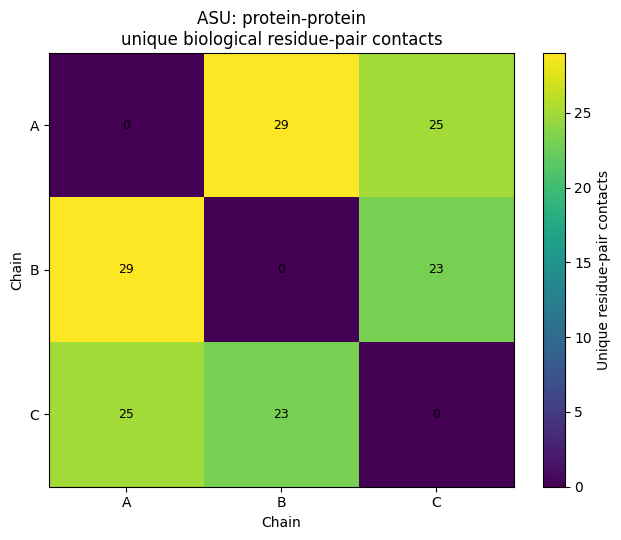

Saved → /content/figures/heatmap_ASU_protein-protein.png


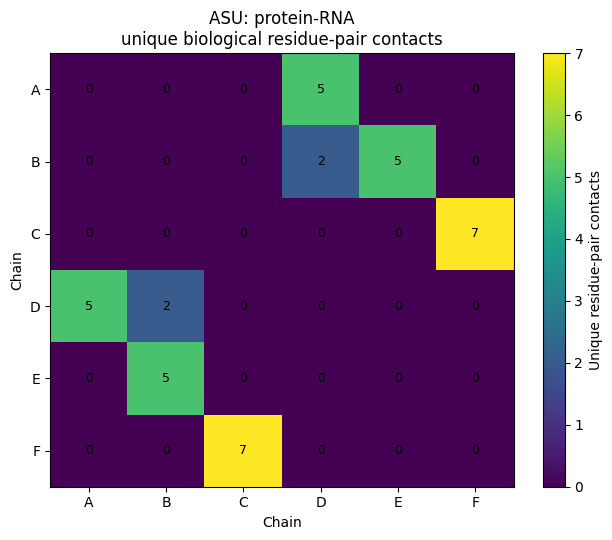

Saved → /content/figures/heatmap_ASU_protein-RNA.png


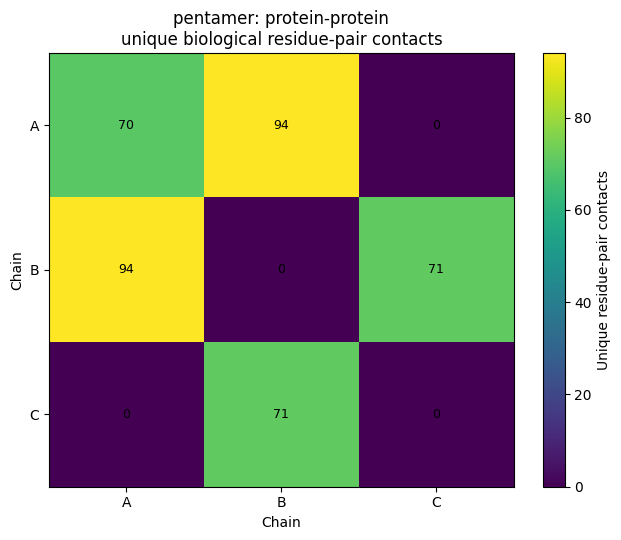

Saved → /content/figures/heatmap_pentamer_protein-protein.png


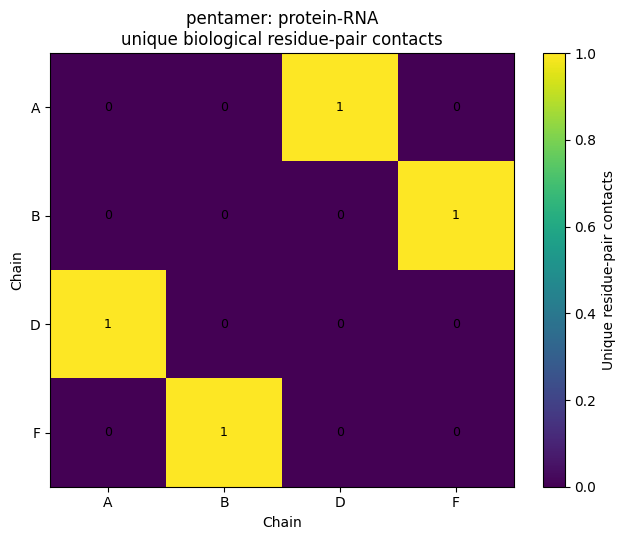

Saved → /content/figures/heatmap_pentamer_protein-RNA.png


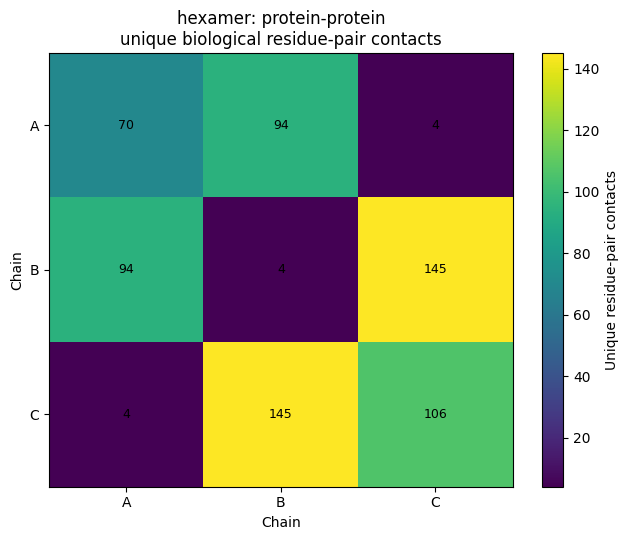

Saved → /content/figures/heatmap_hexamer_protein-protein.png


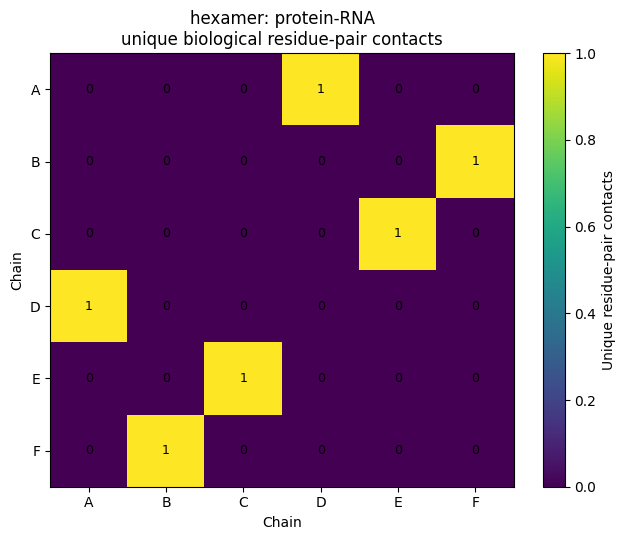

Saved → /content/figures/heatmap_hexamer_protein-RNA.png


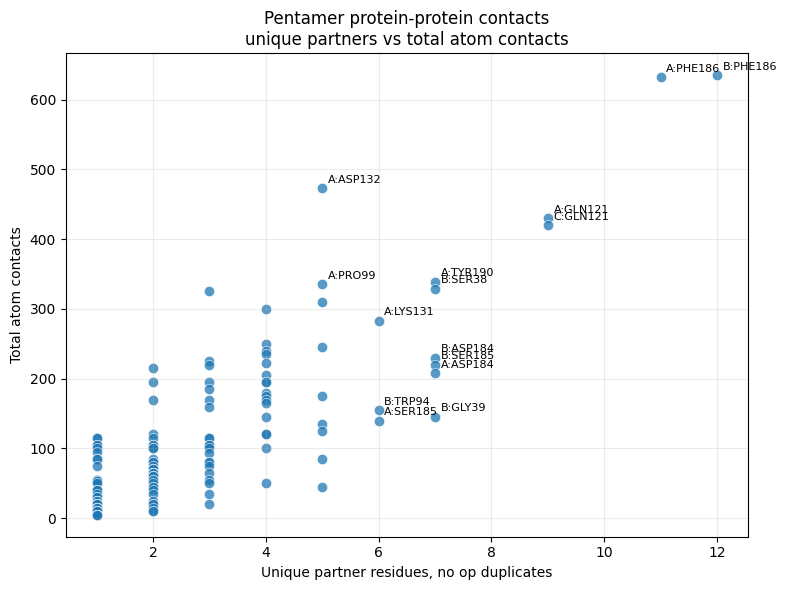

Saved → /content/figures/scatter_pentamer_protein_protein.png


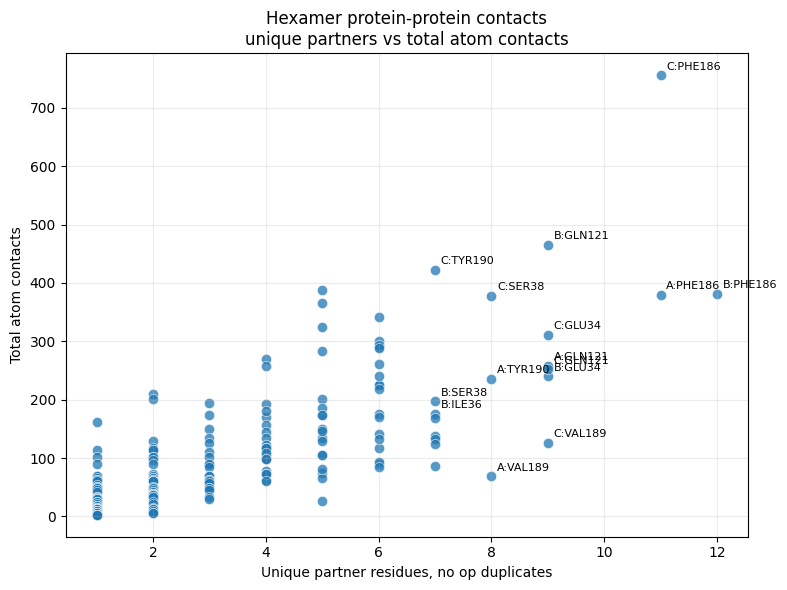

Saved → /content/figures/scatter_hexamer_protein_protein.png


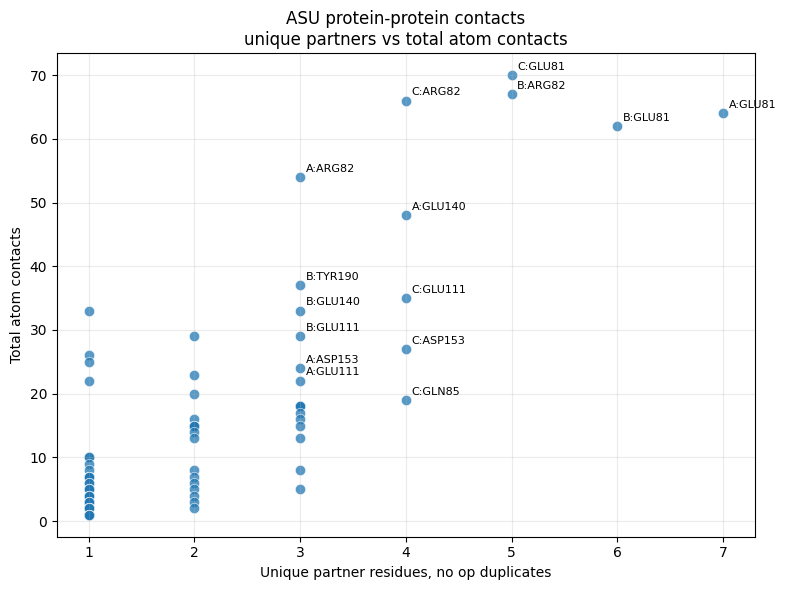

Saved → /content/figures/scatter_ASU_protein_protein.png


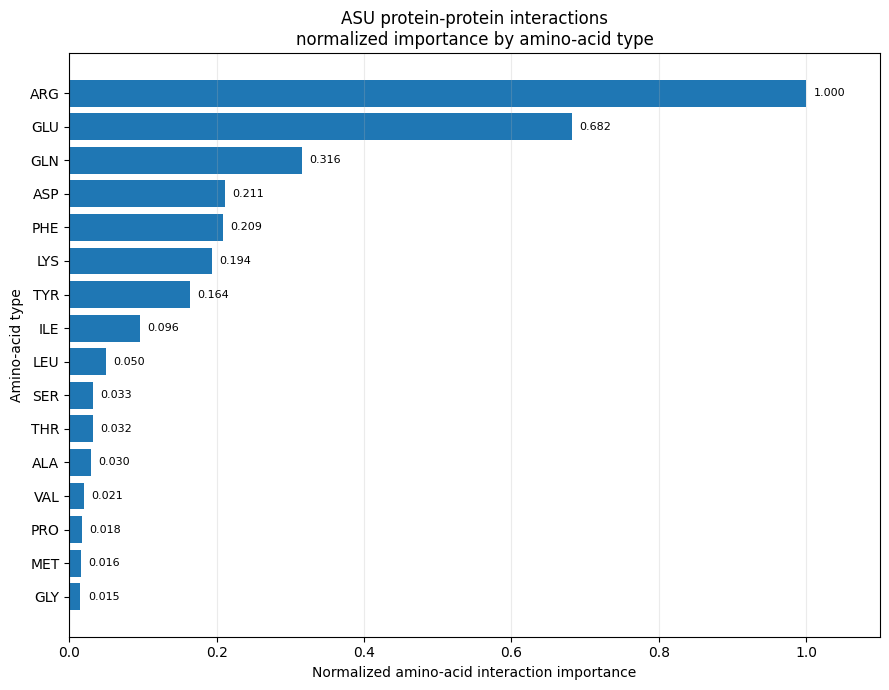

Saved → /content/figures/normalized_amino_acids_ASU_protein_protein.png


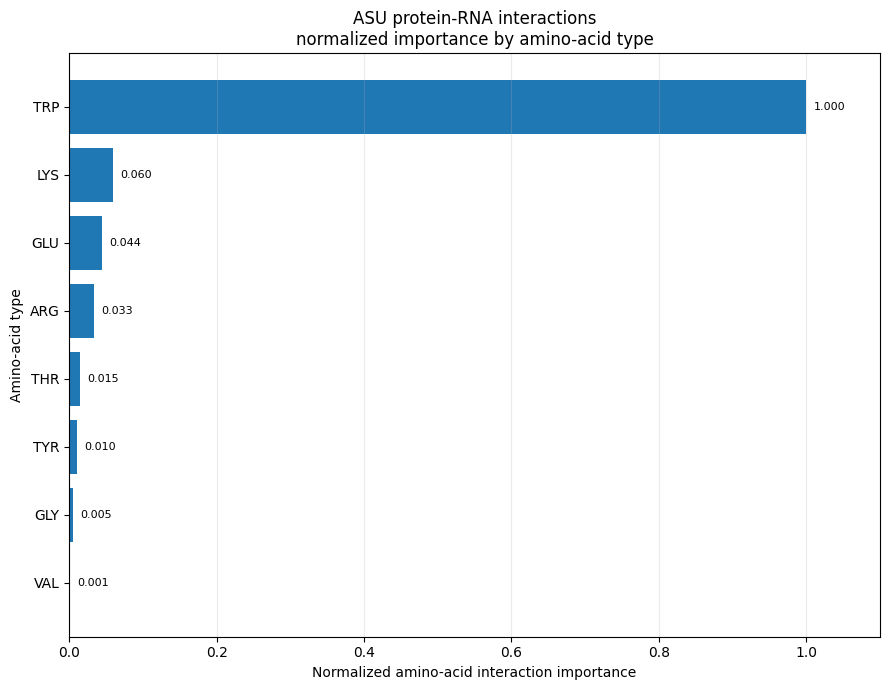

Saved → /content/figures/normalized_amino_acids_ASU_protein_RNA.png


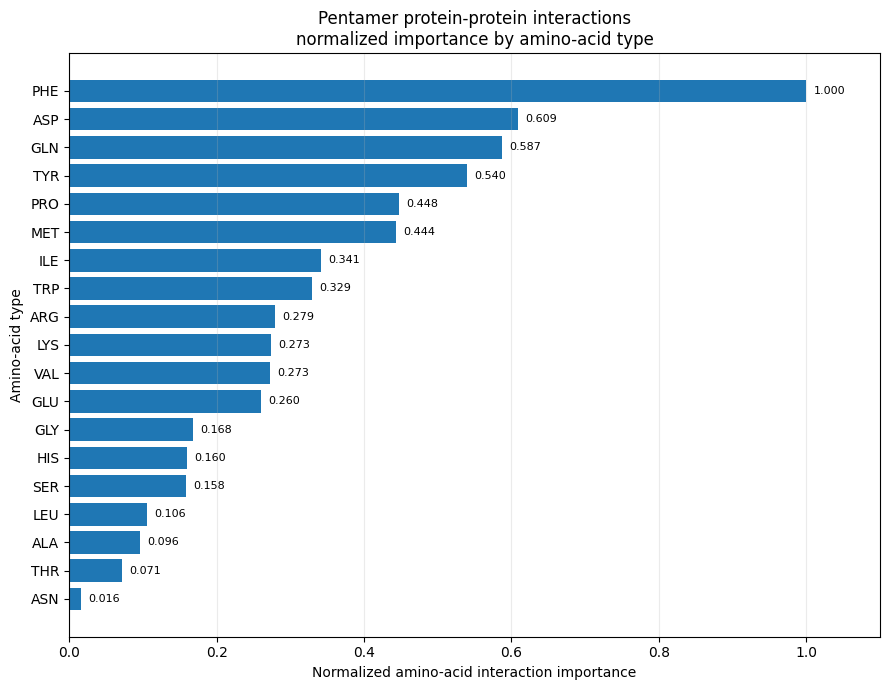

Saved → /content/figures/normalized_amino_acids_pentamer_protein_protein.png


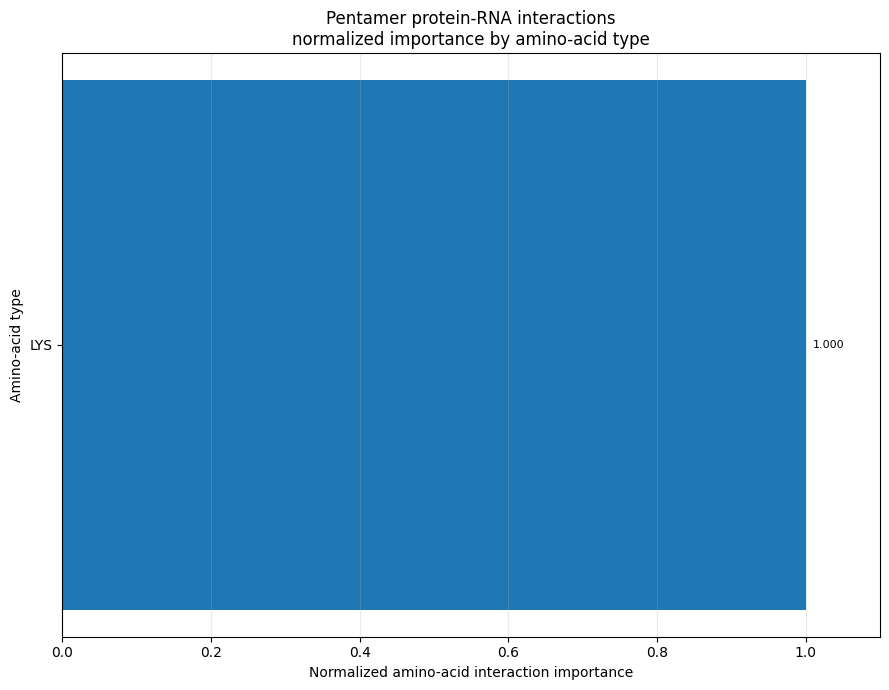

Saved → /content/figures/normalized_amino_acids_pentamer_protein_RNA.png


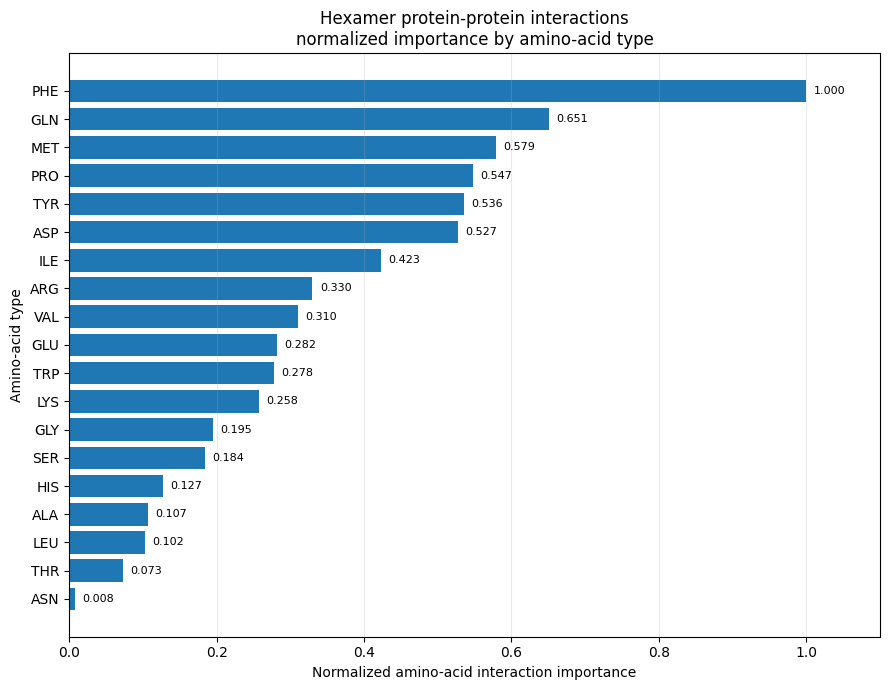

Saved → /content/figures/normalized_amino_acids_hexamer_protein_protein.png


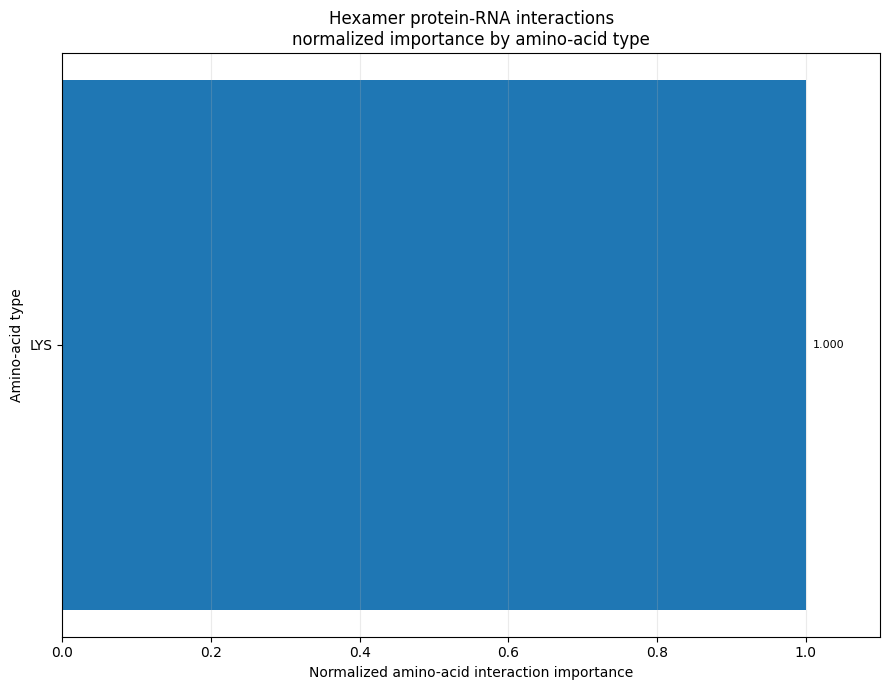

Saved → /content/figures/normalized_amino_acids_hexamer_protein_RNA.png

TOP ASU protein-protein residues


,assembly,chain,label_asym_id,residue_number,residue_name,molecule_type,target_identity,n_unique_partner_identities_no_op,n_biological_residue_pair_identities,n_target_copies_observed,target_copies_observed,n_copy_specific_pair_occurrences,total_atom_contacts,min_distance_A,interaction_families,partner_residues_clean
0,ASU,A,D,81,GLU,protein,protein_A:GLU81,7,7,1,op0,1,64,2.752633,"polar/H-bond-like, protein-protein close contact","protein_C:ALA141, protein_C:ASP153, protein_C:..."
1,ASU,B,E,81,GLU,protein,protein_B:GLU81,6,6,1,op0,1,62,2.911503,"polar/H-bond-like, protein-protein close contact","protein_A:ASP153, protein_A:GLN149, protein_A:..."
2,ASU,C,F,81,GLU,protein,protein_C:GLU81,5,5,1,op0,1,70,2.937923,"polar/H-bond-like, protein-protein close contact","protein_B:ASP153, protein_B:GLN149, protein_B:..."
3,ASU,B,E,82,ARG,protein,protein_B:ARG82,5,5,1,op0,1,67,2.673504,"polar/H-bond-like, protein-protein close conta...","protein_A:ALA141, protein_A:GLU140, protein_A:..."
4,ASU,C,F,82,ARG,protein,protein_C:ARG82,4,4,1,op0,1,66,2.451618,"polar/H-bond-like, protein-protein close conta...","protein_B:ALA141, protein_B:GLU140, protein_B:..."
5,ASU,A,D,140,GLU,protein,protein_A:GLU140,4,4,1,op0,1,48,2.673504,"polar/H-bond-like, protein-protein close conta...","protein_B:ARG82, protein_B:PHE182, protein_B:S..."
6,ASU,C,F,111,GLU,protein,protein_C:GLU111,4,4,1,op0,1,35,2.868534,"polar/H-bond-like, protein-protein close contact","protein_A:GLU81, protein_A:LYS84, protein_A:SE..."
7,ASU,C,F,153,ASP,protein,protein_C:ASP153,4,4,1,op0,1,27,2.752633,"polar/H-bond-like, protein-protein close contact","protein_A:GLN85, protein_A:GLU148, protein_A:G..."
8,ASU,C,F,85,GLN,protein,protein_C:GLN85,4,4,1,op0,1,19,2.613392,"polar/H-bond-like, protein-protein close contact","protein_B:GLN149, protein_B:GLY144, protein_B:..."
9,ASU,A,D,82,ARG,protein,protein_A:ARG82,3,3,1,op0,1,54,2.684566,"protein-protein close contact, salt-bridge-like","protein_C:ALA141, protein_C:GLU140, protein_C:..."



TOP ASU protein-RNA residues


,assembly,chain,label_asym_id,residue_number,residue_name,molecule_type,target_identity,n_unique_partner_identities_no_op,n_biological_residue_pair_identities,n_target_copies_observed,target_copies_observed,n_copy_specific_pair_occurrences,total_atom_contacts,min_distance_A,interaction_families,partner_residues_clean
0,ASU,C,F,140,GLU,protein,protein_C:GLU140,2,2,1,op0,1,21,2.338771,"protein-RNA nonspecific contact, protein-RNA p...","RNA_F:A201, RNA_F:U202"
1,ASU,C,F,143,LYS,protein,protein_C:LYS143,2,2,1,op0,1,19,2.678449,"protein-RNA nonspecific contact, protein-RNA p...","RNA_F:A201, RNA_F:U202"
2,ASU,B,E,143,LYS,protein,protein_B:LYS143,2,2,1,op0,1,18,2.833679,protein-RNA nonspecific contact,"RNA_E:A201, RNA_E:U202"
3,ASU,A,D,143,LYS,protein,protein_A:LYS143,2,2,1,op0,1,6,4.105404,protein-RNA nonspecific contact,"RNA_D:A201, RNA_D:U202"
4,ASU,C,F,47,TRP,protein,protein_C:TRP47,1,1,1,op0,1,89,3.327780,protein-RNA aromatic/base-proximal,RNA_F:A201
5,ASU,B,E,47,TRP,protein,protein_B:TRP47,1,1,1,op0,1,76,3.750652,protein-RNA aromatic/base-proximal,RNA_E:A201
6,ASU,A,D,47,TRP,protein,protein_A:TRP47,1,1,1,op0,1,75,3.707281,protein-RNA aromatic/base-proximal,RNA_D:A201
7,ASU,A,D,48,THR,protein,protein_A:THR48,1,1,1,op0,1,16,3.333054,"protein-RNA nonspecific contact, protein-RNA p...",RNA_D:A201
8,ASU,B,E,140,GLU,protein,protein_B:GLU140,1,1,1,op0,1,13,2.983727,"protein-RNA nonspecific contact, protein-RNA p...",RNA_E:A201
9,ASU,C,F,90,ARG,protein,protein_C:ARG90,1,1,1,op0,1,8,4.334738,"RNA-phosphate-contact, protein-RNA nonspecific...",RNA_F:A201



TOP pentamer protein-protein residues


...


TOP hexamer protein-protein residues


,assembly,chain,label_asym_id,residue_number,residue_name,molecule_type,target_identity,n_unique_partner_identities_no_op,n_biological_residue_pair_identities,n_target_copies_observed,target_copies_observed,n_copy_specific_pair_occurrences,total_atom_contacts,min_distance_A,interaction_families,partner_residues_clean
0,hexamer,B,E,186,PHE,protein,protein_B:PHE186,12,12,3,"op0, op3, op4",3,381,2.974119,"hydrophobic-like, polar/H-bond-like, protein-p...","protein_A:ALA43, protein_A:ARG90, protein_A:GL..."
1,hexamer,C,F,186,PHE,protein,protein_C:PHE186,11,11,6,"op0, op1, op2, op3, op4, op5",3,756,2.937436,"hydrophobic-like, polar/H-bond-like, protein-p...","protein_C:ALA43, protein_C:ARG90, protein_C:GL..."
2,hexamer,A,D,186,PHE,protein,protein_A:PHE186,11,11,3,"op1, op2, op5",3,380,2.846085,"hydrophobic-like, polar/H-bond-like, protein-p...","protein_B:ALA43, protein_B:ARG90, protein_B:GL..."
3,hexamer,C,F,34,GLU,protein,protein_C:GLU34,9,9,6,"op0, op1, op2, op3, op4, op5",9,311,2.933881,"polar/H-bond-like, protein-protein close conta...","protein_B:GLN40, protein_B:GLY41, protein_B:IL..."
4,hexamer,B,E,34,GLU,protein,protein_B:GLU34,9,9,6,"op0, op1, op2, op3, op4, op5",9,240,3.035475,"polar/H-bond-like, protein-protein close conta...","protein_B:VAL28 [op0-op3, op0-op4, op3-op4], p..."
5,hexamer,C,F,189,VAL,protein,protein_C:VAL189,9,9,6,"op0, op1, op2, op3, op4, op5",6,126,3.739824,"hydrophobic-like, protein-protein close contact","protein_B:ALA37 [op0-op3, op0-op4, op3-op4], p..."
6,hexamer,B,E,121,GLN,protein,protein_B:GLN121,9,9,6,"op0, op1, op2, op3, op4, op5",3,465,3.033220,"polar/H-bond-like, protein-protein close contact","protein_C:ASP168, protein_C:GLY167, protein_C:..."
7,hexamer,A,D,121,GLN,protein,protein_A:GLN121,9,9,3,"op0, op3, op4",3,258,2.817380,"polar/H-bond-like, protein-protein close contact","protein_A:ASP168, protein_A:GLY167, protein_A:..."
8,hexamer,C,F,121,GLN,protein,protein_C:GLN121,9,9,3,"op1, op2, op5",3,252,2.889312,"polar/H-bond-like, protein-protein close contact","protein_B:ASP168, protein_B:GLY167, protein_B:..."
9,hexamer,A,D,190,TYR,protein,protein_A:TYR190,8,8,3,"op1, op2, op5",6,236,3.075450,"hydrophobic-like, polar/H-bond-like, protein-p...","protein_B:ALA37, protein_B:ASP132, protein_B:G..."



TOP hexamer protein-RNA residues


,assembly,chain,label_asym_id,residue_number,residue_name,molecule_type,target_identity,n_unique_partner_identities_no_op,n_biological_residue_pair_identities,n_target_copies_observed,target_copies_observed,n_copy_specific_pair_occurrences,total_atom_contacts,min_distance_A,interaction_families,partner_residues_clean
0,hexamer,C,F,45,LYS,protein,protein_C:LYS45,1,1,6,"op0, op1, op2, op3, op4, op5",3,12,4.297682,"RNA-phosphate-contact, protein-RNA electrostat...",RNA_E:U202
1,hexamer,A,D,45,LYS,protein,protein_A:LYS45,1,1,3,"op1, op2, op5",3,3,4.591257,protein-RNA nonspecific contact,RNA_D:U202
2,hexamer,B,E,45,LYS,protein,protein_B:LYS45,1,1,3,"op0, op3, op4",3,3,4.867679,RNA-phosphate-contact,RNA_F:U202



DONE.

Most important files:
1. overlap_ASU_pentamer_hexamer_residues.csv
2. chain_pair_interaction_summary.csv
3. ASU_protein_protein_summary.csv
4. pentamer_protein_protein_summary.csv
5. hexamer_protein_protein_summary.csv
6. heatmap_ASU_protein-protein.png / heatmap_pentamer_protein-protein.png / heatmap_hexamer_protein-protein.png
7. scatter_ASU_protein_protein.png / scatter_pentamer_protein_protein.png / scatter_hexamer_protein_protein.png


In [ ]:
# ASU, PENTAMER, AND HEXAMER CONTACT-ANALYSIS IMPLEMENTATION

# ============================================================
# CCMV 1CWP — Corrected CIF interaction pipeline
# ============================================================
# What this script does:
# 1. Reads mmCIF biological assembly operators
# 2. Uses correct label_asym_id for assembly generation
# 3. Uses auth_asym_id for biological chain names:
#       protein chains A/B/C
#       RNA chains D/E/F
# 4. Builds:
#       ASU contacts
#       Assembly 3 pentamer contacts
#       Assembly 4 hexamer/quasi-hexamer contacts
# 5. Detects contacts in the range 1–5 Å
# 6. Classifies contacts:
#       salt-bridge-like
#       polar/H-bond-like
#       hydrophobic-like
#       RNA-phosphate-contact
#       protein-RNA electrostatic-like
# 7. Collapses op duplicates:
#       op0:protein_A:ALA43
#       op1:protein_A:ALA43
#    count as the same biological partner:
#       protein_A:ALA43
# 8. Produces:
#       residue summaries
#       overlap ASU/pentamer/hexamer
#       chain-pair heatmaps
#       scatter plots
# ============================================================


# ============================================================
# SETTINGS
# ===========================================================

MIN_DISTANCE = 1.0
MAX_DISTANCE = 5.0

ASSEMBLIES_TO_RUN = {
    "ASU": None,
    "pentamer": "3",
    "hexamer": "4"
}


# ============================================================
# BASIC DEFINITIONS
# ============================================================

STANDARD_AA = {
    "ALA", "ARG", "ASN", "ASP", "CYS",
    "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO",
    "SER", "THR", "TRP", "TYR", "VAL"
}

RNA_RESNAMES = {
    "A", "U", "G", "C",
    "RA", "RU", "RG", "RC",
    "ADE", "URA", "GUA", "CYT"
}

SOLVENT_RESNAMES = {
    "HOH", "WAT", "H2O", "DOD", "SOL",
    "TIP", "TIP3", "TIP3P", "SPC"
}

ACIDIC = {"ASP", "GLU"}
BASIC = {"LYS", "ARG", "HIS"}
HYDROPHOBIC = {"ALA", "VAL", "LEU", "ILE", "MET", "PHE", "TRP", "PRO", "TYR"}
AROMATIC = {"PHE", "TYR", "TRP", "HIS"}
BACKBONE_ATOMS = {"N", "CA", "C", "O", "OXT"}

# ============================================================
# MAIN PIPELINE
# ============================================================

print("=" * 70)
print("CCMV 1CWP — Corrected CIF interaction pipeline")
print("=" * 70)


# -----------------------------------------------------------------------
# Loads the mmCIF file and extracts assembly definitions and symmetry operators.
def read_cif_setup(cif_path):
    cif_dict = MMCIF2Dict.MMCIF2Dict(cif_path)

    assemblies_df = pd.DataFrame({
        "assembly_id": as_list(cif_dict["_pdbx_struct_assembly.id"]),
        "details": as_list(cif_dict["_pdbx_struct_assembly.details"]),
        "oligomeric_details": as_list(cif_dict["_pdbx_struct_assembly.oligomeric_details"]),
        "oligomeric_count": as_list(cif_dict["_pdbx_struct_assembly.oligomeric_count"])
    })

    assembly_gen_df = pd.DataFrame({
        "assembly_id": as_list(cif_dict["_pdbx_struct_assembly_gen.assembly_id"]),
        "oper_expression": as_list(cif_dict["_pdbx_struct_assembly_gen.oper_expression"]),
        "asym_id_list": as_list(cif_dict["_pdbx_struct_assembly_gen.asym_id_list"])
    })

    operators = get_operator_matrix_vector(cif_dict)

    safe_display(assemblies_df, "Available biological assemblies", 20)
    safe_display(assembly_gen_df, "Assembly generation rules", 20)

    return cif_dict, assemblies_df, assembly_gen_df, operators

cif_dict, assemblies_df, assembly_gen_df, operators = read_cif_setup(CIF_PATH)

# Use Assembly 3 atom selection because it contains the correct label_asym_id list A-F.
# The same A-F biological unit is also used for ASU and Assembly 4.
atom_df = extract_atom_df(cif_dict, assembly_gen_df, assembly_id="3")

# Requested preprocessing before finding interactions:
# 1. delete solvent
# 2. add/keep hydrogens
atom_df = prepare_atoms_before_interactions(atom_df)

# -----------------------------
# ASU
# -----------------------------
asu_atoms_df = generate_asu_atoms(atom_df)
asu_atom_contacts_raw_df = detect_contacts(asu_atoms_df, "ASU", mode="ASU")
asu_atom_contacts_df = remove_duplicate_atom_contacts(asu_atom_contacts_raw_df)
asu_residue_pairs_df = collapse_atom_to_residue_pairs(asu_atom_contacts_df)

asu_pp_summary_df, asu_pp_biological_pairs_df = summarize_no_op(asu_residue_pairs_df, "protein-protein")
asu_rna_summary_df, asu_rna_biological_pairs_df = summarize_no_op(asu_residue_pairs_df, "protein-RNA")

# -----------------------------
# Pentamer Assembly 3
# -----------------------------
penta_operator_ids, penta_expr = get_assembly_operator_ids(assembly_gen_df, "3")
print(f"\nPentamer Assembly 3 operators: {penta_expr} → {penta_operator_ids}")

pentamer_atoms_df = generate_transformed_atoms(atom_df, penta_operator_ids, operators, "pentamer")
pentamer_atom_contacts_raw_df = detect_contacts(pentamer_atoms_df, "pentamer", mode="assembly")
pentamer_atom_contacts_df = remove_duplicate_atom_contacts(pentamer_atom_contacts_raw_df)
pentamer_residue_pairs_df = collapse_atom_to_residue_pairs(pentamer_atom_contacts_df)

pentamer_pp_summary_df, pentamer_pp_biological_pairs_df = summarize_no_op(pentamer_residue_pairs_df, "protein-protein")
pentamer_rna_summary_df, pentamer_rna_biological_pairs_df = summarize_no_op(pentamer_residue_pairs_df, "protein-RNA")

# -----------------------------
# Hexamer Assembly 4
# -----------------------------
hexa_operator_ids, hexa_expr = get_assembly_operator_ids(assembly_gen_df, "4")
print(f"\nHexamer Assembly 4 operators: {hexa_expr} → {hexa_operator_ids}")

hexamer_atoms_df = generate_transformed_atoms(atom_df, hexa_operator_ids, operators, "hexamer")
hexamer_atom_contacts_raw_df = detect_contacts(hexamer_atoms_df, "hexamer", mode="assembly")
hexamer_atom_contacts_df = remove_duplicate_atom_contacts(hexamer_atom_contacts_raw_df)
hexamer_residue_pairs_df = collapse_atom_to_residue_pairs(hexamer_atom_contacts_df)

hexamer_pp_summary_df, hexamer_pp_biological_pairs_df = summarize_no_op(hexamer_residue_pairs_df, "protein-protein")
hexamer_rna_summary_df, hexamer_rna_biological_pairs_df = summarize_no_op(hexamer_residue_pairs_df, "protein-RNA")


# -----------------------------
# Normalized amino-acid importance
# -----------------------------
asu_amino_acid_abundance_df = build_amino_acid_abundance(asu_atoms_df)
pentamer_amino_acid_abundance_df = build_amino_acid_abundance(pentamer_atoms_df)
hexamer_amino_acid_abundance_df = build_amino_acid_abundance(hexamer_atoms_df)

asu_pp_normalized_amino_acids_df = build_normalized_amino_acid_importance(
     asu_pp_summary_df, asu_amino_acid_abundance_df
 )
asu_rna_normalized_amino_acids_df = build_normalized_amino_acid_importance(
     asu_rna_summary_df, asu_amino_acid_abundance_df
 )
pentamer_pp_normalized_amino_acids_df = build_normalized_amino_acid_importance(
     pentamer_pp_summary_df, pentamer_amino_acid_abundance_df
 )
pentamer_rna_normalized_amino_acids_df = build_normalized_amino_acid_importance(
     pentamer_rna_summary_df, pentamer_amino_acid_abundance_df
 )
hexamer_pp_normalized_amino_acids_df = build_normalized_amino_acid_importance(
     hexamer_pp_summary_df, hexamer_amino_acid_abundance_df
 )
hexamer_rna_normalized_amino_acids_df = build_normalized_amino_acid_importance(
     hexamer_rna_summary_df, hexamer_amino_acid_abundance_df
 )


# ============================================================
# SAVE RAW AND SUMMARY TABLES
# ============================================================

outputs = {
    "ASU_atom_contacts.csv": asu_atom_contacts_df,
    "ASU_residue_pairs.csv": asu_residue_pairs_df,
    "ASU_protein_protein_summary.csv": asu_pp_summary_df,
    "ASU_protein_RNA_summary.csv": asu_rna_summary_df,
    "ASU_protein_protein_biological_pairs.csv": asu_pp_biological_pairs_df,
    "ASU_protein_RNA_biological_pairs.csv": asu_rna_biological_pairs_df,

    "pentamer_atom_contacts.csv": pentamer_atom_contacts_df,
    "pentamer_residue_pairs.csv": pentamer_residue_pairs_df,
    "pentamer_protein_protein_summary.csv": pentamer_pp_summary_df,
    "pentamer_protein_RNA_summary.csv": pentamer_rna_summary_df,
    "pentamer_protein_protein_biological_pairs.csv": pentamer_pp_biological_pairs_df,
    "pentamer_protein_RNA_biological_pairs.csv": pentamer_rna_biological_pairs_df,

    "hexamer_atom_contacts.csv": hexamer_atom_contacts_df,
    "hexamer_residue_pairs.csv": hexamer_residue_pairs_df,
    "hexamer_protein_protein_summary.csv": hexamer_pp_summary_df,
    "hexamer_protein_RNA_summary.csv": hexamer_rna_summary_df,
    "hexamer_protein_protein_biological_pairs.csv": hexamer_pp_biological_pairs_df,
    "hexamer_protein_RNA_biological_pairs.csv": hexamer_rna_biological_pairs_df,

    # Raw contacts before canonical duplicate cleaning
    "ASU_atom_contacts_raw.csv": asu_atom_contacts_raw_df,
    "pentamer_atom_contacts_raw.csv": pentamer_atom_contacts_raw_df,
    "hexamer_atom_contacts_raw.csv": hexamer_atom_contacts_raw_df,

    # Normalized amino-acid importance tables
    "ASU_PP_normalized_amino_acids.csv": asu_pp_normalized_amino_acids_df,
    "ASU_RNA_normalized_amino_acids.csv": asu_rna_normalized_amino_acids_df,
    "pentamer_PP_normalized_amino_acids.csv": pentamer_pp_normalized_amino_acids_df,
    "pentamer_RNA_normalized_amino_acids.csv": pentamer_rna_normalized_amino_acids_df,
    "hexamer_PP_normalized_amino_acids.csv": hexamer_pp_normalized_amino_acids_df,
    "hexamer_RNA_normalized_amino_acids.csv": hexamer_rna_normalized_amino_acids_df,
}

for filename, df in outputs.items():
    path = os.path.join(OUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved → {path}")


# ============================================================
# OVERLAP TABLE
# ============================================================

overlap_df = overlap_summary(
    asu_pp_summary_df,
    asu_rna_summary_df,
    pentamer_pp_summary_df,
    pentamer_rna_summary_df,
    hexamer_pp_summary_df,
    hexamer_rna_summary_df
)

overlap_path = os.path.join(OUT_DIR, "overlap_ASU_pentamer_hexamer_residues.csv")
overlap_df.to_csv(overlap_path, index=False)
print(f"Saved → {overlap_path}")

safe_display(
    overlap_df[overlap_df["n_contexts_any"] >= 2],
    "Residues appearing in at least two contexts: ASU / pentamer / hexamer",
    50
)


# ============================================================
# CHAIN-PAIR HEATMAPS
# ============================================================

all_residue_pairs_df = pd.concat(
    [
        asu_residue_pairs_df,
        pentamer_residue_pairs_df,
        hexamer_residue_pairs_df
    ],
    ignore_index=True
)

chain_pair_summary_df = make_chain_pair_summary(all_residue_pairs_df)

chain_pair_summary_path = os.path.join(OUT_DIR, "chain_pair_interaction_summary.csv")
chain_pair_summary_df.to_csv(chain_pair_summary_path, index=False)
print(f"Saved → {chain_pair_summary_path}")

safe_display(chain_pair_summary_df, "Chain-pair interaction summary", 50)

for assembly_name in ["ASU", "pentamer", "hexamer"]:
    for category in ["protein-protein", "protein-RNA"]:
        plot_chain_heatmap(
            chain_pair_summary_df,
            assembly_name,
            category,
            os.path.join(FIGURES_DIR, f"heatmap_{assembly_name}_{category}.png")
        )


# ============================================================
# SCATTER PLOTS
# ============================================================

plot_scatter(
    pentamer_pp_summary_df,
    "Pentamer protein-protein contacts\nunique partners vs total atom contacts",
    os.path.join(FIGURES_DIR, "scatter_pentamer_protein_protein.png")
)

plot_scatter(
    hexamer_pp_summary_df,
    "Hexamer protein-protein contacts\nunique partners vs total atom contacts",
    os.path.join(FIGURES_DIR, "scatter_hexamer_protein_protein.png")
)

plot_scatter(
    asu_pp_summary_df,
    "ASU protein-protein contacts\nunique partners vs total atom contacts",
    os.path.join(FIGURES_DIR, "scatter_ASU_protein_protein.png")
)


# ============================================================
# NORMALIZED AMINO-ACID IMPORTANCE PLOTS
# ============================================================

normalized_amino_acid_plots = [
    (
        asu_pp_normalized_amino_acids_df,
        "ASU protein-protein interactions\nnormalized importance by amino-acid type",
        "normalized_amino_acids_ASU_protein_protein.png"
    ),
    (
        asu_rna_normalized_amino_acids_df,
        "ASU protein-RNA interactions\nnormalized importance by amino-acid type",
        "normalized_amino_acids_ASU_protein_RNA.png"
    ),
    (
        pentamer_pp_normalized_amino_acids_df,
        "Pentamer protein-protein interactions\nnormalized importance by amino-acid type",
        "normalized_amino_acids_pentamer_protein_protein.png"
    ),
    (
        pentamer_rna_normalized_amino_acids_df,
        "Pentamer protein-RNA interactions\nnormalized importance by amino-acid type",
        "normalized_amino_acids_pentamer_protein_RNA.png"
    ),
    (
        hexamer_pp_normalized_amino_acids_df,
        "Hexamer protein-protein interactions\nnormalized importance by amino-acid type",
        "normalized_amino_acids_hexamer_protein_protein.png"
    ),
    (
        hexamer_rna_normalized_amino_acids_df,
        "Hexamer protein-RNA interactions\nnormalized importance by amino-acid type",
        "normalized_amino_acids_hexamer_protein_RNA.png"
    )
]

for dataframe, title, filename in normalized_amino_acid_plots:
    plot_normalized_amino_acid_importance(
        dataframe,
        title,
        os.path.join(FIGURES_DIR, filename)
    )


# ============================================================
# TOP TABLES
# ============================================================

TOP_N = 30

safe_display(
    asu_pp_summary_df.head(TOP_N),
    "TOP ASU protein-protein residues",
    TOP_N
)

safe_display(
    asu_rna_summary_df.head(TOP_N),
    "TOP ASU protein-RNA residues",
    TOP_N
)

safe_display(
    pentamer_pp_summary_df.head(TOP_N),
    "TOP pentamer protein-protein residues",
    TOP_N
)

safe_display(
    pentamer_rna_summary_df.head(TOP_N),
    "TOP pentamer protein-RNA residues",
    TOP_N
)

safe_display(
    hexamer_pp_summary_df.head(TOP_N),
    "TOP hexamer protein-protein residues",
    TOP_N
)

safe_display(
    hexamer_rna_summary_df.head(TOP_N),
    "TOP hexamer protein-RNA residues",
    TOP_N
)


# ============================================================
# FINAL NOTES
# ============================================================

print("\nDONE.")
print("\nMost important files:")
print("1. overlap_ASU_pentamer_hexamer_residues.csv")
print("2. chain_pair_interaction_summary.csv")
print("3. ASU_protein_protein_summary.csv")
print("4. pentamer_protein_protein_summary.csv")
print("5. hexamer_protein_protein_summary.csv")


print("6. heatmap_ASU_protein-protein.png / heatmap_pentamer_protein-protein.png / heatmap_hexamer_protein-protein.png")
print("7. scatter_ASU_protein_protein.png / scatter_pentamer_protein_protein.png / scatter_hexamer_protein_protein.png")


Pentamer and hexamer interface rows
Rows before biological-position collapsing: 342

Top biological residue positions at capsid interfaces


,rank,biological_residue_key,chain,residue_number,residue_name,n_interface_contexts,interface_contexts,maximum_unique_partners_in_one_context,summed_unique_partners_across_contexts,maximum_biological_pairs_in_one_context,summed_biological_pairs_across_contexts,total_copy_specific_occurrences,total_atom_contacts_across_contexts,total_Hbond_like_interactions_across_contexts,minimum_contact_distance_A,interaction_families,partner_residues,raw_residue_interface_score,normalized_residue_interface_importance
0,1,B:PHE186,B,186,PHE,2,"hexamer, pentamer",12,24,12,24,8,1016,0,2.974,"hydrophobic-like, polar/H-bond-like, protein-p...","protein_A:ALA43, protein_A:ARG90, protein_A:GL...",74.925,1.000
1,2,A:PHE186,A,186,PHE,2,"hexamer, pentamer",11,22,11,22,8,1012,0,2.846,"hydrophobic-like, polar/H-bond-like, protein-p...","protein_B:ALA43, protein_B:ARG90, protein_B:GL...",69.921,0.933
2,3,C:PHE186,C,186,PHE,1,hexamer,11,11,11,11,3,756,0,2.937,"hydrophobic-like, polar/H-bond-like, protein-p...","protein_C:ALA43, protein_C:ARG90, protein_C:GL...",65.629,0.876
3,4,A:GLN121,A,121,GLN,2,"hexamer, pentamer",9,18,9,18,8,688,0,2.817,"polar/H-bond-like, protein-protein close contact","protein_A:ASP168, protein_A:GLY167, protein_A:...",59.535,0.795
4,5,C:GLN121,C,121,GLN,2,"hexamer, pentamer",9,18,9,18,8,672,0,2.889,"polar/H-bond-like, protein-protein close contact","protein_B:ASP168, protein_B:GLY167, protein_B:...",59.512,0.794
5,6,C:GLU34,C,34,GLU,2,"hexamer, pentamer",9,13,9,13,14,431,0,2.934,"polar/H-bond-like, protein-protein close conta...","protein_B:GLN40, protein_B:GLY41, protein_B:IL...",59.068,0.788
6,7,B:GLU34,B,34,GLU,2,"hexamer, pentamer",9,13,9,13,14,410,0,3.035,"polar/H-bond-like, protein-protein close conta...","protein_B:VAL28 [op0-op3, op0-op4, op3-op4], p...",59.019,0.788
7,8,B:GLN121,B,121,GLN,1,hexamer,9,9,9,9,3,465,0,3.033,"polar/H-bond-like, protein-protein close contact","protein_C:ASP168, protein_C:GLY167, protein_C:...",55.144,0.736
8,9,A:TYR190,A,190,TYR,2,"hexamer, pentamer",8,15,8,15,11,575,0,3.075,"hydrophobic-like, polar/H-bond-like, protein-p...","protein_B:ALA37, protein_B:ASP132, protein_B:G...",54.356,0.725
9,10,C:VAL189,C,189,VAL,1,hexamer,9,9,9,9,6,126,0,3.740,"hydrophobic-like, protein-protein close contact","protein_B:ALA37 [op0-op3, op0-op4, op3-op4], p...",53.844,0.719



Estimated amino-acid abundance in the full capsid


,amino_acid,n_instances_in_A_B_C_unit,estimated_instances_in_full_capsid
0,ALA,65,3900
19,VAL,56,3360
15,SER,47,2820
10,LEU,45,2700
16,THR,42,2520
6,GLU,29,1740
11,LYS,27,1620
9,ILE,22,1320
7,GLY,22,1320
14,PRO,19,1140



Capsid-wide amino-acid interface importance


,rank,amino_acid,n_unique_interface_positions,n_positions_present_in_both_interfaces,summed_interface_contexts,summed_unique_partners,summed_biological_pairs,summed_copy_specific_occurrences,summed_atom_contacts,summed_Hbond_like_interactions,...,n_instances_in_A_B_C_unit,estimated_instances_in_full_capsid,fraction_of_A_B_C_positions_at_interface,unique_partners_per_amino_acid_instance,biological_pairs_per_amino_acid_instance,atom_contacts_per_amino_acid_instance,Hbond_like_per_amino_acid_instance,shared_interface_positions_per_instance,raw_capsid_interface_importance_score,normalized_capsid_interface_importance
0,1,PHE,9,6,15,83,83,57,3610,0,...,12,720,0.750,6.917,6.917,300.833,0.0,0.500,47.752,1.000
1,2,MET,3,3,6,16,16,30,468,0,...,3,180,1.000,5.333,5.333,156.000,0.0,1.000,40.390,0.846
2,3,GLN,7,6,13,75,75,69,2995,0,...,16,960,0.438,4.688,4.688,187.188,0.0,0.375,33.519,0.702
3,4,PRO,13,9,22,81,81,102,2873,0,...,19,1140,0.684,4.263,4.263,151.211,0.0,0.474,32.157,0.673
4,5,ASP,12,8,20,73,73,76,3054,0,...,18,1080,0.667,4.056,4.056,169.667,0.0,0.444,31.001,0.649
5,6,TYR,9,6,15,43,43,63,2426,0,...,15,900,0.600,2.867,2.867,161.733,0.0,0.400,24.059,0.504
6,7,VAL,33,24,57,161,161,255,4942,0,...,56,3360,0.589,2.875,2.875,88.250,0.0,0.429,23.518,0.493
7,8,TRP,3,2,5,28,28,19,815,0,...,9,540,0.333,3.111,3.111,90.556,0.0,0.222,23.406,0.490
8,9,LYS,16,12,28,74,74,129,2152,0,...,27,1620,0.593,2.741,2.741,79.704,0.0,0.444,22.724,0.476
9,10,ILE,10,9,19,60,60,96,2556,0,...,22,1320,0.455,2.727,2.727,116.182,0.0,0.409,22.400,0.469


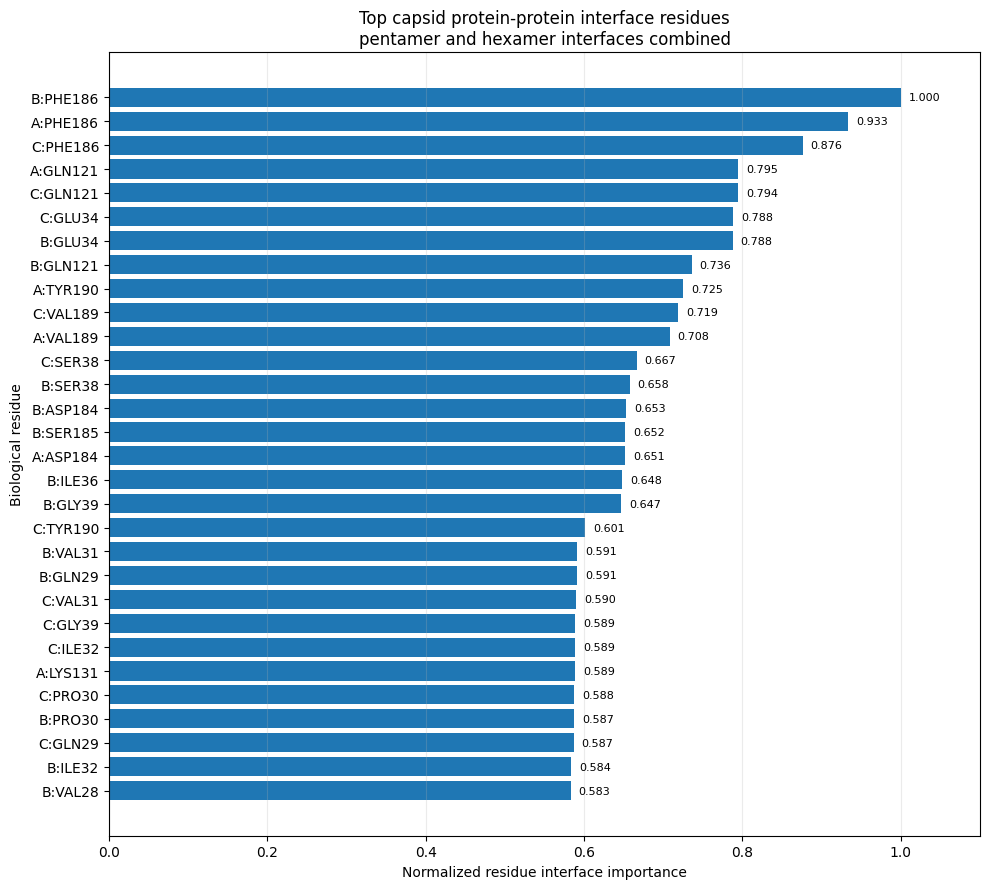

Saved → /content/figures/top_capsid_interface_residues.png


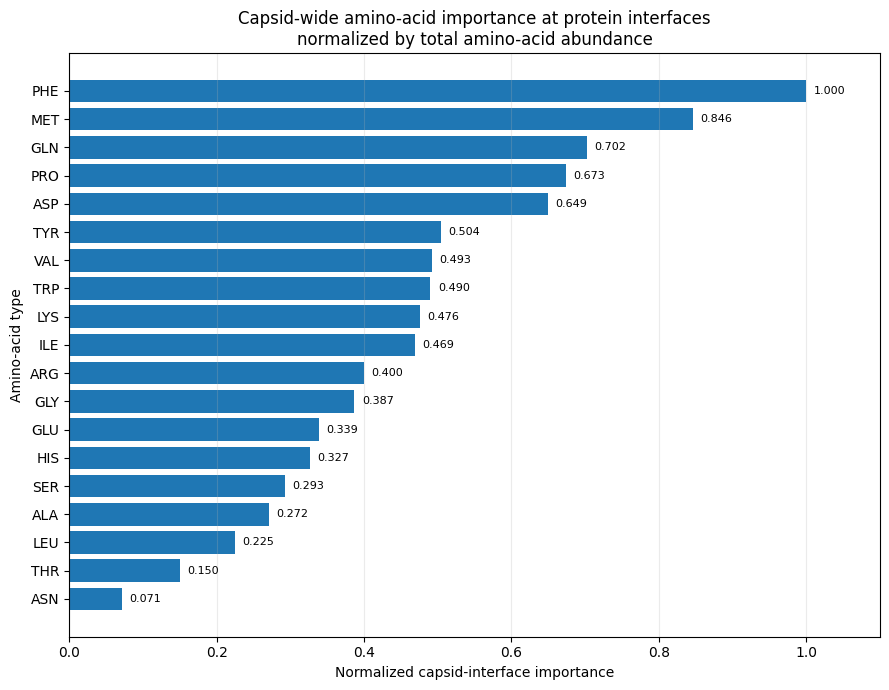

Saved → /content/figures/normalized_capsid_amino_acid_interface_importance.png


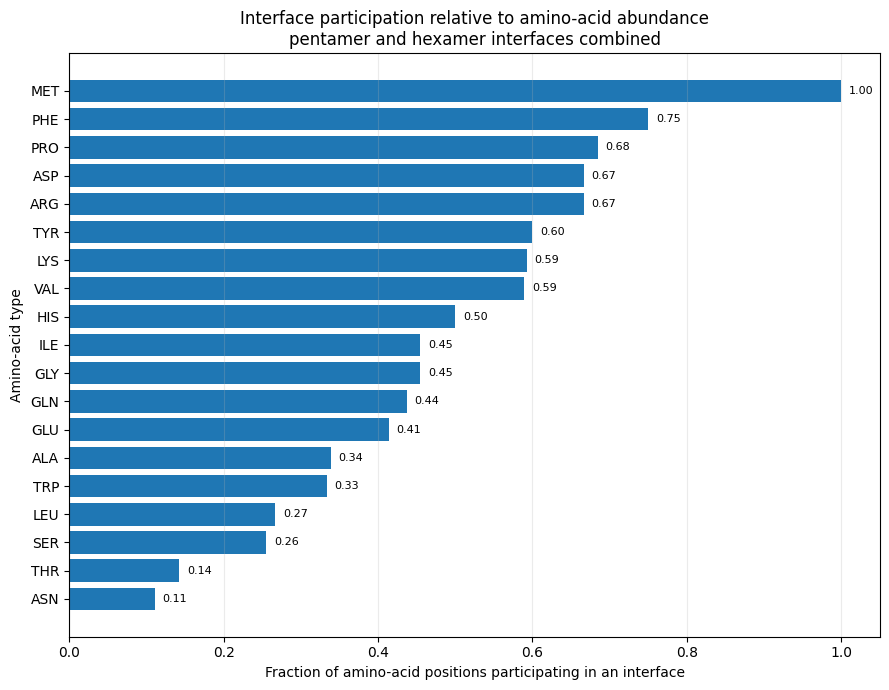

Saved → /content/figures/capsid_amino_acid_interface_participation_fraction.png

Saved capsid-interface outputs
/content/outputs/csv_outputs/capsid_top_interface_residue_positions.csv
/content/outputs/csv_outputs/capsid_normalized_amino_acid_interface_importance.csv
/content/outputs/csv_outputs/capsid_amino_acid_abundance.csv
/content/figures/top_capsid_interface_residues.png
/content/figures/normalized_capsid_amino_acid_interface_importance.png
/content/figures/capsid_amino_acid_interface_participation_fraction.png

Final duplicate validation
Duplicate biological residue positions remaining: 0
Duplicate amino-acid-type rows remaining: 0


In [ ]:
# CAPSID-WIDE PROTEIN–PROTEIN INTERFACE-IMPORTANCE IMPLEMENTATION

# ============================================================
# CAPSIDE-WIDE PROTEIN-PROTEIN INTERFACE IMPORTANCE
#
# Purpose:
# 1. Combine pentamer and hexamer protein-protein interfaces
# 2. Remove duplicate biological residue positions
# 3. Rank specific interface residues, e.g. B:ARG82
# 4. Rank amino-acid types, e.g. ARG, GLU, TYR
# 5. Normalize by total amino-acid abundance in the full capsid
#
# Required existing variables:
#   atom_df
#   pentamer_pp_summary_df
#   hexamer_pp_summary_df
#
# Optional existing columns:
#   total_Hbond_like_interactions
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 1. Settings
# ============================================================

if "OUT_DIR" not in globals():
    OUT_DIR = "csv_outputs"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)

CAPSID_COPIES_PER_ASU_CHAIN = 60

PROTEIN_CHAINS = [
    "A",
    "B",
    "C"
]

TOP_N_INTERFACE_RESIDUES = 30
TOP_N_AMINO_ACIDS = 20


# ============================================================
# 2. Validate required variables
# ============================================================

required_variables = [
    "atom_df",
    "pentamer_pp_summary_df",
    "hexamer_pp_summary_df"
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the previous interaction pipeline first. "
        "Missing variables: "
        + ", ".join(missing_variables)
    )


# ============================================================
# 3. Prepare one interface-summary table
# ============================================================



pentamer_interface_df = prepare_interface_summary(
    pentamer_pp_summary_df,
    "pentamer"
)

hexamer_interface_df = prepare_interface_summary(
    hexamer_pp_summary_df,
    "hexamer"
)


combined_interface_rows_df = pd.concat(
    [
        pentamer_interface_df,
        hexamer_interface_df
    ],
    ignore_index=True
)


# Keep only protein chains A/B/C.
combined_interface_rows_df = (
    combined_interface_rows_df[
        combined_interface_rows_df[
            "chain"
        ].astype(str).isin(
            PROTEIN_CHAINS
        )
    ]
    .copy()
    .reset_index(drop=True)
)


print("\nPentamer and hexamer interface rows")
print("====================================")
print(
    f"Rows before biological-position collapsing: "
    f"{len(combined_interface_rows_df)}"
)


# ============================================================
# 4. Collapse pentamer/hexamer duplicates by biological residue
# ============================================================
#
# Example:
#   pentamer B:ARG82
#   hexamer   B:ARG82
#
# become one residue:
#   B:ARG82
#
# The number of contexts is retained.

capsid_interface_residue_summary_df = (
    combined_interface_rows_df

    .groupby(
        [
            "biological_residue_key",
            "chain",
            "residue_number",
            "residue_name"
        ],
        as_index=False
    )

    .agg(
        n_interface_contexts=(
            "interface_context",
            "nunique"
        ),

        interface_contexts=(
            "interface_context",
            lambda values: ", ".join(
                sorted(
                    set(
                        values.astype(str)
                    )
                )
            )
        ),

        maximum_unique_partners_in_one_context=(
            "n_unique_partner_identities_no_op",
            "max"
        ),

        summed_unique_partners_across_contexts=(
            "n_unique_partner_identities_no_op",
            "sum"
        ),

        maximum_biological_pairs_in_one_context=(
            "n_biological_residue_pair_identities",
            "max"
        ),

        summed_biological_pairs_across_contexts=(
            "n_biological_residue_pair_identities",
            "sum"
        ),

        total_copy_specific_occurrences=(
            "n_copy_specific_pair_occurrences",
            "sum"
        ),

        total_atom_contacts_across_contexts=(
            "total_atom_contacts",
            "sum"
        ),

        total_Hbond_like_interactions_across_contexts=(
            "total_Hbond_like_interactions",
            "sum"
        ),

        minimum_contact_distance_A=(
            "min_distance_A",
            "min"
        ),

        interaction_families=(
            "interaction_families",
            lambda values: ", ".join(
                sorted(
                    set(
                        family
                        for value in values.dropna().astype(str)
                        for family in value.split(", ")
                        if family
                    )
                )
            )
        ),

        partner_residues=(
            "partner_residues_clean",
            lambda values: " | ".join(
                sorted(
                    set(
                        values.dropna().astype(str)
                    )
                )
            )
        )
    )
)


# ============================================================
# 5. Calculate residue-level interface importance
# ============================================================
#
# The ranking prioritizes:
# 1. Presence in both pentamer and hexamer
# 2. Unique biological partners
# 3. H-bond-like contacts
# 4. Total atom contacts
#
# Atom-contact counts are log-transformed so they do not dominate.

capsid_interface_residue_summary_df[
    "raw_residue_interface_score"
] = (
    4.0
    *
    capsid_interface_residue_summary_df[
        "n_interface_contexts"
    ]

    +
    3.0
    *
    capsid_interface_residue_summary_df[
        "maximum_unique_partners_in_one_context"
    ]

    +
    2.0
    *
    capsid_interface_residue_summary_df[
        "maximum_biological_pairs_in_one_context"
    ]

    +
    1.5
    *
    capsid_interface_residue_summary_df[
        "total_Hbond_like_interactions_across_contexts"
    ]

    +
    np.log1p(
        capsid_interface_residue_summary_df[
            "total_atom_contacts_across_contexts"
        ]
    )
)


maximum_residue_score = (
    capsid_interface_residue_summary_df[
        "raw_residue_interface_score"
    ].max()
)


if maximum_residue_score > 0:

    capsid_interface_residue_summary_df[
        "normalized_residue_interface_importance"
    ] = (
        capsid_interface_residue_summary_df[
            "raw_residue_interface_score"
        ]
        /
        maximum_residue_score
    )

else:

    capsid_interface_residue_summary_df[
        "normalized_residue_interface_importance"
    ] = 0.0


capsid_interface_residue_summary_df = (
    capsid_interface_residue_summary_df

    .sort_values(
        [
            "normalized_residue_interface_importance",
            "n_interface_contexts",
            "maximum_unique_partners_in_one_context",
            "total_Hbond_like_interactions_across_contexts",
            "total_atom_contacts_across_contexts"
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False
        ]
    )

    .reset_index(drop=True)
)


capsid_interface_residue_summary_df.insert(
    0,
    "rank",
    np.arange(
        1,
        len(
            capsid_interface_residue_summary_df
        ) + 1
    )
)


print("\nTop biological residue positions at capsid interfaces")
print("======================================================")

display(
    capsid_interface_residue_summary_df
    .head(
        TOP_N_INTERFACE_RESIDUES
    )
    .round(3)
)


# ============================================================
# 6. Count total amino-acid abundance in the whole capsid
# ============================================================
#
# atom_df contains the biological A/B/C chains once.
#
# Full capsid abundance:
#   abundance in chains A+B+C × 60
#
# The ×60 factor does not change relative enrichment, but it
# produces the actual estimated number of residue instances
# in the T=3 capsid.

protein_residue_instances_df = (
    atom_df[
        (
            atom_df[
                "molecule_type"
            ] == "protein"
        )
        &
        (
            atom_df[
                "auth_asym_id"
            ].astype(str).isin(
                PROTEIN_CHAINS
            )
        )
    ][
        [
            "auth_asym_id",
            "auth_residue_number",
            "resname"
        ]
    ]

    .drop_duplicates()

    .rename(
        columns={
            "auth_asym_id": "chain",
            "auth_residue_number": "residue_number",
            "resname": "amino_acid"
        }
    )
)


amino_acid_abundance_asu_df = (
    protein_residue_instances_df

    .groupby(
        "amino_acid"
    )

    .size()

    .reset_index(
        name="n_instances_in_A_B_C_unit"
    )
)


amino_acid_abundance_asu_df[
    "estimated_instances_in_full_capsid"
] = (
    amino_acid_abundance_asu_df[
        "n_instances_in_A_B_C_unit"
    ]
    *
    CAPSID_COPIES_PER_ASU_CHAIN
)


print("\nEstimated amino-acid abundance in the full capsid")
print("===================================================")

display(
    amino_acid_abundance_asu_df
    .sort_values(
        "estimated_instances_in_full_capsid",
        ascending=False
    )
)


# ============================================================
# 7. Collapse interface residues by amino-acid type
# ============================================================
#
# Residue positions are now removed:
#
#   A:ARG82
#   B:ARG82
#   C:ARG147
#
# all contribute to:
#
#   ARG

capsid_amino_acid_interface_importance_df = (
    capsid_interface_residue_summary_df

    .groupby(
        "residue_name"
    )

    .agg(
        n_unique_interface_positions=(
            "biological_residue_key",
            "nunique"
        ),

        n_positions_present_in_both_interfaces=(
            "n_interface_contexts",
            lambda values: int(
                (
                    values >= 2
                ).sum()
            )
        ),

        summed_interface_contexts=(
            "n_interface_contexts",
            "sum"
        ),

        summed_unique_partners=(
            "summed_unique_partners_across_contexts",
            "sum"
        ),

        summed_biological_pairs=(
            "summed_biological_pairs_across_contexts",
            "sum"
        ),

        summed_copy_specific_occurrences=(
            "total_copy_specific_occurrences",
            "sum"
        ),

        summed_atom_contacts=(
            "total_atom_contacts_across_contexts",
            "sum"
        ),

        summed_Hbond_like_interactions=(
            "total_Hbond_like_interactions_across_contexts",
            "sum"
        ),

        mean_residue_interface_importance=(
            "normalized_residue_interface_importance",
            "mean"
        ),

        maximum_residue_interface_importance=(
            "normalized_residue_interface_importance",
            "max"
        )
    )

    .reset_index()

    .rename(
        columns={
            "residue_name": "amino_acid"
        }
    )

    .merge(
        amino_acid_abundance_asu_df,
        on="amino_acid",
        how="left"
    )
)


capsid_amino_acid_interface_importance_df[
    "n_instances_in_A_B_C_unit"
] = (
    capsid_amino_acid_interface_importance_df[
        "n_instances_in_A_B_C_unit"
    ]
    .fillna(0)
    .astype(int)
)


capsid_amino_acid_interface_importance_df[
    "estimated_instances_in_full_capsid"
] = (
    capsid_amino_acid_interface_importance_df[
        "estimated_instances_in_full_capsid"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 8. Normalize interface participation by capsid abundance
# ============================================================

denominator_asu = (
    capsid_amino_acid_interface_importance_df[
        "n_instances_in_A_B_C_unit"
    ]
    .replace(
        0,
        np.nan
    )
)


capsid_amino_acid_interface_importance_df[
    "fraction_of_A_B_C_positions_at_interface"
] = (
    capsid_amino_acid_interface_importance_df[
        "n_unique_interface_positions"
    ]
    /
    denominator_asu
)


capsid_amino_acid_interface_importance_df[
    "unique_partners_per_amino_acid_instance"
] = (
    capsid_amino_acid_interface_importance_df[
        "summed_unique_partners"
    ]
    /
    denominator_asu
)


capsid_amino_acid_interface_importance_df[
    "biological_pairs_per_amino_acid_instance"
] = (
    capsid_amino_acid_interface_importance_df[
        "summed_biological_pairs"
    ]
    /
    denominator_asu
)


capsid_amino_acid_interface_importance_df[
    "atom_contacts_per_amino_acid_instance"
] = (
    capsid_amino_acid_interface_importance_df[
        "summed_atom_contacts"
    ]
    /
    denominator_asu
)


capsid_amino_acid_interface_importance_df[
    "Hbond_like_per_amino_acid_instance"
] = (
    capsid_amino_acid_interface_importance_df[
        "summed_Hbond_like_interactions"
    ]
    /
    denominator_asu
)


capsid_amino_acid_interface_importance_df[
    "shared_interface_positions_per_instance"
] = (
    capsid_amino_acid_interface_importance_df[
        "n_positions_present_in_both_interfaces"
    ]
    /
    denominator_asu
)


# ============================================================
# 9. Calculate normalized amino-acid interface importance
# ============================================================
#
# Main priorities:
# 1. Fraction of this amino acid participating in interfaces
# 2. Unique partners per available amino-acid instance
# 3. Presence in both pentamer and hexamer interfaces
# 4. H-bond-like contacts
# 5. Total atom contacts

capsid_amino_acid_interface_importance_df[
    "raw_capsid_interface_importance_score"
] = (
    4.0
    *
    capsid_amino_acid_interface_importance_df[
        "fraction_of_A_B_C_positions_at_interface"
    ]

    +
    3.0
    *
    capsid_amino_acid_interface_importance_df[
        "unique_partners_per_amino_acid_instance"
    ]

    +
    2.5
    *
    capsid_amino_acid_interface_importance_df[
        "biological_pairs_per_amino_acid_instance"
    ]

    +
    2.0
    *
    capsid_amino_acid_interface_importance_df[
        "shared_interface_positions_per_instance"
    ]

    +
    1.5
    *
    capsid_amino_acid_interface_importance_df[
        "Hbond_like_per_amino_acid_instance"
    ]

    +
    np.log1p(
        capsid_amino_acid_interface_importance_df[
            "atom_contacts_per_amino_acid_instance"
        ]
    )
)


maximum_amino_acid_score = (
    capsid_amino_acid_interface_importance_df[
        "raw_capsid_interface_importance_score"
    ].max()
)


if maximum_amino_acid_score > 0:

    capsid_amino_acid_interface_importance_df[
        "normalized_capsid_interface_importance"
    ] = (
        capsid_amino_acid_interface_importance_df[
            "raw_capsid_interface_importance_score"
        ]
        /
        maximum_amino_acid_score
    )

else:

    capsid_amino_acid_interface_importance_df[
        "normalized_capsid_interface_importance"
    ] = 0.0


capsid_amino_acid_interface_importance_df = (
    capsid_amino_acid_interface_importance_df

    .fillna(0)

    .sort_values(
        [
            "normalized_capsid_interface_importance",
            "fraction_of_A_B_C_positions_at_interface",
            "unique_partners_per_amino_acid_instance",
            "Hbond_like_per_amino_acid_instance"
        ],
        ascending=[
            False,
            False,
            False,
            False
        ]
    )

    .reset_index(drop=True)
)


capsid_amino_acid_interface_importance_df.insert(
    0,
    "rank",
    np.arange(
        1,
        len(
            capsid_amino_acid_interface_importance_df
        ) + 1
    )
)


print("\nCapsid-wide amino-acid interface importance")
print("=============================================")

display(
    capsid_amino_acid_interface_importance_df
    .head(
        TOP_N_AMINO_ACIDS
    )
    .round(3)
)


# ============================================================
# 10. Plot top specific interface residues
# ============================================================

top_residue_plot_df = (
    capsid_interface_residue_summary_df

    .head(
        TOP_N_INTERFACE_RESIDUES
    )

    .sort_values(
        "normalized_residue_interface_importance",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(10, 9)
)


ax.barh(
    top_residue_plot_df[
        "biological_residue_key"
    ],

    top_residue_plot_df[
        "normalized_residue_interface_importance"
    ]
)


for bar_index, (_, row) in enumerate(
    top_residue_plot_df.iterrows()
):

    ax.text(
        row[
            "normalized_residue_interface_importance"
        ]
        +
        0.01,

        bar_index,

        (
            f"{row['normalized_residue_interface_importance']:.3f}"
        ),

        va="center",
        fontsize=8
    )


ax.set_xlabel(
    "Normalized residue interface importance"
)

ax.set_ylabel(
    "Biological residue"
)

ax.set_title(
    "Top capsid protein-protein interface residues\n"
    "pentamer and hexamer interfaces combined"
)

ax.set_xlim(
    0,
    1.10
)

ax.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


top_residue_plot_path = os.path.join(
   FIGURES_DIR,
    "top_capsid_interface_residues.png"
)


plt.savefig(
    top_residue_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved → {top_residue_plot_path}"
)


# ============================================================
# 11. Plot normalized amino-acid-type importance
# ============================================================

amino_acid_plot_df = (
    capsid_amino_acid_interface_importance_df

    .head(
        TOP_N_AMINO_ACIDS
    )

    .sort_values(
        "normalized_capsid_interface_importance",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(9, 7)
)


ax.barh(
    amino_acid_plot_df[
        "amino_acid"
    ],

    amino_acid_plot_df[
        "normalized_capsid_interface_importance"
    ]
)


for bar_index, (_, row) in enumerate(
    amino_acid_plot_df.iterrows()
):

    ax.text(
        row[
            "normalized_capsid_interface_importance"
        ]
        +
        0.01,

        bar_index,

        (
            f"{row['normalized_capsid_interface_importance']:.3f}"
        ),

        va="center",
        fontsize=8
    )


ax.set_xlabel(
    "Normalized capsid-interface importance"
)

ax.set_ylabel(
    "Amino-acid type"
)

ax.set_title(
    "Capsid-wide amino-acid importance at protein interfaces\n"
    "normalized by total amino-acid abundance"
)

ax.set_xlim(
    0,
    1.10
)

ax.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


amino_acid_plot_path = os.path.join(
    FIGURES_DIR,
    "normalized_capsid_amino_acid_interface_importance.png"
)


plt.savefig(
    amino_acid_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved → {amino_acid_plot_path}"
)


# ============================================================
# 12. Plot interface fraction for each amino acid
# ============================================================
#
# This plot is simpler than the composite importance score.
# It shows:
#
# number of biological positions at interfaces
# ------------------------------------------------
# total positions of that amino acid in A/B/C

fraction_plot_df = (
    capsid_amino_acid_interface_importance_df

    .sort_values(
        "fraction_of_A_B_C_positions_at_interface",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(9, 7)
)


ax.barh(
    fraction_plot_df[
        "amino_acid"
    ],

    fraction_plot_df[
        "fraction_of_A_B_C_positions_at_interface"
    ]
)


for bar_index, (_, row) in enumerate(
    fraction_plot_df.iterrows()
):

    ax.text(
        row[
            "fraction_of_A_B_C_positions_at_interface"
        ]
        +
        0.01,

        bar_index,

        (
            f"{row['fraction_of_A_B_C_positions_at_interface']:.2f}"
        ),

        va="center",
        fontsize=8
    )


ax.set_xlabel(
    "Fraction of amino-acid positions participating in an interface"
)

ax.set_ylabel(
    "Amino-acid type"
)

ax.set_title(
    "Interface participation relative to amino-acid abundance\n"
    "pentamer and hexamer interfaces combined"
)

ax.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


fraction_plot_path = os.path.join(
    FIGURES_DIR,
    "capsid_amino_acid_interface_participation_fraction.png"
)


plt.savefig(
    fraction_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved → {fraction_plot_path}"
)


# ============================================================
# 13. Save result tables
# ============================================================

capsid_interface_residue_summary_path = os.path.join(
    OUT_DIR,
    "capsid_top_interface_residue_positions.csv"
)


capsid_amino_acid_interface_path = os.path.join(
    OUT_DIR,
    "capsid_normalized_amino_acid_interface_importance.csv"
)


capsid_amino_acid_abundance_path = os.path.join(
    OUT_DIR,
    "capsid_amino_acid_abundance.csv"
)


capsid_interface_residue_summary_df.to_csv(
    capsid_interface_residue_summary_path,
    index=False
)


capsid_amino_acid_interface_importance_df.to_csv(
    capsid_amino_acid_interface_path,
    index=False
)


amino_acid_abundance_asu_df.to_csv(
    capsid_amino_acid_abundance_path,
    index=False
)


print("\nSaved capsid-interface outputs")
print("===============================")

print(
    capsid_interface_residue_summary_path
)

print(
    capsid_amino_acid_interface_path
)

print(
    capsid_amino_acid_abundance_path
)

print(
    top_residue_plot_path
)

print(
    amino_acid_plot_path
)

print(
    fraction_plot_path
)


# ============================================================
# 14. Final duplicate validation
# ============================================================

remaining_duplicate_residue_positions = int(
    capsid_interface_residue_summary_df.duplicated(
        subset=[
            "biological_residue_key"
        ],
        keep=False
    ).sum()
)


remaining_duplicate_amino_acids = int(
    capsid_amino_acid_interface_importance_df.duplicated(
        subset=[
            "amino_acid"
        ],
        keep=False
    ).sum()
)


print("\nFinal duplicate validation")
print("==========================")

print(
    "Duplicate biological residue positions remaining: "
    f"{remaining_duplicate_residue_positions}"
)

print(
    "Duplicate amino-acid-type rows remaining: "
    f"{remaining_duplicate_amino_acids}"
)

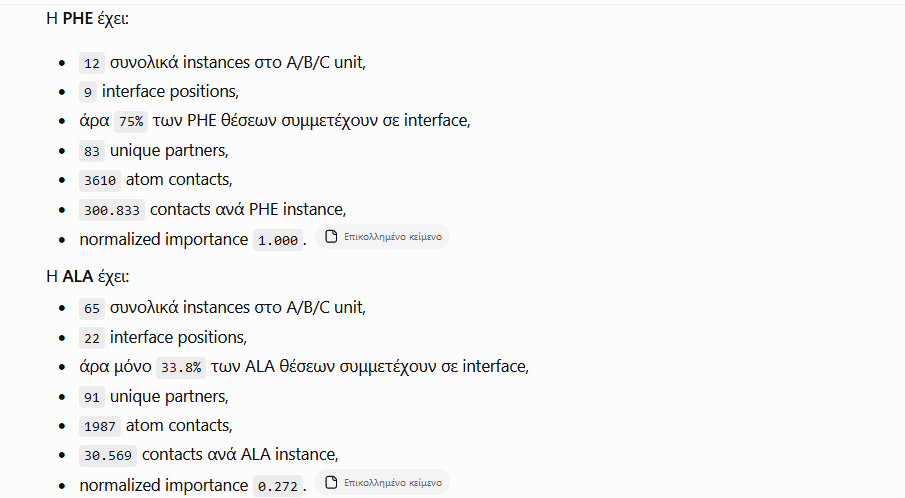

Although alanine contributes a larger number of interface positions overall, phenylalanine shows the highest normalized interface importance. This occurs because phenylalanine is much less abundant in the capsid, yet 75% of its residue positions participate in interfaces and each PHE residue forms a very high number of contacts. In particular, PHE186 from chains A, B and C dominates the residue-level ranking. Therefore, PHE appears to be specifically enriched at protein–protein interfaces, whereas ALA contributes more broadly but less intensively on a per-residue basis.

In [ ]:
# WILD-TYPE SEQUENCE DEFINITION AND POSITION CHECKS

wt_sequence = "MSTVGTGKLTRAQRRAAARKNKRNTRVVQPVIVEPIASGQGKAIKAWTGYSVSKWTASCAAAEAKVTSAITISLPNELSSERNKQLKVGRVLLWLGLLPSVSGTVKSCVTETQTTAAASFQVALAVADNSKDVVAAMYPEAFKGITLEQLAADLTIYLYSSAALTEGDVIVHLEVEHVRPTFDDSFTPVY"
print(len(wt_sequence))
print("Position 37:", wt_sequence[36])
print("Position 186:", wt_sequence[189])

190
Position 37: A
Position 186: Y


In [ ]:
# MUTATION GENERATION AND SEQUENCE CHECKS



a37g_sequence = mutate_sequence(
    wt_sequence,
    position=37,
    expected_residue="A",
    new_residue="G"
)

f186a_sequence = mutate_sequence(
    wt_sequence,
    position=186,
    expected_residue="F",
    new_residue="A"
)


print("WT position 37:", wt_sequence[36])
print("A37G position 37:", a37g_sequence[36])

print("WT position 186:", wt_sequence[185])
print("F186A position 186:", f186a_sequence[185])

print("\nWT sequence:")
print(wt_sequence)

print("\nA37G sequence:")
print(a37g_sequence)

print("\nF186A sequence:")
print(f186a_sequence)

WT position 37: A
A37G position 37: G
WT position 186: F
F186A position 186: A

WT sequence:
MSTVGTGKLTRAQRRAAARKNKRNTRVVQPVIVEPIASGQGKAIKAWTGYSVSKWTASCAAAEAKVTSAITISLPNELSSERNKQLKVGRVLLWLGLLPSVSGTVKSCVTETQTTAAASFQVALAVADNSKDVVAAMYPEAFKGITLEQLAADLTIYLYSSAALTEGDVIVHLEVEHVRPTFDDSFTPVY

A37G sequence:
MSTVGTGKLTRAQRRAAARKNKRNTRVVQPVIVEPIGSGQGKAIKAWTGYSVSKWTASCAAAEAKVTSAITISLPNELSSERNKQLKVGRVLLWLGLLPSVSGTVKSCVTETQTTAAASFQVALAVADNSKDVVAAMYPEAFKGITLEQLAADLTIYLYSSAALTEGDVIVHLEVEHVRPTFDDSFTPVY

F186A sequence:
MSTVGTGKLTRAQRRAAARKNKRNTRVVQPVIVEPIASGQGKAIKAWTGYSVSKWTASCAAAEAKVTSAITISLPNELSSERNKQLKVGRVLLWLGLLPSVSGTVKSCVTETQTTAAASFQVALAVADNSKDVVAAMYPEAFKGITLEQLAADLTIYLYSSAALTEGDVIVHLEVEHVRPTFDDSATPVY


Loaded → /content/outputs/csv_outputs/ASU_protein_protein_summary.csv
Loaded → /content/outputs/csv_outputs/ASU_protein_RNA_summary.csv
Loaded → /content/outputs/csv_outputs/pentamer_protein_protein_summary.csv
Loaded → /content/outputs/csv_outputs/pentamer_protein_RNA_summary.csv
Loaded → /content/outputs/csv_outputs/hexamer_protein_protein_summary.csv
Loaded → /content/outputs/csv_outputs/hexamer_protein_RNA_summary.csv

Saved → /content/outputs/csv_outputs/corrected_overlap_master_all_residues.csv
Saved → /content/outputs/csv_outputs/corrected_overlap_selected_regions.csv

Selected overlap residues by structural region


,residue_label,chain,residue_name,residue_number,overlap_region,in_ASU_any,in_pentamer_any,in_hexamer_any,in_ASU_PP,in_pentamer_PP,in_hexamer_PP,in_ASU_RNA,in_pentamer_RNA,in_hexamer_RNA,present_in_all_three_any,present_in_all_three_PP,present_in_all_three_RNA
0,B:VAL27,B,VAL,27,B/C N-terminal beta-arm region (21-41),False,True,True,False,True,True,False,False,False,False,False,False
1,B:VAL28,B,VAL,28,B/C N-terminal beta-arm region (21-41),False,True,True,False,True,True,False,False,False,False,False,False
2,B:GLN29,B,GLN,29,B/C N-terminal beta-arm region (21-41),False,True,True,False,True,True,False,False,False,False,False,False
3,B:PRO30,B,PRO,30,B/C N-terminal beta-arm region (21-41),False,True,True,False,True,True,False,False,False,False,False,False
4,B:VAL31,B,VAL,31,B/C N-terminal beta-arm region (21-41),False,True,True,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,C:PHE186,C,PHE,186,C-terminal clamp / arm region (175-190),False,False,True,False,False,True,False,False,False,False,False,False
125,C:THR187,C,THR,187,C-terminal clamp / arm region (175-190),True,False,True,True,False,True,False,False,False,False,False,False
126,C:PRO188,C,PRO,188,C-terminal clamp / arm region (175-190),False,False,True,False,False,True,False,False,False,False,False,False
127,C:VAL189,C,VAL,189,C-terminal clamp / arm region (175-190),False,False,True,False,False,True,False,False,False,False,False,False



ASU + pentamer + hexamer overlap by region and chain


,overlap_region,chain,n_overlap_residues,residue_list
0,B/C N-terminal beta-arm region (21-41),A,0,
1,B/C N-terminal beta-arm region (21-41),B,0,
2,B/C N-terminal beta-arm region (21-41),C,0,
3,N-terminal region (42-55),A,1,A:TYR50
4,N-terminal region (42-55),B,1,B:TYR50
5,N-terminal region (42-55),C,0,
6,Ca-associated alphaCDII region (81-85),A,0,
7,Ca-associated alphaCDII region (81-85),B,0,
8,Ca-associated alphaCDII region (81-85),C,0,
9,Ca-associated alphaGH region (140-145),A,1,A:GLU140


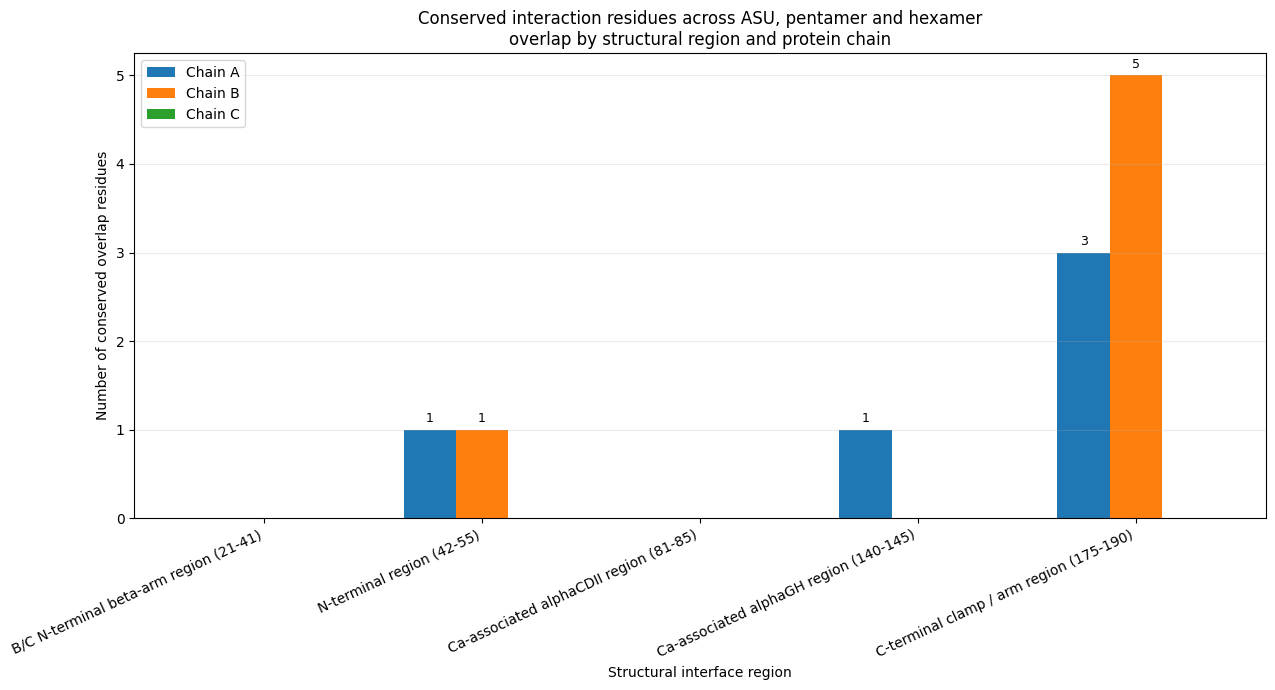

Saved → /content/figures/all_three_overlap_by_region_and_chain.png

Overlap counts by structural region


,overlap_region,Pentamer_vs_ASU_any,Hexamer_vs_ASU_any,ASU_Pentamer_Hexamer_any,Pentamer_vs_ASU_PP,Hexamer_vs_ASU_PP,ASU_Pentamer_Hexamer_PP,Pentamer_vs_ASU_RNA,Hexamer_vs_ASU_RNA,ASU_Pentamer_Hexamer_RNA
0,B/C N-terminal beta-arm region (21-41),0,0,0,0,0,0,0,0,0
1,N-terminal region (42-55),2,2,2,0,0,0,0,0,0
2,Ca-associated alphaCDII region (81-85),0,0,0,0,0,0,0,0,0
3,Ca-associated alphaGH region (140-145),1,1,1,1,1,1,0,0,0
4,C-terminal clamp / arm region (175-190),8,11,8,8,11,8,0,0,0


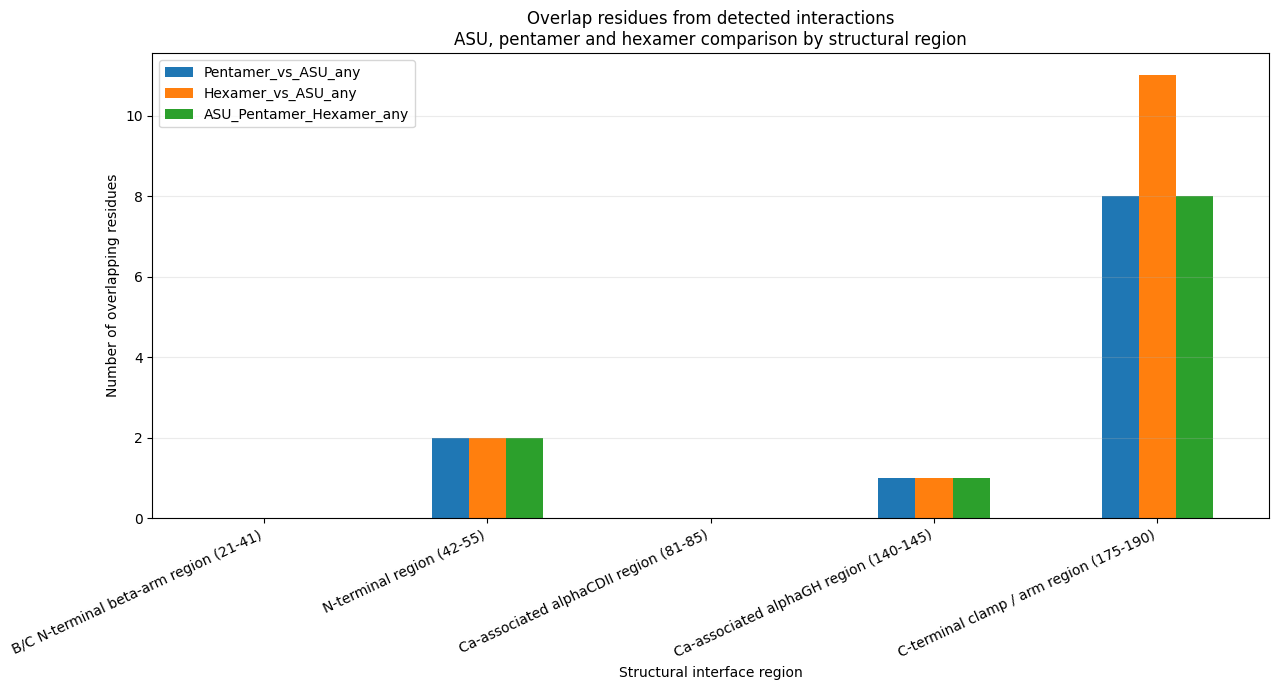

Saved → /content/figures/overlap_comparison_by_region.png


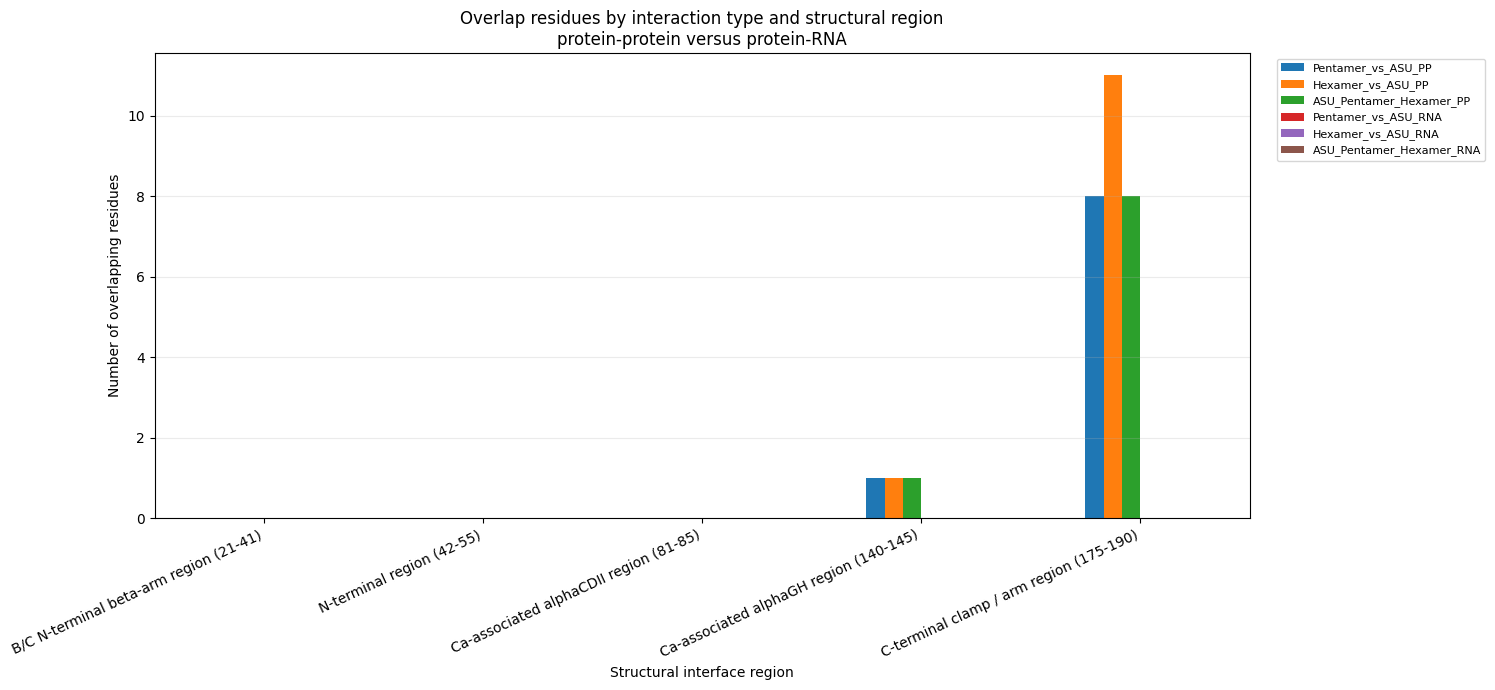

Saved → /content/figures/overlap_PP_vs_RNA_by_region.png

Detailed overlap residues by region and chain


,overlap_region,chain,n_relevant_overlap_residues,all_relevant_residues,all_three_residues,protein_protein_overlap_residues,protein_RNA_overlap_residues
0,B/C N-terminal beta-arm region (21-41),B,0,,,,
1,B/C N-terminal beta-arm region (21-41),C,0,,,,
2,N-terminal region (42-55),A,1,A:TYR50,A:TYR50,,
3,N-terminal region (42-55),B,1,B:TYR50,B:TYR50,,
4,N-terminal region (42-55),C,0,,,,
5,Ca-associated alphaCDII region (81-85),A,0,,,,
6,Ca-associated alphaCDII region (81-85),B,0,,,,
7,Ca-associated alphaCDII region (81-85),C,0,,,,
8,Ca-associated alphaGH region (140-145),A,1,A:GLU140,A:GLU140,A:GLU140,
9,Ca-associated alphaGH region (140-145),B,0,,,,



Duplicate validation
Duplicate residues in master overlap table: 0
Duplicate residues in selected-region table: 0

DONE — overlap analysis by structural region
CSV output folder:
/content/outputs/csv_outputs
Figure output folder:
/content/figures

Main output files:
/content/outputs/csv_outputs/corrected_overlap_master_all_residues.csv
/content/outputs/csv_outputs/corrected_overlap_selected_regions.csv
/content/outputs/csv_outputs/all_three_overlap_by_region_and_chain.csv
/content/outputs/csv_outputs/overlap_counts_by_region.csv
/content/outputs/csv_outputs/detailed_overlap_residues_by_region_and_chain.csv
/content/figures/all_three_overlap_by_region_and_chain.png
/content/figures/overlap_comparison_by_region.png
/content/figures/overlap_PP_vs_RNA_by_region.png


In [ ]:
# STRUCTURAL-REGION AND CHAIN-OVERLAP IMPLEMENTATION

# ============================================================
# CCMV 1CWP
# OVERLAP ANALYSIS BY STRUCTURAL REGION AND PROTEIN CHAIN
#
# Structural regions:
#
#   21-41   -> B/C N-terminal beta-arm region
#              ONLY protein chains B and C
#
#   42-55   -> N-terminal region
#              protein chains A, B and C
#
#   81-85   -> Ca-associated alphaCDII region
#              protein chains A, B and C
#
#   140-145 -> Ca-associated alphaGH region
#              protein chains A, B and C
#
#   175-190 -> C-terminal clamp / arm region
#              protein chains A, B and C
#
# Required CSV files:
#
#   ASU_protein_protein_summary.csv
#   ASU_protein_RNA_summary.csv
#   pentamer_protein_protein_summary.csv
#   pentamer_protein_RNA_summary.csv
#   hexamer_protein_protein_summary.csv
#   hexamer_protein_RNA_summary.csv
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 1. SETTINGS
# ============================================================

# Define separate Google Colab directories for CSV outputs and figures
OUTPUT_DIR = "/content/outputs"
OUT_DIR = os.path.join(OUTPUT_DIR, "csv_outputs")
FIGURES_DIR = "/content/figures"
OVERLAP_DIR = OUT_DIR

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


PROTEIN_CHAINS = [
    "A",
    "B",
    "C"
]


CHAIN_ORDER = [
    "A",
    "B",
    "C"
]


REGION_ORDER = [
    "B/C N-terminal beta-arm region (21-41)",
    "N-terminal region (42-55)",
    "Ca-associated alphaCDII region (81-85)",
    "Ca-associated alphaGH region (140-145)",
    "C-terminal clamp / arm region (175-190)"
]


# ============================================================
# 2. FILE HELPERS
# ============================================================



# ============================================================
# 3. RESIDUE IDENTITY HELPERS
# ============================================================





# ============================================================
# 4. STRUCTURAL REGION CLASSIFICATION
# ============================================================



# ============================================================
# 5. LOAD INTERACTION SUMMARY TABLES
# ============================================================

asu_pp_df = load_csv(
    "ASU_protein_protein_summary.csv"
)

asu_rna_df = load_csv(
    "ASU_protein_RNA_summary.csv"
)


pentamer_pp_df = load_csv(
    "pentamer_protein_protein_summary.csv"
)

pentamer_rna_df = load_csv(
    "pentamer_protein_RNA_summary.csv"
)


hexamer_pp_df = load_csv(
    "hexamer_protein_protein_summary.csv"
)

hexamer_rna_df = load_csv(
    "hexamer_protein_RNA_summary.csv"
)


# ============================================================
# 6. BUILD RESIDUE SETS
# ============================================================

asu_pp_set = get_residue_set(
    asu_pp_df
)

asu_rna_set = get_residue_set(
    asu_rna_df
)

asu_any_set = (
    asu_pp_set
    |
    asu_rna_set
)


pentamer_pp_set = get_residue_set(
    pentamer_pp_df
)

pentamer_rna_set = get_residue_set(
    pentamer_rna_df
)

pentamer_any_set = (
    pentamer_pp_set
    |
    pentamer_rna_set
)


hexamer_pp_set = get_residue_set(
    hexamer_pp_df
)

hexamer_rna_set = get_residue_set(
    hexamer_rna_df
)

hexamer_any_set = (
    hexamer_pp_set
    |
    hexamer_rna_set
)


all_residue_identities = sorted(
    asu_any_set
    |
    pentamer_any_set
    |
    hexamer_any_set
)


# ============================================================
# 7. BUILD OVERLAP MASTER TABLE
# ============================================================

overlap_rows = []


for residue_identity in all_residue_identities:

    overlap_rows.append({

        "residue_identity":
            residue_identity,


        # ----------------------------------------------------
        # Presence in each context: any interaction
        # ----------------------------------------------------

        "in_ASU_any":
            residue_identity
            in asu_any_set,

        "in_pentamer_any":
            residue_identity
            in pentamer_any_set,

        "in_hexamer_any":
            residue_identity
            in hexamer_any_set,


        # ----------------------------------------------------
        # Presence in each context: protein-protein
        # ----------------------------------------------------

        "in_ASU_PP":
            residue_identity
            in asu_pp_set,

        "in_pentamer_PP":
            residue_identity
            in pentamer_pp_set,

        "in_hexamer_PP":
            residue_identity
            in hexamer_pp_set,


        # ----------------------------------------------------
        # Presence in each context: protein-RNA
        # ----------------------------------------------------

        "in_ASU_RNA":
            residue_identity
            in asu_rna_set,

        "in_pentamer_RNA":
            residue_identity
            in pentamer_rna_set,

        "in_hexamer_RNA":
            residue_identity
            in hexamer_rna_set,


        # ----------------------------------------------------
        # Pentamer vs ASU overlap
        # ----------------------------------------------------

        "overlap_pentamer_vs_ASU_any":
            (
                residue_identity
                in pentamer_any_set
                and
                residue_identity
                in asu_any_set
            ),

        "overlap_pentamer_vs_ASU_PP":
            (
                residue_identity
                in pentamer_pp_set
                and
                residue_identity
                in asu_pp_set
            ),

        "overlap_pentamer_vs_ASU_RNA":
            (
                residue_identity
                in pentamer_rna_set
                and
                residue_identity
                in asu_rna_set
            ),


        # ----------------------------------------------------
        # Hexamer vs ASU overlap
        # ----------------------------------------------------

        "overlap_hexamer_vs_ASU_any":
            (
                residue_identity
                in hexamer_any_set
                and
                residue_identity
                in asu_any_set
            ),

        "overlap_hexamer_vs_ASU_PP":
            (
                residue_identity
                in hexamer_pp_set
                and
                residue_identity
                in asu_pp_set
            ),

        "overlap_hexamer_vs_ASU_RNA":
            (
                residue_identity
                in hexamer_rna_set
                and
                residue_identity
                in asu_rna_set
            ),


        # ----------------------------------------------------
        # Present in all three contexts
        # ----------------------------------------------------

        "present_in_all_three_any":
            (
                residue_identity
                in asu_any_set
                and
                residue_identity
                in pentamer_any_set
                and
                residue_identity
                in hexamer_any_set
            ),

        "present_in_all_three_PP":
            (
                residue_identity
                in asu_pp_set
                and
                residue_identity
                in pentamer_pp_set
                and
                residue_identity
                in hexamer_pp_set
            ),

        "present_in_all_three_RNA":
            (
                residue_identity
                in asu_rna_set
                and
                residue_identity
                in pentamer_rna_set
                and
                residue_identity
                in hexamer_rna_set
            )
    })


overlap_master_df = pd.DataFrame(
    overlap_rows
)


# ============================================================
# 8. PARSE RESIDUE IDENTITIES
# ============================================================

parsed_residue_df = (
    overlap_master_df[
        "residue_identity"
    ]
    .apply(
        parse_identity
    )
)


overlap_master_df = pd.concat(
    [
        overlap_master_df.reset_index(
            drop=True
        ),

        parsed_residue_df.reset_index(
            drop=True
        )
    ],
    axis=1
)


# Number of contexts in which each residue appears.
overlap_master_df[
    "n_contexts_any"
] = overlap_master_df[
    [
        "in_ASU_any",
        "in_pentamer_any",
        "in_hexamer_any"
    ]
].sum(
    axis=1
)


overlap_master_df[
    "n_contexts_PP"
] = overlap_master_df[
    [
        "in_ASU_PP",
        "in_pentamer_PP",
        "in_hexamer_PP"
    ]
].sum(
    axis=1
)


overlap_master_df[
    "n_contexts_RNA"
] = overlap_master_df[
    [
        "in_ASU_RNA",
        "in_pentamer_RNA",
        "in_hexamer_RNA"
    ]
].sum(
    axis=1
)


# ============================================================
# 9. ASSIGN STRUCTURAL REGIONS
# ============================================================

overlap_master_df[
    "overlap_region"
] = overlap_master_df.apply(
    lambda row: classify_overlap_region(
        row[
            "residue_number"
        ],
        row[
            "chain"
        ]
    ),
    axis=1
)


# Keep protein residues from chains A/B/C only.
protein_overlap_master_df = (
    overlap_master_df[
        (
            overlap_master_df[
                "molecule_type"
            ].astype(str)
            ==
            "protein"
        )
        &
        (
            overlap_master_df[
                "chain"
            ].astype(str)
            .isin(
                PROTEIN_CHAINS
            )
        )
    ]
    .copy()
)


# Remove chain A residues from positions 21-41.
protein_overlap_master_df = (
    protein_overlap_master_df[
        protein_overlap_master_df[
            "overlap_region"
        ]
        !=
        "excluded: chain A in residues 21-41"
    ]
    .copy()
)


protein_overlap_master_df[
    "residue_label"
] = protein_overlap_master_df.apply(
    lambda row: (
        f"{row['chain']}:"
        f"{row['residue_name']}"
        f"{int(row['residue_number'])}"
    ),
    axis=1
)


# Keep only the selected structural regions.
selected_region_overlap_df = (
    protein_overlap_master_df[
        protein_overlap_master_df[
            "overlap_region"
        ].isin(
            REGION_ORDER
        )
    ]
    .copy()
)


# Preserve the intended biological region order.
region_rank_map = {
    region: rank
    for rank, region in enumerate(
        REGION_ORDER
    )
}


selected_region_overlap_df[
    "region_rank"
] = selected_region_overlap_df[
    "overlap_region"
].map(
    region_rank_map
)


selected_region_overlap_df = (
    selected_region_overlap_df

    .sort_values(
        [
            "region_rank",
            "chain",
            "residue_number"
        ]
    )

    .drop(
        columns=[
            "region_rank"
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 10. SAVE MASTER TABLES
# ============================================================

master_output_path = os.path.join(
    OVERLAP_DIR,
    "corrected_overlap_master_all_residues.csv"
)


selected_output_path = os.path.join(
    OVERLAP_DIR,
    "corrected_overlap_selected_regions.csv"
)


overlap_master_df.to_csv(
    master_output_path,
    index=False
)


selected_region_overlap_df.to_csv(
    selected_output_path,
    index=False
)


print(
    f"\nSaved → {master_output_path}"
)

print(
    f"Saved → {selected_output_path}"
)


# ============================================================
# 11. DISPLAY SELECTED RESIDUES
# ============================================================

display_columns = [
    "residue_label",
    "chain",
    "residue_name",
    "residue_number",
    "overlap_region",

    "in_ASU_any",
    "in_pentamer_any",
    "in_hexamer_any",

    "in_ASU_PP",
    "in_pentamer_PP",
    "in_hexamer_PP",

    "in_ASU_RNA",
    "in_pentamer_RNA",
    "in_hexamer_RNA",

    "present_in_all_three_any",
    "present_in_all_three_PP",
    "present_in_all_three_RNA"
]


print(
    "\nSelected overlap residues by structural region"
)

print(
    "=" * 48
)


display(
    selected_region_overlap_df[
        display_columns
    ]
)


# ============================================================
# 12. ALL-THREE OVERLAP BY REGION AND CHAIN
# ============================================================

all_three_any_df = (
    selected_region_overlap_df[
        selected_region_overlap_df[
            "present_in_all_three_any"
        ]
        ==
        True
    ]
    .copy()
)


region_chain_all_three_df = (
    all_three_any_df

    .groupby(
        [
            "overlap_region",
            "chain"
        ]
    )

    .agg(
        n_overlap_residues=(
            "residue_identity",
            "nunique"
        ),

        residue_list=(
            "residue_label",

            lambda values: ", ".join(
                sorted(
                    set(
                        values.astype(str)
                    )
                )
            )
        )
    )

    .reset_index()
)


# Build every possible region-chain combination.
complete_region_chain_index = (
    pd.MultiIndex.from_product(
        [
            REGION_ORDER,
            CHAIN_ORDER
        ],
        names=[
            "overlap_region",
            "chain"
        ]
    )
)


region_chain_all_three_df = (
    region_chain_all_three_df

    .set_index(
        [
            "overlap_region",
            "chain"
        ]
    )

    .reindex(
        complete_region_chain_index
    )

    .reset_index()
)


region_chain_all_three_df[
    "n_overlap_residues"
] = (
    region_chain_all_three_df[
        "n_overlap_residues"
    ]
    .fillna(0)
    .astype(int)
)


region_chain_all_three_df[
    "residue_list"
] = (
    region_chain_all_three_df[
        "residue_list"
    ]
    .fillna("")
)


# Chain A must remain zero for the 21-41 B/C-specific region.
chain_a_beta_arm_mask = (
    (
        region_chain_all_three_df[
            "overlap_region"
        ]
        ==
        "B/C N-terminal beta-arm region (21-41)"
    )
    &
    (
        region_chain_all_three_df[
            "chain"
        ]
        ==
        "A"
    )
)


region_chain_all_three_df.loc[
    chain_a_beta_arm_mask,
    "n_overlap_residues"
] = 0


region_chain_all_three_df.loc[
    chain_a_beta_arm_mask,
    "residue_list"
] = ""


region_chain_all_three_path = os.path.join(
    OVERLAP_DIR,
    "all_three_overlap_by_region_and_chain.csv"
)


region_chain_all_three_df.to_csv(
    region_chain_all_three_path,
    index=False
)


print(
    "\nASU + pentamer + hexamer overlap by region and chain"
)

print(
    "=" * 57
)


display(
    region_chain_all_three_df
)


# ============================================================
# 13. PLOT 1
# ALL-THREE OVERLAP BY REGION AND CHAIN
# ============================================================

region_chain_pivot_df = (
    region_chain_all_three_df

    .pivot(
        index="overlap_region",
        columns="chain",
        values="n_overlap_residues"
    )

    .fillna(0)

    .reindex(
        REGION_ORDER
    )

    .reindex(
        columns=CHAIN_ORDER,
        fill_value=0
    )
)


figure, axis = plt.subplots(
    figsize=(
        13,
        7
    )
)


x_positions = np.arange(
    len(
        REGION_ORDER
    )
)


bar_width = 0.24


axis.bar(
    x_positions - bar_width,
    region_chain_pivot_df["A"].values,
    width=bar_width,
    label="Chain A"
)


axis.bar(
    x_positions,
    region_chain_pivot_df["B"].values,
    width=bar_width,
    label="Chain B"
)


axis.bar(
    x_positions + bar_width,
    region_chain_pivot_df["C"].values,
    width=bar_width,
    label="Chain C"
)


# Add values above bars.
for offset, chain in zip(
    [
        -bar_width,
        0,
        bar_width
    ],
    CHAIN_ORDER
):

    values = region_chain_pivot_df[
        chain
    ].values

    for position_index, value in enumerate(
        values
    ):

        if value <= 0:
            continue

        axis.text(
            x_positions[
                position_index
            ] + offset,

            value + 0.05,

            str(
                int(value)
            ),

            ha="center",
            va="bottom",
            fontsize=9
        )


axis.set_xticks(
    x_positions
)


axis.set_xticklabels(
    REGION_ORDER,
    rotation=25,
    ha="right"
)


axis.set_ylabel(
    "Number of conserved overlap residues"
)


axis.set_xlabel(
    "Structural interface region"
)


axis.set_title(
    "Conserved interaction residues across ASU, pentamer and hexamer\n"
    "overlap by structural region and protein chain"
)


axis.legend()


axis.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


plot_all_three_chain_path = os.path.join(
    FIGURES_DIR,
    "all_three_overlap_by_region_and_chain.png"
)


plt.savefig(
    plot_all_three_chain_path,
    dpi=220,
    bbox_inches="tight"
)


plt.show()


print(
    f"Saved → {plot_all_three_chain_path}"
)


# ============================================================
# 14. OVERLAP COUNTS BY REGION
# ============================================================

region_overlap_rows = []


for region in REGION_ORDER:

    region_df = (
        selected_region_overlap_df[
            selected_region_overlap_df[
                "overlap_region"
            ]
            ==
            region
        ]
        .copy()
    )


    region_overlap_rows.append({

        "overlap_region":
            region,


        # Any interaction
        "Pentamer_vs_ASU_any":
            region_df.loc[
                region_df[
                    "overlap_pentamer_vs_ASU_any"
                ],
                "residue_identity"
            ].nunique(),

        "Hexamer_vs_ASU_any":
            region_df.loc[
                region_df[
                    "overlap_hexamer_vs_ASU_any"
                ],
                "residue_identity"
            ].nunique(),

        "ASU_Pentamer_Hexamer_any":
            region_df.loc[
                region_df[
                    "present_in_all_three_any"
                ],
                "residue_identity"
            ].nunique(),


        # Protein-protein
        "Pentamer_vs_ASU_PP":
            region_df.loc[
                region_df[
                    "overlap_pentamer_vs_ASU_PP"
                ],
                "residue_identity"
            ].nunique(),

        "Hexamer_vs_ASU_PP":
            region_df.loc[
                region_df[
                    "overlap_hexamer_vs_ASU_PP"
                ],
                "residue_identity"
            ].nunique(),

        "ASU_Pentamer_Hexamer_PP":
            region_df.loc[
                region_df[
                    "present_in_all_three_PP"
                ],
                "residue_identity"
            ].nunique(),


        # Protein-RNA
        "Pentamer_vs_ASU_RNA":
            region_df.loc[
                region_df[
                    "overlap_pentamer_vs_ASU_RNA"
                ],
                "residue_identity"
            ].nunique(),

        "Hexamer_vs_ASU_RNA":
            region_df.loc[
                region_df[
                    "overlap_hexamer_vs_ASU_RNA"
                ],
                "residue_identity"
            ].nunique(),

        "ASU_Pentamer_Hexamer_RNA":
            region_df.loc[
                region_df[
                    "present_in_all_three_RNA"
                ],
                "residue_identity"
            ].nunique()
    })


region_overlap_summary_df = pd.DataFrame(
    region_overlap_rows
)


region_overlap_summary_path = os.path.join(
    OVERLAP_DIR,
    "overlap_counts_by_region.csv"
)


region_overlap_summary_df.to_csv(
    region_overlap_summary_path,
    index=False
)


print(
    "\nOverlap counts by structural region"
)

print(
    "=" * 38
)


display(
    region_overlap_summary_df
)


# ============================================================
# 15. PLOT 2
# MAIN OVERLAP COMPARISON BY REGION
# ============================================================

main_plot_df = (
    region_overlap_summary_df[
        [
            "overlap_region",
            "Pentamer_vs_ASU_any",
            "Hexamer_vs_ASU_any",
            "ASU_Pentamer_Hexamer_any"
        ]
    ]

    .set_index(
        "overlap_region"
    )

    .reindex(
        REGION_ORDER
    )
)


axis = main_plot_df.plot(
    kind="bar",
    figsize=(
        13,
        7
    )
)


axis.set_title(
    "Overlap residues from detected interactions\n"
    "ASU, pentamer and hexamer comparison by structural region"
)


axis.set_ylabel(
    "Number of overlapping residues"
)


axis.set_xlabel(
    "Structural interface region"
)


axis.grid(
    axis="y",
    alpha=0.25
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.tight_layout()


main_overlap_plot_path = os.path.join(
    FIGURES_DIR,
    "overlap_comparison_by_region.png"
)


plt.savefig(
    main_overlap_plot_path,
    dpi=220,
    bbox_inches="tight"
)


plt.show()


print(
    f"Saved → {main_overlap_plot_path}"
)


# ============================================================
# 16. PLOT 3
# PROTEIN-PROTEIN VS PROTEIN-RNA
# ============================================================

interaction_plot_df = (
    region_overlap_summary_df[
        [
            "overlap_region",

            "Pentamer_vs_ASU_PP",
            "Hexamer_vs_ASU_PP",
            "ASU_Pentamer_Hexamer_PP",

            "Pentamer_vs_ASU_RNA",
            "Hexamer_vs_ASU_RNA",
            "ASU_Pentamer_Hexamer_RNA"
        ]
    ]

    .set_index(
        "overlap_region"
    )

    .reindex(
        REGION_ORDER
    )
)


axis = interaction_plot_df.plot(
    kind="bar",
    figsize=(
        15,
        7
    )
)


axis.set_title(
    "Overlap residues by interaction type and structural region\n"
    "protein-protein versus protein-RNA"
)


axis.set_ylabel(
    "Number of overlapping residues"
)


axis.set_xlabel(
    "Structural interface region"
)


axis.grid(
    axis="y",
    alpha=0.25
)


axis.legend(
    fontsize=8,
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.tight_layout()


interaction_type_plot_path = os.path.join(
    FIGURES_DIR,
    "overlap_PP_vs_RNA_by_region.png"
)


plt.savefig(
    interaction_type_plot_path,
    dpi=220,
    bbox_inches="tight"
)


plt.show()


print(
    f"Saved → {interaction_type_plot_path}"
)


# ============================================================
# 17. DETAILED RESIDUE LISTS BY REGION AND CHAIN
# ============================================================

detailed_region_chain_rows = []


for region in REGION_ORDER:

    for chain in CHAIN_ORDER:

        # Do not include chain A for residues 21-41.
        if (
            region
            ==
            "B/C N-terminal beta-arm region (21-41)"
            and
            chain
            ==
            "A"
        ):
            continue


        region_chain_df = (
            selected_region_overlap_df[
                (
                    selected_region_overlap_df[
                        "overlap_region"
                    ]
                    ==
                    region
                )
                &
                (
                    selected_region_overlap_df[
                        "chain"
                    ]
                    ==
                    chain
                )
            ]
            .copy()
        )


        useful_df = (
            region_chain_df[
                (
                    region_chain_df[
                        "overlap_pentamer_vs_ASU_any"
                    ]
                )
                |
                (
                    region_chain_df[
                        "overlap_hexamer_vs_ASU_any"
                    ]
                )
                |
                (
                    region_chain_df[
                        "present_in_all_three_any"
                    ]
                )
            ]
            .copy()
        )


        detailed_region_chain_rows.append({

            "overlap_region":
                region,

            "chain":
                chain,

            "n_relevant_overlap_residues":
                useful_df[
                    "residue_identity"
                ].nunique(),

            "all_relevant_residues":
                ", ".join(
                    sorted(
                        set(
                            useful_df[
                                "residue_label"
                            ].astype(str)
                        )
                    )
                ),

            "all_three_residues":
                ", ".join(
                    sorted(
                        set(
                            useful_df.loc[
                                useful_df[
                                    "present_in_all_three_any"
                                ],
                                "residue_label"
                            ].astype(str)
                        )
                    )
                ),

            "protein_protein_overlap_residues":
                ", ".join(
                    sorted(
                        set(
                            useful_df.loc[
                                (
                                    useful_df[
                                        "overlap_pentamer_vs_ASU_PP"
                                    ]
                                )
                                |
                                (
                                    useful_df[
                                        "overlap_hexamer_vs_ASU_PP"
                                    ]
                                ),
                                "residue_label"
                            ].astype(str)
                        )
                    )
                ),

            "protein_RNA_overlap_residues":
                ", ".join(
                    sorted(
                        set(
                            useful_df.loc[
                                (
                                    useful_df[
                                        "overlap_pentamer_vs_ASU_RNA"
                                    ]
                                )
                                |
                                (
                                    useful_df[
                                        "overlap_hexamer_vs_ASU_RNA"
                                    ]
                                ),
                                "residue_label"
                            ].astype(str)
                        )
                    )
                )
        })


detailed_region_chain_df = pd.DataFrame(
    detailed_region_chain_rows
)


detailed_region_chain_path = os.path.join(
    OVERLAP_DIR,
    "detailed_overlap_residues_by_region_and_chain.csv"
)


detailed_region_chain_df.to_csv(
    detailed_region_chain_path,
    index=False
)


print(
    "\nDetailed overlap residues by region and chain"
)

print(
    "=" * 47
)


display(
    detailed_region_chain_df
)


# ============================================================
# 18. DUPLICATE VALIDATION
# ============================================================

master_duplicate_count = int(
    overlap_master_df.duplicated(
        subset=[
            "residue_identity"
        ],
        keep=False
    ).sum()
)


selected_duplicate_count = int(
    selected_region_overlap_df.duplicated(
        subset=[
            "residue_identity"
        ],
        keep=False
    ).sum()
)


print(
    "\nDuplicate validation"
)

print(
    "=" * 20
)


print(
    "Duplicate residues in master overlap table: "
    f"{master_duplicate_count}"
)


print(
    "Duplicate residues in selected-region table: "
    f"{selected_duplicate_count}"
)


# ============================================================
# 19. FINAL OUTPUT SUMMARY
# ============================================================

print(
    "\nDONE — overlap analysis by structural region"
)

print(
    "=" * 47
)


print(
    f"CSV output folder:\n{OUT_DIR}"
)

print(
    f"Figure output folder:\n{FIGURES_DIR}"
)


print(
    "\nMain output files:"
)


print(
    master_output_path
)

print(
    selected_output_path
)

print(
    region_chain_all_three_path
)

print(
    region_overlap_summary_path
)

print(
    detailed_region_chain_path
)

print(
    plot_all_three_chain_path
)

print(
    main_overlap_plot_path
)

print(
    interaction_type_plot_path
)

Two residues, A:TYR50 and B:TYR50, were conserved across ASU, pentamer and hexamer when all interaction types were considered together. However, they did not retain the same interaction type across contexts. In the ASU they participated in protein–RNA contacts, whereas in the pentamer and hexamer they participated in protein–protein contacts. This suggests a context-dependent change in interaction role rather than conservation of one specific interaction type.

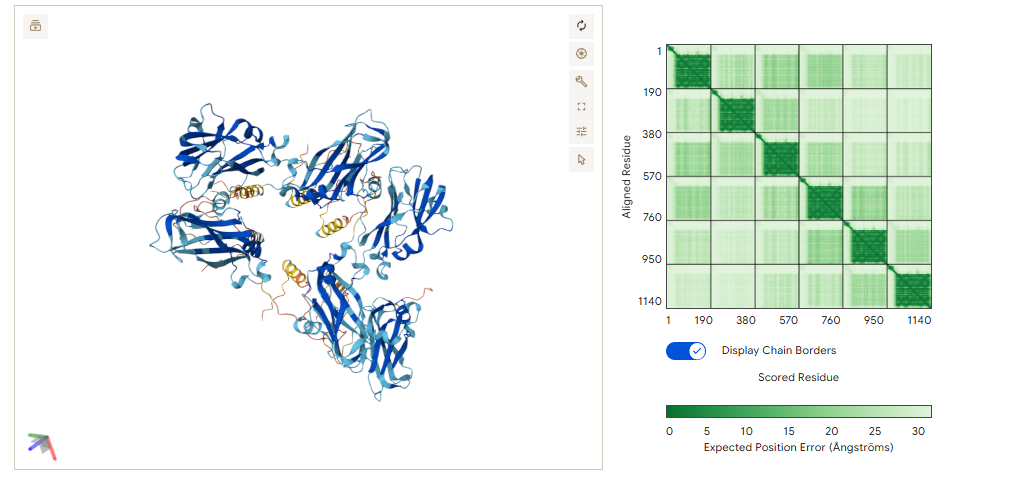

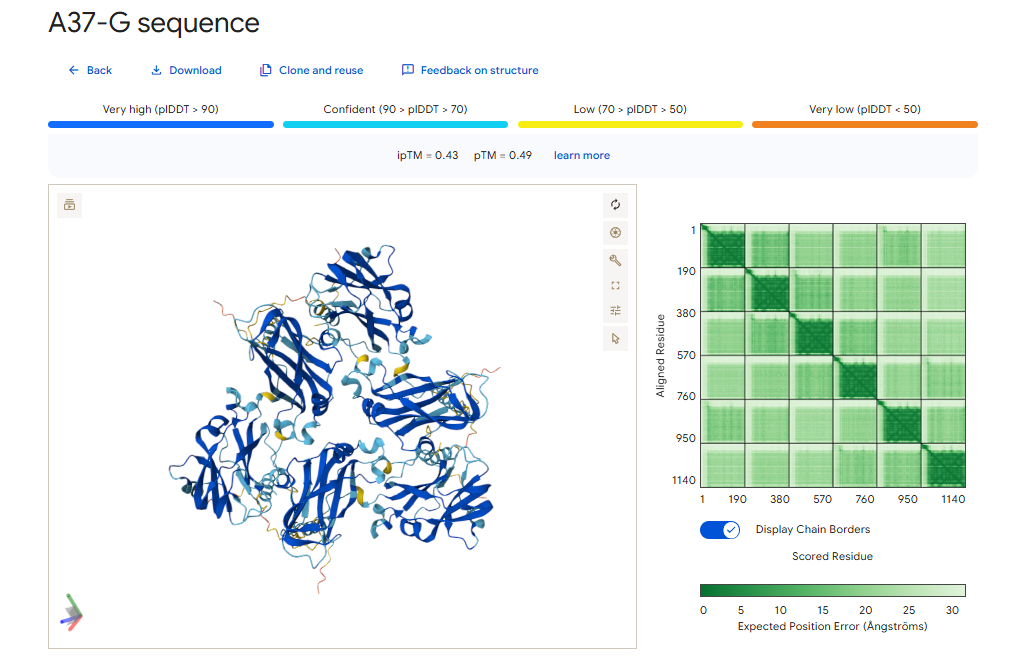

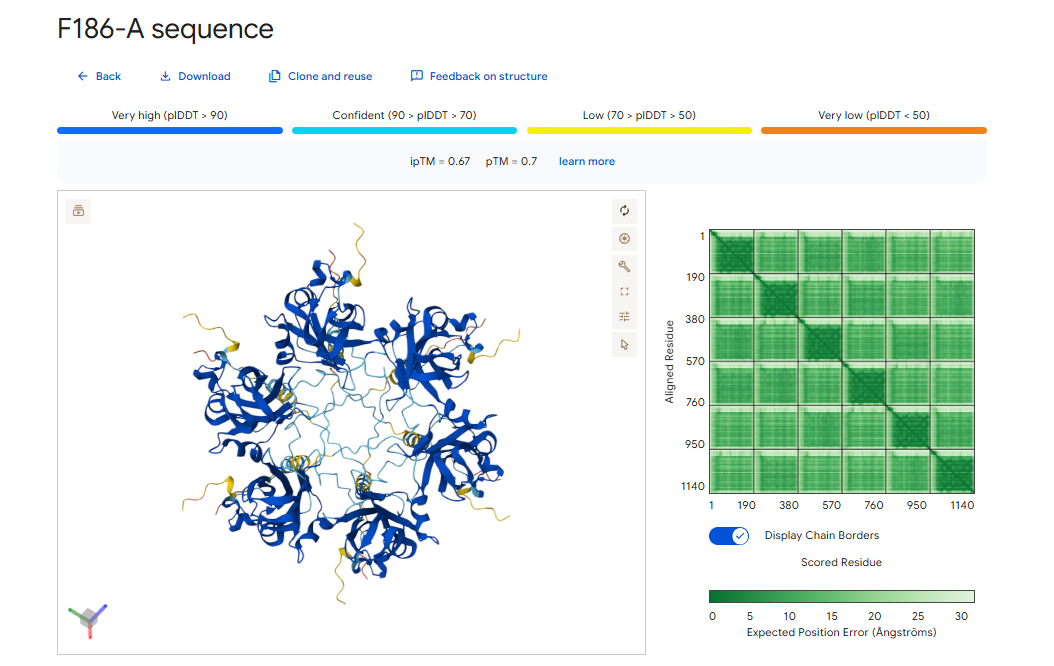


Automatically derived key interface residues
['A:ASP184', 'A:GLN121', 'A:PHE186', 'A:TYR190', 'A:VAL189', 'B:ASP184', 'B:GLN121', 'B:GLU34', 'B:GLY39', 'B:ILE36', 'B:PHE186', 'B:SER185', 'B:SER38', 'B:VAL31', 'C:GLN121', 'C:GLU34', 'C:PHE186', 'C:SER38', 'C:TYR190', 'C:VAL189']

Interface-instance features


,context,interface_instance,copy_1,copy_2,chain_1,chain_2,chain_pair,n_unique_residue_pairs,n_unique_interface_residues,total_atom_contacts,contact_density,projected_area_A2,centroid_distance_A,normal_radial_angle_deg,plane_variance_fraction,n_key_residues,key_residue_fraction,minimum_contact_distance_A
0,pentamer,"('pentamer', (0, 1), ('A', 'A'))",0,1,A,A,A-A,35,34,291.0,8.314,461.029,29.213,78.626,0.807,1,0.033,2.427
1,pentamer,"('pentamer', (0, 1), ('A', 'B'))",0,1,A,B,A-B,94,69,809.0,8.606,934.651,65.045,75.377,0.936,10,0.145,2.616
2,pentamer,"('pentamer', (0, 1), ('B', 'C'))",0,1,B,C,B-C,71,56,516.0,7.268,892.763,28.154,27.201,0.928,7,0.125,2.703
3,pentamer,"('pentamer', (0, 4), ('A', 'A'))",0,4,A,A,A-A,35,34,293.0,8.371,460.881,29.194,78.668,0.807,1,0.033,2.426
4,pentamer,"('pentamer', (0, 4), ('A', 'B'))",0,4,A,B,A-B,94,69,809.0,8.606,934.357,30.769,75.388,0.936,10,0.145,2.615
5,pentamer,"('pentamer', (0, 4), ('B', 'C'))",0,4,B,C,B-C,71,56,516.0,7.268,891.903,89.348,27.122,0.928,7,0.125,2.705
6,pentamer,"('pentamer', (1, 2), ('A', 'A'))",1,2,A,A,A-A,35,34,292.0,8.343,461.186,29.193,78.637,0.807,1,0.033,2.425
7,pentamer,"('pentamer', (1, 2), ('A', 'B'))",1,2,A,B,A-B,94,69,811.0,8.628,934.672,64.996,75.405,0.936,10,0.145,2.614
8,pentamer,"('pentamer', (1, 2), ('B', 'C'))",1,2,B,C,B-C,71,56,516.0,7.268,892.214,28.133,27.215,0.928,7,0.125,2.704
9,pentamer,"('pentamer', (2, 3), ('A', 'A'))",2,3,A,A,A-A,35,34,291.0,8.314,460.711,29.206,78.628,0.807,1,0.033,2.426


,context,n_interface_instances,contact_density_mean,contact_density_median,contact_density_q25,contact_density_q75,projected_area_A2_mean,projected_area_A2_median,projected_area_A2_q25,projected_area_A2_q75,...,normal_radial_angle_deg_q25,normal_radial_angle_deg_q75,plane_variance_fraction_mean,plane_variance_fraction_median,plane_variance_fraction_q25,plane_variance_fraction_q75,key_residue_fraction_mean,key_residue_fraction_median,key_residue_fraction_q25,key_residue_fraction_q75
0,hexamer,30,5.468,6.071,2.000,8.336,738.726,307.025,60.521,934.618,...,77.137,84.660,0.941,0.953,0.936,0.967,0.192,0.135,0.109,0.250
1,pentamer,15,8.071,8.314,7.268,8.606,762.647,892.484,461.201,934.333,...,27.208,78.614,0.890,0.928,0.807,0.936,0.101,0.125,0.033,0.145



Capsid radar profiles before normalization


,profile,contact_density,projected_area_A2,centroid_distance_A,normal_radial_angle_deg,plane_variance_fraction,key_residue_fraction
0,Pentamer median,8.314,892.484,29.206,75.397,0.928,0.125
1,Hexamer median,6.071,307.025,48.381,81.010,0.953,0.135
2,Capsid-weighted profile,6.912,526.572,41.190,78.905,0.944,0.131


/tmp/ipykernel_7635/2327302.py:533: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
/tmp/ipykernel_7635/2327302.py:533: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
/tmp/ipykernel_7635/2327302.py:533: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
/tmp/ipykernel_7635/2327302.py:533: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
/tmp/ipykernel_7635/2327302.py:533: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

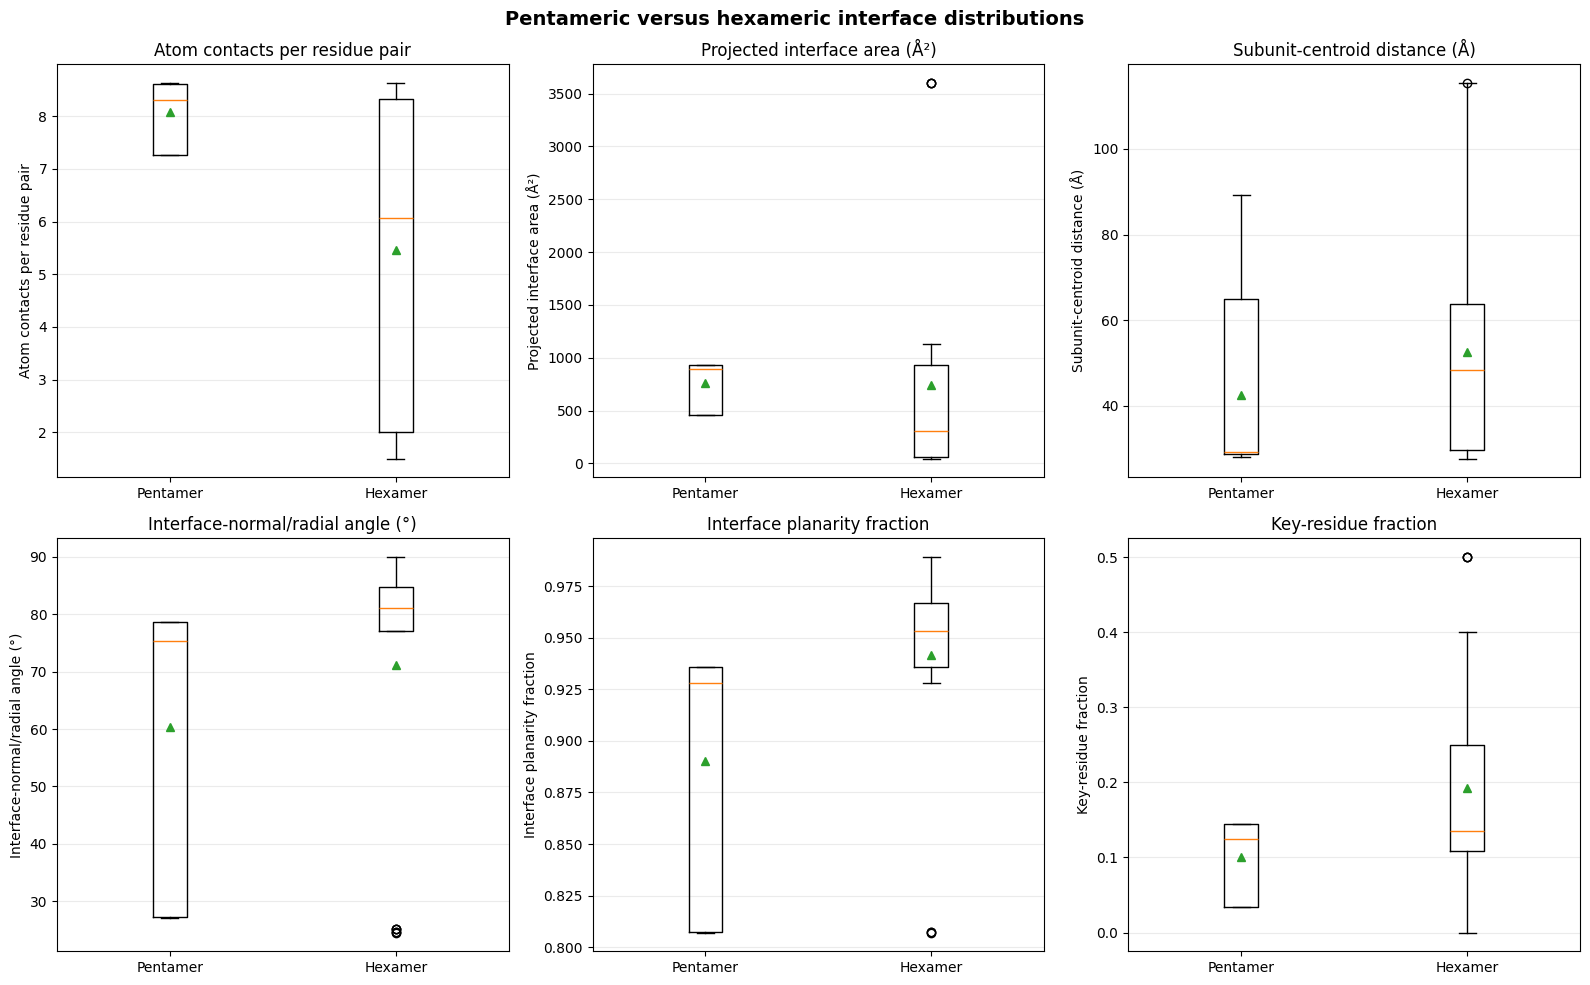

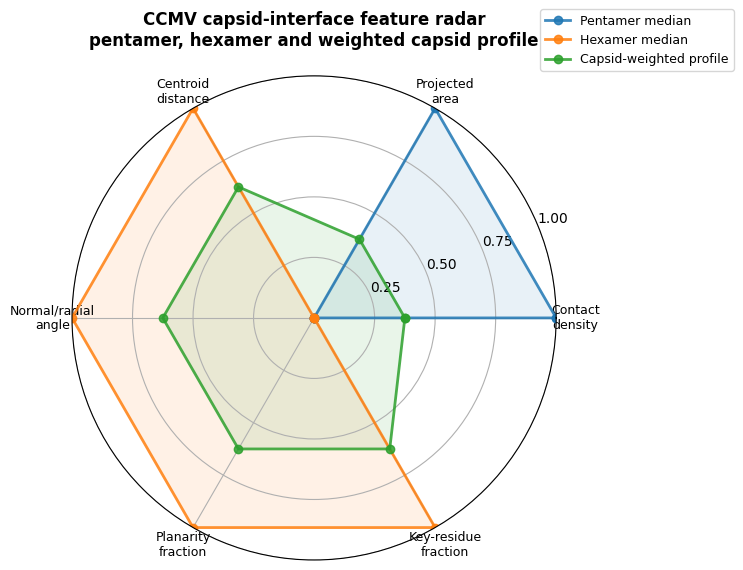


DONE — capsid-wide interface distribution analysis
CSV output folder:
/content/outputs/csv_outputs
Figure output folder:
/content/figures

Saved → /content/outputs/csv_outputs/interface_instance_features.csv
Saved → /content/outputs/csv_outputs/interface_context_summary.csv
Saved → /content/outputs/csv_outputs/capsid_radar_profile.csv
Saved → /content/outputs/csv_outputs/capsid_radar_profile_normalized.csv
Saved → /content/figures/interface_feature_distributions.png
Saved → /content/figures/interface_feature_radar.png


In [ ]:
# PENTAMER/HEXAMER INTERFACE-DISTRIBUTION AND RADAR-PROFILE IMPLEMENTATION

# ============================================================
# CCMV 1CWP
# PENTAMER / HEXAMER INTERFACE DISTRIBUTIONS
# AND CAPSIDE-WIDE WEIGHTED RADAR PROFILE
#
# Required existing variables:
#
#   pentamer_atoms_df
#   hexamer_atoms_df
#   pentamer_residue_pairs_df
#   hexamer_residue_pairs_df
#
# Main outputs:
#
#   interface_instance_features.csv
#   interface_context_summary.csv
#   interface_feature_distributions.png
#   interface_feature_radar.png
#   projected_interface_area_distribution.png
#
# The analysis is performed per physical interface instance:
#
#   symmetry-copy pair
#   +
#   biological chain pair
#
# It does not merge the whole pentamer or hexamer into one
# artificial interface.
# ============================================================

from scipy.linalg import svd
from scipy.spatial import ConvexHull
from IPython.display import display


# ============================================================
# 1. VALIDATION
# ============================================================

required_variables = [
    "pentamer_atoms_df",
    "hexamer_atoms_df",
    "pentamer_residue_pairs_df",
    "hexamer_residue_pairs_df"
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the main interaction pipeline first. "
        "Missing variables: "
        + ", ".join(missing_variables)
    )


# ============================================================
# 2. SETTINGS
# ============================================================

if "OUT_DIR" not in globals():
    OUTPUT_DIR = "/content/outputs"
    OUT_DIR = os.path.join(OUTPUT_DIR, "csv_outputs")

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = "/content/figures"

CAPSID_INTERFACE_DIR = OUT_DIR

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


PROTEIN_CHAINS = [
    "A",
    "B",
    "C"
]


# T=3 capsid weighting.
# These values are configurable.
PENTAMER_CONTEXT_WEIGHT = 12
HEXAMER_CONTEXT_WEIGHT = 20


# Residues with high interface importance are treated as key.
KEY_RESIDUE_QUANTILE = 0.90


# ============================================================
# 3. BASIC HELPERS
# ============================================================











# ============================================================
# 4. PREPARE C-alpha LOOKUP
# ============================================================



# ============================================================
# 5. PREPARE RESIDUE PAIRS
# ============================================================



# ============================================================
# 6. DERIVE KEY RESIDUES FROM CONTACT NETWORK
# ============================================================



# ============================================================
# 7. PCA AND GEOMETRIC HELPERS
# ============================================================







# ============================================================
# 8. CHAIN CENTROID LOOKUP
# ============================================================



# ============================================================
# 9. ANALYSE PHYSICAL INTERFACE INSTANCES
# ============================================================



# ============================================================
# 10. BUILD KEY-RESIDUE SET
# ============================================================

pentamer_pairs_prepared_for_keys = (
    prepare_interface_pairs(
        pentamer_residue_pairs_df,
        "pentamer"
    )
)

hexamer_pairs_prepared_for_keys = (
    prepare_interface_pairs(
        hexamer_residue_pairs_df,
        "hexamer"
    )
)


key_residue_set, key_residue_importance_df = (
    derive_key_residue_set(
        pentamer_pairs_prepared_for_keys,
        hexamer_pairs_prepared_for_keys,
        quantile=KEY_RESIDUE_QUANTILE
    )
)


print(
    "\nAutomatically derived key interface residues"
)

print(
    "=" * 44
)

print(
    sorted(
        key_residue_set
    )
)


# ============================================================
# 11. CALCULATE INTERFACE INSTANCE FEATURES
# ============================================================

pentamer_instance_features_df, pentamer_pairs_used_df = (
    analyse_interface_instances(
        context="pentamer",
        atoms_df=pentamer_atoms_df,
        residue_pairs_df=pentamer_residue_pairs_df,
        key_residue_set=key_residue_set
    )
)


hexamer_instance_features_df, hexamer_pairs_used_df = (
    analyse_interface_instances(
        context="hexamer",
        atoms_df=hexamer_atoms_df,
        residue_pairs_df=hexamer_residue_pairs_df,
        key_residue_set=key_residue_set
    )
)


interface_instance_features_df = pd.concat(
    [
        pentamer_instance_features_df,
        hexamer_instance_features_df
    ],
    ignore_index=True
)


if len(interface_instance_features_df) == 0:
    raise ValueError(
        "No valid pentamer or hexamer interface instances "
        "were produced."
    )


print(
    "\nInterface-instance features"
)

print(
    "=" * 27
)

display(
    interface_instance_features_df.round(3)
)


# ============================================================
# 12. CONTEXT DISTRIBUTION SUMMARY
# ============================================================

FEATURE_COLUMNS = [
    "contact_density",
    "projected_area_A2",
    "centroid_distance_A",
    "normal_radial_angle_deg",
    "plane_variance_fraction",
    "key_residue_fraction"
]


summary_rows = []


for context, group in (
    interface_instance_features_df.groupby(
        "context"
    )
):

    row = {
        "context":
            context,

        "n_interface_instances":
            len(group)
    }

    for feature in FEATURE_COLUMNS:

        values = pd.to_numeric(
            group[feature],
            errors="coerce"
        ).dropna()

        row[
            f"{feature}_mean"
        ] = (
            float(values.mean())
            if len(values) > 0
            else np.nan
        )

        row[
            f"{feature}_median"
        ] = (
            float(values.median())
            if len(values) > 0
            else np.nan
        )

        row[
            f"{feature}_q25"
        ] = (
            float(values.quantile(0.25))
            if len(values) > 0
            else np.nan
        )

        row[
            f"{feature}_q75"
        ] = (
            float(values.quantile(0.75))
            if len(values) > 0
            else np.nan
        )

    summary_rows.append(
        row
    )


interface_context_summary_df = pd.DataFrame(
    summary_rows
)


display(
    interface_context_summary_df.round(3)
)


# ============================================================
# 13. CAPSIDE-WIDE WEIGHTED PROFILE
# ============================================================



profile_rows = []


pentamer_profile = {
    "profile":
        "Pentamer median"
}

hexamer_profile = {
    "profile":
        "Hexamer median"
}

capsid_profile = {
    "profile":
        "Capsid-weighted profile"
}


for feature in FEATURE_COLUMNS:

    pentamer_value = get_context_median(
        "pentamer",
        feature
    )

    hexamer_value = get_context_median(
        "hexamer",
        feature
    )

    pentamer_profile[
        feature
    ] = pentamer_value

    hexamer_profile[
        feature
    ] = hexamer_value

    valid_values = []

    valid_weights = []

    if pd.notna(
        pentamer_value
    ):
        valid_values.append(
            pentamer_value
        )

        valid_weights.append(
            PENTAMER_CONTEXT_WEIGHT
        )

    if pd.notna(
        hexamer_value
    ):
        valid_values.append(
            hexamer_value
        )

        valid_weights.append(
            HEXAMER_CONTEXT_WEIGHT
        )

    if valid_values:

        capsid_profile[
            feature
        ] = float(
            np.average(
                valid_values,
                weights=valid_weights
            )
        )

    else:

        capsid_profile[
            feature
        ] = np.nan


profile_rows.extend([
    pentamer_profile,
    hexamer_profile,
    capsid_profile
])


capsid_radar_profile_df = pd.DataFrame(
    profile_rows
)


print(
    "\nCapsid radar profiles before normalization"
)

print(
    "=" * 42
)

display(
    capsid_radar_profile_df.round(3)
)


# ============================================================
# 14. DISTRIBUTION PLOTS
# ============================================================

distribution_features = [
    (
        "contact_density",
        "Atom contacts per residue pair"
    ),

    (
        "projected_area_A2",
        "Projected interface area (Å²)"
    ),

    (
        "centroid_distance_A",
        "Subunit-centroid distance (Å)"
    ),

    (
        "normal_radial_angle_deg",
        "Interface-normal/radial angle (°)"
    ),

    (
        "plane_variance_fraction",
        "Interface planarity fraction"
    ),

    (
        "key_residue_fraction",
        "Key-residue fraction"
    )
]


figure, axes = plt.subplots(
    2,
    3,
    figsize=(
        16,
        10
    )
)


axes = axes.flatten()


for axis, (
    feature,
    label
) in zip(
    axes,
    distribution_features
):

    data_groups = []

    labels = []

    for context in [
        "pentamer",
        "hexamer"
    ]:

        values = pd.to_numeric(
            interface_instance_features_df.loc[
                interface_instance_features_df[
                    "context"
                ]
                ==
                context,
                feature
            ],
            errors="coerce"
        ).dropna()

        data_groups.append(
            values.to_numpy()
        )

        labels.append(
            context.capitalize()
        )

    axis.boxplot(
        data_groups,
        labels=labels,
        showmeans=True
    )

    axis.set_ylabel(
        label
    )

    axis.set_title(
        label
    )

    axis.grid(
        axis="y",
        alpha=0.25
    )


plt.suptitle(
    "Pentameric versus hexameric interface distributions",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()


distribution_plot_path = os.path.join(
    FIGURES_DIR,
    "interface_feature_distributions.png"
)


plt.savefig(
    distribution_plot_path,
    dpi=220,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 15. RADAR NORMALIZATION
# ============================================================

radar_df = (
    capsid_radar_profile_df

    .set_index(
        "profile"
    )[FEATURE_COLUMNS]

    .copy()
)


normalized_radar_df = radar_df.copy()


for feature in FEATURE_COLUMNS:

    column = pd.to_numeric(
        radar_df[feature],
        errors="coerce"
    )

    minimum = column.min()
    maximum = column.max()

    if (
        pd.notna(minimum)
        and
        pd.notna(maximum)
        and
        maximum > minimum
    ):

        normalized_radar_df[
            feature
        ] = (
            column
            -
            minimum
        ) / (
            maximum
            -
            minimum
        )

    else:

        normalized_radar_df[
            feature
        ] = 0.5


# ============================================================
# 16. RADAR PLOT
# ============================================================

feature_labels = [
    "Contact\ndensity",
    "Projected\narea",
    "Centroid\ndistance",
    "Normal/radial\nangle",
    "Planarity\nfraction",
    "Key-residue\nfraction"
]


n_features = len(
    FEATURE_COLUMNS
)


angles = np.linspace(
    0,
    2 * np.pi,
    n_features,
    endpoint=False
).tolist()


angles += angles[:1]


figure, axis = plt.subplots(
    figsize=(
        8,
        8
    ),
    subplot_kw={
        "polar": True
    }
)


for profile_name, row in (
    normalized_radar_df.iterrows()
):

    values = row[
        FEATURE_COLUMNS
    ].tolist()

    values += values[:1]

    axis.plot(
        angles,
        values,
        marker="o",
        linewidth=2,
        label=profile_name,
        alpha=0.85
    )

    axis.fill(
        angles,
        values,
        alpha=0.10
    )


axis.set_xticks(
    angles[:-1]
)


axis.set_xticklabels(
    feature_labels,
    fontsize=9
)


axis.set_ylim(
    0,
    1
)


axis.set_yticks(
    [
        0.25,
        0.50,
        0.75,
        1.00
    ]
)


axis.set_title(
    "CCMV capsid-interface feature radar\n"
    "pentamer, hexamer and weighted capsid profile",
    fontsize=12,
    fontweight="bold",
    pad=22
)


axis.legend(
    loc="upper right",
    bbox_to_anchor=(
        1.38,
        1.15
    ),
    fontsize=9
)


plt.tight_layout()


radar_plot_path = os.path.join(
    FIGURES_DIR,
    "interface_feature_radar.png"
)


plt.savefig(
    radar_plot_path,
    dpi=220,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 17. SAVE TABLES
# ============================================================

interface_instance_features_path = os.path.join(
    CAPSID_INTERFACE_DIR,
    "interface_instance_features.csv"
)


interface_context_summary_path = os.path.join(
    CAPSID_INTERFACE_DIR,
    "interface_context_summary.csv"
)


capsid_radar_profile_path = os.path.join(
    CAPSID_INTERFACE_DIR,
    "capsid_radar_profile.csv"
)


normalized_radar_profile_path = os.path.join(
    CAPSID_INTERFACE_DIR,
    "capsid_radar_profile_normalized.csv"
)


key_residue_importance_path = os.path.join(
    CAPSID_INTERFACE_DIR,
    "derived_key_residue_importance.csv"
)


interface_instance_features_df.to_csv(
    interface_instance_features_path,
    index=False
)


interface_context_summary_df.to_csv(
    interface_context_summary_path,
    index=False
)


capsid_radar_profile_df.to_csv(
    capsid_radar_profile_path,
    index=False
)


normalized_radar_df.reset_index().to_csv(
    normalized_radar_profile_path,
    index=False
)


key_residue_importance_df.to_csv(
    key_residue_importance_path,
    index=False
)


print(
    "\nDONE — capsid-wide interface distribution analysis"
)

print(
    "=" * 53
)

print(
    f"CSV output folder:\n{OUT_DIR}"
)

print(
    f"Figure output folder:\n{FIGURES_DIR}"
)

print(
    f"\nSaved → {interface_instance_features_path}"
)

print(
    f"Saved → {interface_context_summary_path}"
)

print(
    f"Saved → {capsid_radar_profile_path}"
)

print(
    f"Saved → {normalized_radar_profile_path}"
)

print(
    f"Saved → {distribution_plot_path}"
)

print(
    f"Saved → {radar_plot_path}"
)

In [3]:
import shutil

shutil.make_archive("/content/csv_outputs", "zip", "/content")

'/content/outputs.zip'

In [ ]:
shutil.make_archive("/content/figures", "zip", "/content")